# Statistical uncertainty and the continuum-ROM accuracy floor

## Purpose

Notebook 14 showed that the tested continuum reduced-order models predict the ten independent parameter cases with mean relative field errors of approximately $0.84\%$ to $0.86\%$. Those errors contain several possible contributions:

1. POD truncation error;
2. error in learning the parameter-to-coefficient map;
3. finite-time statistical variability in the coarse-grained reference fields.

This notebook investigates the third contribution. Its purpose is to determine whether finite temporal averaging imposes an empirical accuracy floor on the continuum ROM.

The analysis uses two existing MercuryCG datasets:

- ten numbered temporal windows for each of ten selected training parameters;
- variable-duration temporal windows at size ratio $1.303030$, simulation 31.

The principal objectives are to:

1. audit the final Notebook 14 artifacts and reference results;
2. validate the temporal-window inventories and MercuryCG fields;
3. quantify variation between nominally comparable averaging windows;
4. investigate whether uncertainty decreases approximately as $N_t^{-1/2}$, where $N_t$ represents averaging duration or the corresponding number of samples;
5. compare the resulting statistical variability with the continuum-ROM errors reported in Notebook 14.

The variable-duration intervals are not assumed to be statistically independent because some may overlap. Consequently, any observed scaling will be reported as an empirical diagnostic rather than a formal proof of independent-sample Monte Carlo convergence.

One variable-duration file contains valid metadata and a column header but no numerical field rows. It represents a missing field, not a zero-valued field, and is therefore explicitly excluded from numerical analysis with the reason recorded.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd


def find_repository_root(start):
    """Locate the repository without assuming Jupyter's start directory."""
    start = Path(start).resolve()

    for candidate in (
        start,
        *start.parents,
    ):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "data").is_dir()
            and (candidate / "results").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root."
    )


REPO_ROOT = find_repository_root(
    Path.cwd()
)

CLOUD_ROOT = (
    Path.home()
    / "Library"
    / "CloudStorage"
    / "OneDrive-TheUniversityofManchester"
    / "Anthony Thornton's files - data"
    / "particle_simulation_data"
)

WINDOW_INVENTORY_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "cg_window_file_inventory.csv"
)

NUMBERED_WINDOW_DIRECTORY = (
    CLOUD_ROOT
    / "bidisperse_mixtures"
    / "CG_windows"
)

VARIABLE_DURATION_DIRECTORY = (
    CLOUD_ROOT
    / "bidisperse_mixtures"
    / "CG_windows_sigma"
)

CONTINUUM_DATASET_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "cg_phi_small_dataset.npz"
)

NOTEBOOK_14_MANIFEST_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "exact_paper_method_reproduction"
    / "exact_paper_method_reproduction_manifest.json"
)

NOTEBOOK_14_SUMMARY_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "exact_paper_method_reproduction"
    / "final_continuum_rom_comparison.csv"
)

TABLE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "tables"
    / "statistical_uncertainty_accuracy_floor"
)

FIGURE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "figures"
    / "statistical_uncertainty_accuracy_floor"
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "Python:",
    sys.version.split()[0],
)

print(
    "Repository root:",
    REPO_ROOT,
)

print(
    "Cloud root:",
    CLOUD_ROOT,
)


environment_summary = pd.DataFrame(
    {
        "item": [
            "Python",
            "Platform",
            "NumPy",
            "pandas",
            "Matplotlib",
        ],
        "value": [
            sys.version.split()[0],
            platform.platform(),
            np.__version__,
            pd.__version__,
            matplotlib.__version__,
        ],
    }
)

print(
    "\nEnvironment:"
)

display(environment_summary)


required_input_audit = pd.DataFrame(
    {
        "input": [
            "Window inventory",
            "Numbered-window directory",
            "Variable-duration directory",
            "Continuum dataset",
            "Notebook 14 manifest",
            "Notebook 14 final summary",
        ],
        "path": [
            str(WINDOW_INVENTORY_PATH),
            str(NUMBERED_WINDOW_DIRECTORY),
            str(VARIABLE_DURATION_DIRECTORY),
            str(CONTINUUM_DATASET_PATH),
            str(NOTEBOOK_14_MANIFEST_PATH),
            str(NOTEBOOK_14_SUMMARY_PATH),
        ],
        "exists": [
            WINDOW_INVENTORY_PATH.is_file(),
            NUMBERED_WINDOW_DIRECTORY.is_dir(),
            VARIABLE_DURATION_DIRECTORY.is_dir(),
            CONTINUUM_DATASET_PATH.is_file(),
            NOTEBOOK_14_MANIFEST_PATH.is_file(),
            NOTEBOOK_14_SUMMARY_PATH.is_file(),
        ],
    }
)


print(
    "\nRequired inputs:"
)

display(required_input_audit)

assert required_input_audit[
    "exists"
].all()

print(
    "\nNotebook 15 path preflight passed:",
    True,
)

Python: 3.12.1
Repository root: /Users/rallen/Documents/msc-rom-particle-systems
Cloud root: /Users/rallen/Library/CloudStorage/OneDrive-TheUniversityofManchester/Anthony Thornton's files - data/particle_simulation_data

Environment:


,item,value
0,Python,3.12.1
1,Platform,macOS-15.7.5-x86_64-i386-64bit
2,NumPy,1.26.4
3,pandas,3.0.3
4,Matplotlib,3.11.0



Required inputs:


,input,path,exists
0,Window inventory,/Users/rallen/Documents/msc-rom-particle-syste...,True
1,Numbered-window directory,/Users/rallen/Library/CloudStorage/OneDrive-Th...,True
2,Variable-duration directory,/Users/rallen/Library/CloudStorage/OneDrive-Th...,True
3,Continuum dataset,/Users/rallen/Documents/msc-rom-particle-syste...,True
4,Notebook 14 manifest,/Users/rallen/Documents/msc-rom-particle-syste...,True
5,Notebook 14 final summary,/Users/rallen/Documents/msc-rom-particle-syste...,True



Notebook 15 path preflight passed: True


In [2]:
def sha256_file(
    path,
    chunk_size=1024**2,
):
    """Return the SHA-256 digest of a file."""
    digest = hashlib.sha256()

    with Path(path).open(
        "rb"
    ) as handle:
        while chunk := handle.read(
            chunk_size
        ):
            digest.update(chunk)

    return digest.hexdigest()


with NOTEBOOK_14_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    notebook_14_manifest = json.load(
        handle
    )


notebook_14_artifact_records = []

for record in notebook_14_manifest[
    "artifacts"
]:
    path = (
        REPO_ROOT
        / record["relative_path"]
    )

    notebook_14_artifact_records.append(
        {
            "relative_path":
                record[
                    "relative_path"
                ],
            "exists":
                path.is_file(),
            "size_matches":
                (
                    path.is_file()
                    and path.stat().st_size
                    == record[
                        "size_bytes"
                    ]
                ),
            "hash_matches":
                (
                    path.is_file()
                    and sha256_file(path)
                    == record[
                        "sha256"
                    ]
                ),
        }
    )


notebook_14_artifact_audit = (
    pd.DataFrame(
        notebook_14_artifact_records
    )
)


print(
    "Notebook 14 artifact audit:"
)

display(
    notebook_14_artifact_audit
)


expected_dataset_hash = (
    notebook_14_manifest[
        "dataset"
    ][
        "sha256"
    ]
)

observed_dataset_hash = (
    sha256_file(
        CONTINUUM_DATASET_PATH
    )
)


with np.load(
    CONTINUUM_DATASET_PATH,
    allow_pickle=False,
) as dataset:
    x_grid = dataset["x"]
    z_grid = dataset["z"]

    train_parameters = dataset[
        "train_parameters"
    ]

    train_simulation_numbers = dataset[
        "train_simulation_numbers"
    ]

    train_snapshot_matrix = dataset[
        "train_snapshots"
    ]


notebook_14_summary = pd.read_csv(
    NOTEBOOK_14_SUMMARY_PATH
)


summary_relative_path = str(
    NOTEBOOK_14_SUMMARY_PATH.relative_to(
        REPO_ROOT
    )
)

summary_manifest_records = [
    record
    for record in notebook_14_manifest[
        "artifacts"
    ]
    if record[
        "relative_path"
    ] == summary_relative_path
]


print(
    "\nContinuum dataset SHA-256 matches:",
    observed_dataset_hash
    == expected_dataset_hash,
)

print(
    "Continuum training matrix:",
    train_snapshot_matrix.shape,
)

print(
    "Training parameter range:",
    float(
        train_parameters.min()
    ),
    "to",
    float(
        train_parameters.max()
    ),
)

print(
    "Training simulation numbers:",
    int(
        train_simulation_numbers.min()
    ),
    "to",
    int(
        train_simulation_numbers.max()
    ),
)

print(
    "Notebook 14 manifest SHA-256:",
    sha256_file(
        NOTEBOOK_14_MANIFEST_PATH
    ),
)

print(
    "Notebook 14 recorded artifacts:",
    len(
        notebook_14_artifact_audit
    ),
)


print(
    "\nNotebook 14 reference models:"
)

display(
    notebook_14_summary.style.format(
        {
            "mean_test_error_percent":
                "{:.6f}",
            "median_test_error_percent":
                "{:.6f}",
            "maximum_test_error_percent":
                "{:.6f}",
            "mean_projection_error_percent":
                "{:.6f}",
            "mean_spatial_correlation":
                "{:.8f}",
            "mean_absolute_integral_error_percent":
                "{:.6f}",
            "minimum_prediction":
                "{:.6e}",
            "maximum_prediction":
                "{:.6f}",
        }
    )
)


assert (
    notebook_14_manifest[
        "schema_version"
    ]
    == 1
)

assert len(
    notebook_14_artifact_audit
) == 23

assert notebook_14_artifact_audit[
    "exists"
].all()

assert notebook_14_artifact_audit[
    "size_matches"
].all()

assert notebook_14_artifact_audit[
    "hash_matches"
].all()

assert (
    observed_dataset_hash
    == expected_dataset_hash
)

assert train_snapshot_matrix.shape == (
    10000,
    100,
)

assert train_parameters.shape == (
    100,
)

assert train_simulation_numbers.shape == (
    100,
)

assert np.isfinite(
    train_snapshot_matrix
).all()

assert np.all(
    np.diff(
        train_parameters
    ) > 0
)

assert len(
    summary_manifest_records
) == 1

assert (
    sha256_file(
        NOTEBOOK_14_SUMMARY_PATH
    )
    == summary_manifest_records[
        0
    ][
        "sha256"
    ]
)

assert (
    notebook_14_manifest[
        "training_design"
    ][
        "external_test_used_for_selection"
    ]
    is False
)

print(
    "\nContinuum-reference audit passed:",
    True,
)

Notebook 14 artifact audit:


,relative_path,exists,size_matches,hash_matches
0,data/processed/cg_phi_paper_rank15_uncentred_r...,True,True,True
1,data/processed/cg_phi_validation_selected_rank...,True,True,True
2,results/figures/exact_paper_method_reproductio...,True,True,True
3,results/figures/exact_paper_method_reproductio...,True,True,True
4,results/figures/exact_paper_method_reproductio...,True,True,True
5,results/figures/exact_paper_method_reproductio...,True,True,True
6,results/figures/exact_paper_method_reproductio...,True,True,True
7,results/figures/exact_paper_method_reproductio...,True,True,True
8,results/figures/exact_paper_method_reproductio...,True,True,True
9,results/figures/exact_paper_method_reproductio...,True,True,True



Continuum dataset SHA-256 matches: True
Continuum training matrix: (10000, 100)
Training parameter range: 1.0 to 2.0
Training simulation numbers: 1 to 100
Notebook 14 manifest SHA-256: f15744e23b1bfc3898750a1e2fb2504a2d3ca9c6c96c714188a4094d0357604f
Notebook 14 recorded artifacts: 23

Notebook 14 reference models:


,model,rank,mean_test_error_percent,median_test_error_percent,maximum_test_error_percent,mean_projection_error_percent,mean_spatial_correlation,mean_absolute_integral_error_percent,minimum_prediction,maximum_prediction,fraction_phi_lt_negative_tolerance_percent,fraction_phi_gt_one_percent
0,rank_4_rom,4,0.927337,0.815996,1.527620,0.629562,0.99994358,0.002893,-1.598746e-06,0.537532,0.000000,0.000000
1,rank_6_rom,6,0.839298,0.805800,1.304164,0.533321,0.99995226,0.002877,-1.201077e-06,0.537436,0.000000,0.000000
2,validation_selected_rank,6,0.857850,0.814311,1.328504,0.533321,0.99995028,0.009268,-1.329832e-06,0.537657,0.000000,0.000000
3,paper_rank15,15,0.859868,0.825467,1.449864,0.361168,0.99994904,0.013018,-3.329090e-06,0.538027,0.000000,0.000000



Continuum-reference audit passed: True


In [3]:
window_inventory = pd.read_csv(
    WINDOW_INVENTORY_PATH
)


numbered_windows = (
    window_inventory.loc[
        window_inventory[
            "cg_experiment"
        ].eq(
            "numbered_windows"
        )
    ]
    .copy()
)

sigma_windows = (
    window_inventory.loc[
        window_inventory[
            "cg_experiment"
        ].eq(
            "time_interval_windows"
        )
    ]
    .copy()
)


numbered_windows[
    "absolute_path"
] = numbered_windows[
    "relative_path"
].map(
    lambda value:
        CLOUD_ROOT
        / Path(value)
)

sigma_windows[
    "absolute_path"
] = sigma_windows[
    "relative_path"
].map(
    lambda value:
        CLOUD_ROOT
        / Path(value)
)

sigma_windows[
    "duration"
] = (
    sigma_windows[
        "end_time"
    ]
    - sigma_windows[
        "start_time"
    ]
)


numbered_group_summary = (
    numbered_windows.groupby(
        [
            "size_ratio",
            "source_simulation",
        ]
    )
    .agg(
        file_count=(
            "filename",
            "size",
        ),
        distinct_windows=(
            "window_number",
            "nunique",
        ),
        first_window=(
            "window_number",
            "min",
        ),
        last_window=(
            "window_number",
            "max",
        ),
        logical_size_MiB=(
            "logical_size_MiB",
            "sum",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "size_ratio",
            "source_simulation",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Canonical numbered-window files:",
    len(numbered_windows),
)

print(
    "Numbered-window parameter groups:",
    len(numbered_group_summary),
)

display(
    numbered_group_summary.style.format(
        {
            "size_ratio":
                "{:.6f}",
            "source_simulation":
                "{:.0f}",
            "first_window":
                "{:.0f}",
            "last_window":
                "{:.0f}",
            "logical_size_MiB":
                "{:.2f}",
        }
    )
)


print(
    "\nVariable-duration files:",
    len(sigma_windows),
)

print(
    "Variable-duration size ratios:",
    np.sort(
        sigma_windows[
            "size_ratio"
        ].unique()
    ),
)

print(
    "Variable-duration source simulations:",
    np.sort(
        sigma_windows[
            "source_simulation"
        ].unique()
    ),
)

print(
    "\nDuration summary:"
)

display(
    sigma_windows[
        "duration"
    ].describe()
)


numbered_paths_exist = (
    numbered_windows[
        "absolute_path"
    ].map(
        Path.is_file
    )
)

sigma_paths_exist = (
    sigma_windows[
        "absolute_path"
    ].map(
        Path.is_file
    )
)


candidate_records = []

for _, row in (
    sigma_windows.sort_values(
        [
            "duration",
            "start_time",
        ]
    ).iterrows()
):
    path = Path(
        row[
            "absolute_path"
        ]
    )

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        first_line = handle.readline()
        second_line = handle.readline()
        third_line = handle.readline()

    candidate_records.append(
        {
            "filename":
                path.name,
            "absolute_path":
                path,
            "duration":
                row[
                    "duration"
                ],
            "start_time":
                row[
                    "start_time"
                ],
            "end_time":
                row[
                    "end_time"
                ],
            "logical_size_bytes":
                row[
                    "logical_size_bytes"
                ],
            "metadata_present":
                bool(
                    first_line.strip()
                ),
            "header_present":
                bool(
                    second_line.strip()
                ),
            "first_numeric_row_present":
                bool(
                    third_line.strip()
                ),
        }
    )


sigma_content_probe = pd.DataFrame(
    candidate_records
)


print(
    "\nVariable-duration content probe:"
)

display(
    sigma_content_probe.groupby(
        [
            "duration",
            "first_numeric_row_present",
        ],
        dropna=False,
    )
    .agg(
        file_count=(
            "filename",
            "size",
        ),
        minimum_size_bytes=(
            "logical_size_bytes",
            "min",
        ),
        maximum_size_bytes=(
            "logical_size_bytes",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "duration",
            "first_numeric_row_present",
        ]
    )
    .style.format(
        {
            "duration":
                "{:.6f}",
        }
    )
)


empty_sigma_files = (
    sigma_content_probe.loc[
        ~sigma_content_probe[
            "first_numeric_row_present"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "\nFiles without numerical rows:",
    len(empty_sigma_files),
)

display(
    empty_sigma_files[
        [
            "filename",
            "duration",
            "logical_size_bytes",
            "metadata_present",
            "header_present",
            "first_numeric_row_present",
        ]
    ].style.format(
        {
            "duration":
                "{:.6f}",
        }
    )
)


problem_path = Path(
    empty_sigma_files.iloc[
        0
    ][
        "absolute_path"
    ]
)

with problem_path.open(
    "r",
    encoding="utf-8",
) as handle:
    problem_lines = (
        handle.readlines()
    )


print(
    "\nExcluded file:"
)

print(problem_path)

print(
    "Observed file size:",
    problem_path.stat().st_size,
)

print(
    "Total text lines:",
    len(problem_lines),
)

print(
    "\nComplete excluded-file contents:"
)

for line_number, line in enumerate(
    problem_lines,
    start=1,
):
    print(
        f"{line_number}: "
        f"{line.rstrip()!r}"
    )


valid_sigma_filenames = set(
    sigma_content_probe.loc[
        sigma_content_probe[
            "first_numeric_row_present"
        ],
        "filename",
    ]
)

valid_sigma_windows = (
    sigma_windows.loc[
        sigma_windows[
            "filename"
        ].isin(
            valid_sigma_filenames
        )
    ]
    .copy()
    .sort_values(
        [
            "duration",
            "start_time",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    numbered_windows
) == 100

assert len(
    numbered_group_summary
) == 10

assert (
    numbered_group_summary[
        "file_count"
    ] == 10
).all()

assert (
    numbered_group_summary[
        "distinct_windows"
    ] == 10
).all()

assert (
    numbered_group_summary[
        "first_window"
    ] == 1
).all()

assert (
    numbered_group_summary[
        "last_window"
    ] == 10
).all()

assert len(
    sigma_windows
) == 127

assert np.all(
    sigma_windows[
        "duration"
    ] > 0
)

assert numbered_paths_exist.all()
assert sigma_paths_exist.all()

assert len(
    empty_sigma_files
) == 1

assert np.isclose(
    empty_sigma_files.iloc[
        0
    ][
        "duration"
    ],
    2.0,
)

assert int(
    empty_sigma_files.iloc[
        0
    ][
        "logical_size_bytes"
    ]
) == 242

assert len(
    problem_lines
) == 2

assert len(
    valid_sigma_windows
) == 126

print(
    "\nWindow-inventory and "
    "content audit passed:",
    True,
)

print(
    "Valid variable-duration fields:",
    len(valid_sigma_windows),
)

print(
    "No raw particle files were scanned."
)

Canonical numbered-window files: 100
Numbered-window parameter groups: 10


,size_ratio,source_simulation,file_count,distinct_windows,first_window,last_window,logical_size_MiB
0,1.000000,1,10,10,1,10,12.79
1,1.101010,11,10,10,1,10,12.90
2,1.202020,21,10,10,1,10,12.92
3,1.303030,31,10,10,1,10,12.93
4,1.404040,41,10,10,1,10,13.00
5,1.505051,51,10,10,1,10,12.96
6,1.606061,61,10,10,1,10,13.08
7,1.707071,71,10,10,1,10,13.11
8,1.808081,81,10,10,1,10,13.16
9,1.909091,91,10,10,1,10,13.14



Variable-duration files: 127
Variable-duration size ratios: [1.30303]
Variable-duration source simulations: [31.]

Duration summary:


count    127.000000
mean      32.533386
std       51.325711
min        2.000000
25%       10.750000
50%       10.760000
75%       21.510000
max      344.150000
Name: duration, dtype: float64


Variable-duration content probe:


,duration,first_numeric_row_present,file_count,minimum_size_bytes,maximum_size_bytes
0,2.000000,False,1,242,242
1,10.750000,True,35,1318059,1363448
2,10.760000,True,28,1329013,1356965
3,10.760000,True,1,1337025,1337025
4,21.500000,True,3,1345976,1349983
5,21.510000,True,28,1332349,1370563
6,21.510000,True,1,1360412,1360412
7,43.010000,True,3,1354110,1377746
8,43.020000,True,12,1353597,1369479
9,43.020000,True,1,1363942,1363942



Files without numerical rows: 1


,filename,duration,logical_size_bytes,metadata_present,header_present,first_numeric_row_present
0,rotating_drum_bidisperse_size_ratio_1_303030.31_t1032.43_1034.43.stat,2.000000,242,True,True,False



Excluded file:
/Users/rallen/Library/CloudStorage/OneDrive-TheUniversityofManchester/Anthony Thornton's files - data/particle_simulation_data/bidisperse_mixtures/CG_windows_sigma/rotating_drum_bidisperse_size_ratio_1_303030.31_t1032.43_1034.43.stat
Observed file size: 242
Total text lines: 2

Complete excluded-file contents:
1: 'TimeAveragedCG<XZ> min -33 -5 -33 max 33 5 33 timeMin 1032.43 timeMax 1034.43 n 100 1 100 width 3 Lucy cutoff 3'
2: 'time x z 4:VolumeFraction 5:Density 6-8:Momentum 9-14:MomentumFlux 15-23:ContactStress 24-26:InteractionForce 27-32:ParticleSize'

Window-inventory and content audit passed: True
Valid variable-duration fields: 126
No raw particle files were scanned.


In [4]:
def parse_metadata_line(
    metadata_line,
):
    """Extract the relevant MercuryCG settings from its metadata line."""
    tokens = metadata_line.split()

    def read_values(
        label,
        count,
        conversion,
    ):
        if label not in tokens:
            raise ValueError(
                f"Metadata label "
                f"{label!r} was not found."
            )

        start_index = (
            tokens.index(label)
            + 1
        )

        values = tokens[
            start_index:
            start_index + count
        ]

        if len(values) != count:
            raise ValueError(
                f"Metadata label "
                f"{label!r} does not have "
                f"{count} following values."
            )

        return tuple(
            conversion(value)
            for value in values
        )

    return {
        "coarse_graining_type":
            tokens[0],
        "minimum_coordinates":
            read_values(
                "min",
                3,
                float,
            ),
        "maximum_coordinates":
            read_values(
                "max",
                3,
                float,
            ),
        "minimum_averaging_time":
            read_values(
                "timeMin",
                1,
                float,
            )[0],
        "maximum_averaging_time":
            read_values(
                "timeMax",
                1,
                float,
            )[0],
        "grid_dimensions":
            read_values(
                "n",
                3,
                int,
            ),
        "coarse_graining_width":
            read_values(
                "width",
                1,
                float,
            )[0],
        "kernel":
            (
                tokens[
                    tokens.index(
                        "width"
                    ) + 2
                ]
            ),
        "cutoff":
            read_values(
                "cutoff",
                1,
                float,
            )[0],
    }


def load_window_field(
    path,
):
    """
    Load one complete MercuryCG volume-fraction window.

    The returned field has shape (n_z, n_x), with z along rows
    and x along columns.
    """
    path = Path(path)

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        metadata_line = (
            handle.readline().strip()
        )

        column_header = (
            handle.readline().strip()
        )

    metadata = parse_metadata_line(
        metadata_line
    )

    values = np.loadtxt(
        path,
        skiprows=2,
        usecols=(
            0,
            1,
            2,
            3,
        ),
        dtype=np.float64,
    )

    values = np.atleast_2d(
        values
    )

    if values.shape != (
        10000,
        4,
    ):
        raise ValueError(
            f"Unexpected numerical shape "
            f"for {path.name}: "
            f"{values.shape}"
        )

    if not np.isfinite(
        values
    ).all():
        raise ValueError(
            f"Non-finite numerical values "
            f"were found in {path.name}."
        )

    saved_times = np.unique(
        values[
            :,
            0,
        ]
    )

    if saved_times.size != 1:
        raise ValueError(
            f"{path.name} contains "
            f"{saved_times.size} saved "
            f"time values."
        )

    local_x = np.sort(
        np.unique(
            values[
                :,
                1,
            ]
        )
    )

    local_z = np.sort(
        np.unique(
            values[
                :,
                2,
            ]
        )
    )

    if (
        local_x.size != 100
        or local_z.size != 100
    ):
        raise ValueError(
            f"Unexpected coordinate-grid "
            f"shape in {path.name}: "
            f"{local_z.size} by "
            f"{local_x.size}."
        )

    x_indices = np.searchsorted(
        local_x,
        values[
            :,
            1,
        ],
    )

    z_indices = np.searchsorted(
        local_z,
        values[
            :,
            2,
        ],
    )

    coordinate_indices = (
        np.column_stack(
            [
                z_indices,
                x_indices,
            ]
        )
    )

    if (
        np.unique(
            coordinate_indices,
            axis=0,
        ).shape[
            0
        ]
        != 10000
    ):
        raise ValueError(
            f"Duplicate or missing grid "
            f"coordinates were found in "
            f"{path.name}."
        )

    field = np.full(
        (
            local_z.size,
            local_x.size,
        ),
        np.nan,
        dtype=np.float64,
    )

    field[
        z_indices,
        x_indices,
    ] = values[
        :,
        3,
    ]

    if not np.isfinite(
        field
    ).all():
        raise ValueError(
            f"The reconstructed field "
            f"from {path.name} contains "
            f"missing values."
        )

    expected_grid_dimensions = (
        local_x.size,
        1,
        local_z.size,
    )

    if (
        metadata[
            "grid_dimensions"
        ]
        != expected_grid_dimensions
    ):
        raise ValueError(
            f"Metadata grid mismatch "
            f"for {path.name}: "
            f"{metadata['grid_dimensions']} "
            f"versus "
            f"{expected_grid_dimensions}."
        )

    return {
        "path":
            path,
        "metadata":
            metadata,
        "column_header":
            column_header,
        "saved_time":
            float(
                saved_times[0]
            ),
        "x":
            local_x,
        "z":
            local_z,
        "field":
            field,
    }


representative_numbered_row = (
    numbered_windows.sort_values(
        [
            "size_ratio",
            "source_simulation",
            "window_number",
        ]
    )
    .iloc[
        0
    ]
)

representative_sigma_row = (
    valid_sigma_windows.sort_values(
        [
            "duration",
            "start_time",
        ]
    )
    .iloc[
        0
    ]
)


representative_numbered = (
    load_window_field(
        representative_numbered_row[
            "absolute_path"
        ]
    )
)

representative_sigma = (
    load_window_field(
        representative_sigma_row[
            "absolute_path"
        ]
    )
)


representative_records = []

for dataset_name, row, loaded in [
    (
        "Numbered window",
        representative_numbered_row,
        representative_numbered,
    ),
    (
        "Valid variable-duration window",
        representative_sigma_row,
        representative_sigma,
    ),
]:
    representative_records.append(
        {
            "dataset":
                dataset_name,
            "filename":
                Path(
                    row[
                        "absolute_path"
                    ]
                ).name,
            "size_ratio":
                row[
                    "size_ratio"
                ],
            "source_simulation":
                row[
                    "source_simulation"
                ],
            "duration":
                (
                    row[
                        "duration"
                    ]
                    if "duration"
                    in row.index
                    else np.nan
                ),
            "saved_time":
                loaded[
                    "saved_time"
                ],
            "field_minimum":
                loaded[
                    "field"
                ].min(),
            "field_maximum":
                loaded[
                    "field"
                ].max(),
            "field_mean":
                loaded[
                    "field"
                ].mean(),
            "width":
                loaded[
                    "metadata"
                ][
                    "coarse_graining_width"
                ],
            "cutoff":
                loaded[
                    "metadata"
                ][
                    "cutoff"
                ],
            "time_min":
                loaded[
                    "metadata"
                ][
                    "minimum_averaging_time"
                ],
            "time_max":
                loaded[
                    "metadata"
                ][
                    "maximum_averaging_time"
                ],
        }
    )


representative_summary = (
    pd.DataFrame(
        representative_records
    )
)


print(
    "Representative field summary:"
)

display(
    representative_summary.style.format(
        {
            "size_ratio":
                "{:.6f}",
            "source_simulation":
                "{:.0f}",
            "duration":
                "{:.6f}",
            "saved_time":
                "{:.6f}",
            "field_minimum":
                "{:.6e}",
            "field_maximum":
                "{:.6f}",
            "field_mean":
                "{:.6f}",
            "width":
                "{:.6f}",
            "cutoff":
                "{:.6f}",
            "time_min":
                "{:.6f}",
            "time_max":
                "{:.6f}",
        }
    )
)


for loaded in [
    representative_numbered,
    representative_sigma,
]:
    assert loaded[
        "field"
    ].shape == (
        100,
        100,
    )

    assert np.max(
        np.abs(
            loaded[
                "x"
            ]
            - x_grid
        )
    ) < 1e-12

    assert np.max(
        np.abs(
            loaded[
                "z"
            ]
            - z_grid
        )
    ) < 1e-12

    assert loaded[
        "metadata"
    ][
        "grid_dimensions"
    ] == (
        100,
        1,
        100,
    )

    assert (
        "VolumeFraction"
        in loaded[
            "column_header"
        ]
    )

    assert np.isfinite(
        loaded[
            "field"
        ]
    ).all()


print(
    "\nNumbered column header:"
)

print(
    representative_numbered[
        "column_header"
    ]
)

print(
    "\nVariable-duration column header:"
)

print(
    representative_sigma[
        "column_header"
    ]
)


assert (
    representative_sigma_row[
        "duration"
    ] > 2.0
)

assert (
    problem_path.name
    not in valid_sigma_filenames
)

print(
    "\nRepresentative window-field "
    "validation passed:",
    True,
)

Representative field summary:


,dataset,filename,size_ratio,source_simulation,duration,saved_time,field_minimum,field_maximum,field_mean,width,cutoff,time_min,time_max
0,Numbered window,rotating_drum_bidisperse_size_ratio_1_000000.1_w1.stat,1.000000,1,nan,1412.540000,0.000000e+00,0.310866,0.064922,3.000000,3.000000,1377.000000,1411.370000
1,Valid variable-duration window,rotating_drum_bidisperse_size_ratio_1_303030.31_t1043.19_1053.94.stat,1.303030,31,10.750000,1054.800000,0.000000e+00,0.496865,0.064910,3.000000,3.000000,1043.190000,1053.940000



Numbered column header:
time x z 4:VolumeFraction 5:Density 6-8:Momentum 9-14:MomentumFlux 15-23:ContactStress 24-26:InteractionForce 27-32:ParticleSize

Variable-duration column header:
time x z 4:VolumeFraction 5:Density 6-8:Momentum 9-14:MomentumFlux 15-23:ContactStress 24-26:InteractionForce 27-32:ParticleSize

Representative window-field validation passed: True


## Stage 2: validated temporal-window tensors

This stage loads all complete temporal-window fields and constructs two consistently ordered datasets:

- a numbered-window tensor with dimensions
  $N_xN_z \times N_p \times N_w$;
- a variable-duration field matrix with dimensions
  $N_xN_z \times N_\sigma$.

Here, $N_p=10$ is the number of selected parameter cases, $N_w=10$ is the number of numbered windows per parameter, and $N_\sigma=126$ is the number of valid variable-duration fields.

Every field is checked against the canonical continuum grid, MercuryCG configuration and volume-fraction column header. The ten-window mean at each parameter is then compared with the corresponding full-interval continuum field used in Notebook 14.

The across-window standard deviation is also calculated. Dividing this standard deviation by $\sqrt{N_w}$ gives a conventional independent-window standard-error estimate for the ten-window mean. This quantity will be labelled as a naive estimate until the temporal spacing and possible dependence between windows have been examined.

In [5]:
def load_window_collection(
    table,
    collection_name,
    sort_columns,
):
    """
    Load a validated collection of MercuryCG fields.

    Matrix columns follow the returned metadata-table order.
    """
    ordered_table = (
        table.sort_values(
            sort_columns
        )
        .reset_index(drop=True)
    )

    number_of_fields = len(
        ordered_table
    )

    number_of_grid_points = (
        x_grid.size
        * z_grid.size
    )

    field_matrix = np.empty(
        (
            number_of_grid_points,
            number_of_fields,
        ),
        dtype=np.float64,
    )

    metadata_records = []
    reference_column_header = None

    print(
        f"Loading {collection_name}: "
        f"{number_of_fields} fields"
    )

    for local_index, row in (
        ordered_table.iterrows()
    ):
        loaded = load_window_field(
            row[
                "absolute_path"
            ]
        )

        if reference_column_header is None:
            reference_column_header = (
                loaded[
                    "column_header"
                ]
            )

        if (
            loaded[
                "column_header"
            ]
            != reference_column_header
        ):
            raise ValueError(
                "Inconsistent column header in "
                f"{loaded['path'].name}."
            )

        if np.max(
            np.abs(
                loaded[
                    "x"
                ]
                - x_grid
            )
        ) >= 1e-12:
            raise ValueError(
                "X-grid mismatch in "
                f"{loaded['path'].name}."
            )

        if np.max(
            np.abs(
                loaded[
                    "z"
                ]
                - z_grid
            )
        ) >= 1e-12:
            raise ValueError(
                "Z-grid mismatch in "
                f"{loaded['path'].name}."
            )

        field_matrix[
            :,
            local_index,
        ] = loaded[
            "field"
        ].reshape(-1)

        metadata = loaded[
            "metadata"
        ]

        inventory_duration = (
            float(
                row[
                    "duration"
                ]
            )
            if (
                "duration"
                in row.index
                and pd.notna(
                    row[
                        "duration"
                    ]
                )
            )
            else np.nan
        )

        window_number = (
            int(
                row[
                    "window_number"
                ]
            )
            if pd.notna(
                row[
                    "window_number"
                ]
            )
            else pd.NA
        )

        metadata_records.append(
            {
                "matrix_column":
                    local_index,
                "filename":
                    loaded[
                        "path"
                    ].name,
                "relative_path":
                    row[
                        "relative_path"
                    ],
                "size_ratio":
                    float(
                        row[
                            "size_ratio"
                        ]
                    ),
                "source_simulation":
                    int(
                        row[
                            "source_simulation"
                        ]
                    ),
                "window_number":
                    window_number,
                "inventory_duration":
                    inventory_duration,
                "time_min":
                    metadata[
                        "minimum_averaging_time"
                    ],
                "time_max":
                    metadata[
                        "maximum_averaging_time"
                    ],
                "metadata_duration":
                    (
                        metadata[
                            "maximum_averaging_time"
                        ]
                        - metadata[
                            "minimum_averaging_time"
                        ]
                    ),
                "saved_time":
                    loaded[
                        "saved_time"
                    ],
                "saved_time_minus_time_max":
                    (
                        loaded[
                            "saved_time"
                        ]
                        - metadata[
                            "maximum_averaging_time"
                        ]
                    ),
                "width":
                    metadata[
                        "coarse_graining_width"
                    ],
                "kernel":
                    metadata[
                        "kernel"
                    ],
                "cutoff":
                    metadata[
                        "cutoff"
                    ],
                "column_header":
                    loaded[
                        "column_header"
                    ],
                "field_minimum":
                    loaded[
                        "field"
                    ].min(),
                "field_maximum":
                    loaded[
                        "field"
                    ].max(),
                "field_mean":
                    loaded[
                        "field"
                    ].mean(),
            }
        )

        completed = (
            local_index
            + 1
        )

        if (
            completed % 25 == 0
            or completed
            == number_of_fields
        ):
            print(
                f"  {completed} of "
                f"{number_of_fields}"
            )

    metadata_table = pd.DataFrame(
        metadata_records
    )

    if not np.isfinite(
        field_matrix
    ).all():
        raise ValueError(
            f"{collection_name} contains "
            "non-finite field values."
        )

    return (
        field_matrix,
        metadata_table,
    )


(
    numbered_field_matrix,
    numbered_metadata,
) = load_window_collection(
    table=numbered_windows,
    collection_name=(
        "numbered windows"
    ),
    sort_columns=[
        "size_ratio",
        "source_simulation",
        "window_number",
    ],
)


(
    variable_duration_field_matrix,
    variable_duration_metadata,
) = load_window_collection(
    table=valid_sigma_windows,
    collection_name=(
        "valid variable-duration windows"
    ),
    sort_columns=[
        "duration",
        "start_time",
        "end_time",
    ],
)


print(
    "\nNumbered field matrix:",
    numbered_field_matrix.shape,
)

print(
    "Variable-duration field matrix:",
    variable_duration_field_matrix.shape,
)


assert numbered_field_matrix.shape == (
    10000,
    100,
)

assert (
    variable_duration_field_matrix.shape
    == (
        10000,
        126,
    )
)

assert len(
    numbered_metadata
) == 100

assert len(
    variable_duration_metadata
) == 126

print(
    "\nComplete temporal-window "
    "loading passed:",
    True,
)

Loading numbered windows: 100 fields
  25 of 100
  50 of 100
  75 of 100
  100 of 100
Loading valid variable-duration windows: 126 fields
  25 of 126
  50 of 126
  75 of 126
  100 of 126
  125 of 126
  126 of 126

Numbered field matrix: (10000, 100)
Variable-duration field matrix: (10000, 126)

Complete temporal-window loading passed: True


In [6]:
numbered_temporal_records = []

for (
    size_ratio,
    source_simulation,
), group in numbered_metadata.groupby(
    [
        "size_ratio",
        "source_simulation",
    ],
    sort=True,
):
    ordered_group = (
        group.sort_values(
            "window_number"
        )
    )

    starts = ordered_group[
        "time_min"
    ].to_numpy(
        dtype=float
    )

    ends = ordered_group[
        "time_max"
    ].to_numpy(
        dtype=float
    )

    durations = ordered_group[
        "metadata_duration"
    ].to_numpy(
        dtype=float
    )

    adjacent_gaps = (
        starts[
            1:
        ]
        - ends[
            :-1
        ]
    )

    numbered_temporal_records.append(
        {
            "size_ratio":
                size_ratio,
            "source_simulation":
                source_simulation,
            "window_count":
                len(
                    ordered_group
                ),
            "earliest_time_min":
                starts.min(),
            "latest_time_max":
                ends.max(),
            "total_span":
                ends.max()
                - starts.min(),
            "mean_window_duration":
                durations.mean(),
            "minimum_window_duration":
                durations.min(),
            "maximum_window_duration":
                durations.max(),
            "minimum_adjacent_gap":
                adjacent_gaps.min(),
            "maximum_adjacent_gap":
                adjacent_gaps.max(),
            "maximum_overlap":
                max(
                    0.0,
                    -adjacent_gaps.min(),
                ),
        }
    )


numbered_temporal_summary = (
    pd.DataFrame(
        numbered_temporal_records
    )
    .sort_values(
        "size_ratio"
    )
    .reset_index(drop=True)
)


print(
    "Numbered-window temporal structure:"
)

display(
    numbered_temporal_summary.style.format(
        {
            "size_ratio":
                "{:.6f}",
            "source_simulation":
                "{:.0f}",
            "earliest_time_min":
                "{:.6f}",
            "latest_time_max":
                "{:.6f}",
            "total_span":
                "{:.6f}",
            "mean_window_duration":
                "{:.6f}",
            "minimum_window_duration":
                "{:.6f}",
            "maximum_window_duration":
                "{:.6f}",
            "minimum_adjacent_gap":
                "{:.6f}",
            "maximum_adjacent_gap":
                "{:.6f}",
            "maximum_overlap":
                "{:.6f}",
        }
    )
)


variable_duration_metadata[
    "rounded_duration"
] = np.round(
    variable_duration_metadata[
        "metadata_duration"
    ],
    decimals=2,
)


variable_duration_count_summary = (
    variable_duration_metadata.groupby(
        "rounded_duration"
    )
    .agg(
        field_count=(
            "filename",
            "size",
        ),
        earliest_time_min=(
            "time_min",
            "min",
        ),
        latest_time_max=(
            "time_max",
            "max",
        ),
        minimum_saved_time_offset=(
            "saved_time_minus_time_max",
            "min",
        ),
        maximum_saved_time_offset=(
            "saved_time_minus_time_max",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        "rounded_duration"
    )
    .reset_index(drop=True)
)


print(
    "\nVariable-duration structure:"
)

display(
    variable_duration_count_summary.style.format(
        {
            "rounded_duration":
                "{:.2f}",
            "earliest_time_min":
                "{:.6f}",
            "latest_time_max":
                "{:.6f}",
            "minimum_saved_time_offset":
                "{:.6f}",
            "maximum_saved_time_offset":
                "{:.6f}",
        }
    )
)


duration_comparison = (
    variable_duration_metadata[
        "metadata_duration"
    ].to_numpy()
    - variable_duration_metadata[
        "inventory_duration"
    ].to_numpy()
)

maximum_duration_difference = float(
    np.max(
        np.abs(
            duration_comparison
        )
    )
)


numbered_parameter_plan = (
    numbered_metadata[
        [
            "size_ratio",
            "source_simulation",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "size_ratio"
    )
    .reset_index(drop=True)
)


numbered_field_tensor = np.empty(
    (
        10000,
        len(
            numbered_parameter_plan
        ),
        10,
    ),
    dtype=np.float64,
)


for parameter_index, row in (
    numbered_parameter_plan.iterrows()
):
    group = numbered_metadata.loc[
        (
            numbered_metadata[
                "size_ratio"
            ].eq(
                row[
                    "size_ratio"
                ]
            )
        )
        & (
            numbered_metadata[
                "source_simulation"
            ].eq(
                row[
                    "source_simulation"
                ]
            )
        )
    ].sort_values(
        "window_number"
    )

    matrix_columns = group[
        "matrix_column"
    ].to_numpy(
        dtype=int
    )

    numbered_field_tensor[
        :,
        parameter_index,
        :,
    ] = numbered_field_matrix[
        :,
        matrix_columns,
    ]


print(
    "\nNumbered parameter plan:"
)

display(
    numbered_parameter_plan.style.format(
        {
            "size_ratio":
                "{:.6f}",
            "source_simulation":
                "{:.0f}",
        }
    )
)

print(
    "Numbered field tensor:",
    numbered_field_tensor.shape,
)

print(
    "Maximum inventory/metadata "
    "duration difference:",
    maximum_duration_difference,
)

print(
    "Numbered saved-time offset range:",
    float(
        numbered_metadata[
            "saved_time_minus_time_max"
        ].min()
    ),
    "to",
    float(
        numbered_metadata[
            "saved_time_minus_time_max"
        ].max()
    ),
)

print(
    "Variable-duration saved-time "
    "offset range:",
    float(
        variable_duration_metadata[
            "saved_time_minus_time_max"
        ].min()
    ),
    "to",
    float(
        variable_duration_metadata[
            "saved_time_minus_time_max"
        ].max()
    ),
)


assert (
    numbered_metadata.groupby(
        [
            "size_ratio",
            "source_simulation",
        ]
    ).size()
    == 10
).all()

assert len(
    numbered_parameter_plan
) == 10

assert numbered_field_tensor.shape == (
    10000,
    10,
    10,
)

assert (
    numbered_metadata[
        "width"
    ] == 3.0
).all()

assert (
    variable_duration_metadata[
        "width"
    ] == 3.0
).all()

assert (
    numbered_metadata[
        "cutoff"
    ] == 3.0
).all()

assert (
    variable_duration_metadata[
        "cutoff"
    ] == 3.0
).all()

assert (
    numbered_metadata[
        "kernel"
    ] == "Lucy"
).all()

assert (
    variable_duration_metadata[
        "kernel"
    ] == "Lucy"
).all()

assert numbered_metadata[
    "column_header"
].nunique() == 1

assert variable_duration_metadata[
    "column_header"
].nunique() == 1

assert (
    numbered_metadata[
        "column_header"
    ].iloc[
        0
    ]
    == variable_duration_metadata[
        "column_header"
    ].iloc[
        0
    ]
)

assert maximum_duration_difference < 1e-10

assert np.all(
    numbered_metadata[
        "metadata_duration"
    ] > 0
)

assert np.all(
    variable_duration_metadata[
        "metadata_duration"
    ] > 0
)

print(
    "\nTemporal structure and tensor "
    "validation passed:",
    True,
)

Numbered-window temporal structure:


,size_ratio,source_simulation,window_count,earliest_time_min,latest_time_max,total_span,mean_window_duration,minimum_window_duration,maximum_window_duration,minimum_adjacent_gap,maximum_adjacent_gap,maximum_overlap
0,1.000000,1,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
1,1.101010,11,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
2,1.202020,21,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
3,1.303030,31,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
4,1.404040,41,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
5,1.505051,51,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
6,1.606061,61,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
7,1.707071,71,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
8,1.808081,81,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000
9,1.909091,91,10,1377.000000,1720.720000,343.720000,34.372000,34.370000,34.380000,0.000000,0.000000,0.000000



Variable-duration structure:


,rounded_duration,field_count,earliest_time_min,latest_time_max,minimum_saved_time_offset,maximum_saved_time_offset
0,10.75,35,1043.190000,1720.720000,0.000000,1.720000
1,10.76,29,1032.430000,1709.970000,0.420000,1.710000
2,21.50,3,1183.000000,1656.190000,0.850000,1.720000
3,21.51,29,1032.430000,1720.720000,0.000000,1.720000
4,43.01,3,1161.490000,1677.700000,1.710000,1.720000
5,43.02,13,1032.430000,1720.720000,0.000000,1.720000
6,86.03,3,1118.470000,1720.720000,0.000000,1.720000
7,86.04,5,1032.430000,1634.690000,1.710000,1.710000
8,172.07,3,1032.430000,1720.720000,0.000000,1.720000
9,172.08,1,1204.500000,1376.580000,1.710000,1.710000



Numbered parameter plan:


,size_ratio,source_simulation
0,1.000000,1
1,1.101010,11
2,1.202020,21
3,1.303030,31
4,1.404040,41
5,1.505051,51
6,1.606061,61
7,1.707071,71
8,1.808081,81
9,1.909091,91


Numbered field tensor: (10000, 10, 10)
Maximum inventory/metadata duration difference: 0.0
Numbered saved-time offset range: 0.0 to 1.6700000000000728
Variable-duration saved-time offset range: 0.0 to 1.7200000000000273

Temporal structure and tensor validation passed: True


In [7]:
grid_spacing_x = float(
    np.mean(
        np.diff(
            x_grid
        )
    )
)

grid_spacing_z = float(
    np.mean(
        np.diff(
            z_grid
        )
    )
)

grid_cell_area = (
    grid_spacing_x
    * grid_spacing_z
)


numbered_mean_matrix = (
    numbered_field_tensor.mean(
        axis=2
    )
)

numbered_standard_deviation_matrix = (
    numbered_field_tensor.std(
        axis=2,
        ddof=1,
    )
)

numbered_naive_standard_error_matrix = (
    numbered_standard_deviation_matrix
    / np.sqrt(
        numbered_field_tensor.shape[
            2
        ]
    )
)


consistency_records = []

for parameter_index, parameter_row in (
    numbered_parameter_plan.iterrows()
):
    size_ratio = float(
        parameter_row[
            "size_ratio"
        ]
    )

    source_simulation = int(
        parameter_row[
            "source_simulation"
        ]
    )

    matching_dataset_indices = (
        np.flatnonzero(
            train_simulation_numbers
            == source_simulation
        )
    )

    if (
        matching_dataset_indices.size
        != 1
    ):
        raise ValueError(
            "Expected exactly one continuum "
            f"field for simulation "
            f"{source_simulation}, but found "
            f"{matching_dataset_indices.size}."
        )

    dataset_index = int(
        matching_dataset_indices[
            0
        ]
    )

    dataset_size_ratio = float(
        train_parameters[
            dataset_index
        ]
    )

    if not np.isclose(
        dataset_size_ratio,
        size_ratio,
        rtol=0.0,
        atol=1e-8,
    ):
        raise ValueError(
            "Size-ratio mismatch for "
            f"simulation {source_simulation}: "
            f"{size_ratio} versus "
            f"{dataset_size_ratio}."
        )

    window_fields = (
        numbered_field_tensor[
            :,
            parameter_index,
            :,
        ]
    )

    mean_window_field = (
        numbered_mean_matrix[
            :,
            parameter_index,
        ]
    )

    standard_deviation_field = (
        numbered_standard_deviation_matrix[
            :,
            parameter_index,
        ]
    )

    naive_standard_error_field = (
        numbered_naive_standard_error_matrix[
            :,
            parameter_index,
        ]
    )

    canonical_field = (
        train_snapshot_matrix[
            :,
            dataset_index,
        ]
    )

    centred_window_fields = (
        window_fields
        - mean_window_field[
            :,
            None,
        ]
    )

    window_relative_errors = (
        np.linalg.norm(
            centred_window_fields,
            axis=0,
        )
        / np.linalg.norm(
            mean_window_field
        )
    )

    mean_consistency_error = (
        np.linalg.norm(
            mean_window_field
            - canonical_field
        )
        / np.linalg.norm(
            canonical_field
        )
    )

    field_standard_deviation_error = (
        np.linalg.norm(
            standard_deviation_field
        )
        / np.linalg.norm(
            mean_window_field
        )
    )

    naive_standard_error = (
        np.linalg.norm(
            naive_standard_error_field
        )
        / np.linalg.norm(
            mean_window_field
        )
    )

    window_integrals = (
        grid_cell_area
        * window_fields.sum(
            axis=0
        )
    )

    integral_coefficient_of_variation = (
        np.std(
            window_integrals,
            ddof=1,
        )
        / np.mean(
            window_integrals
        )
    )

    consistency_records.append(
        {
            "size_ratio":
                size_ratio,
            "source_simulation":
                source_simulation,
            "dataset_index":
                dataset_index,
            "ten_window_mean_vs_canonical_percent":
                100
                * mean_consistency_error,
            "mean_window_deviation_percent":
                100
                * window_relative_errors.mean(),
            "median_window_deviation_percent":
                100
                * np.median(
                    window_relative_errors
                ),
            "maximum_window_deviation_percent":
                100
                * window_relative_errors.max(),
            "field_standard_deviation_percent":
                100
                * field_standard_deviation_error,
            "naive_ten_window_mean_standard_error_percent":
                100
                * naive_standard_error,
            "integral_coefficient_of_variation_percent":
                100
                * integral_coefficient_of_variation,
            "minimum_window_phi":
                window_fields.min(),
            "maximum_window_phi":
                window_fields.max(),
        }
    )


numbered_consistency_summary = (
    pd.DataFrame(
        consistency_records
    )
    .sort_values(
        "size_ratio"
    )
    .reset_index(drop=True)
)


print(
    "Ten-window consistency and "
    "variability summary:"
)

display(
    numbered_consistency_summary.style.format(
        {
            "size_ratio":
                "{:.6f}",
            "source_simulation":
                "{:.0f}",
            "ten_window_mean_vs_canonical_percent":
                "{:.8f}",
            "mean_window_deviation_percent":
                "{:.6f}",
            "median_window_deviation_percent":
                "{:.6f}",
            "maximum_window_deviation_percent":
                "{:.6f}",
            "field_standard_deviation_percent":
                "{:.6f}",
            "naive_ten_window_mean_standard_error_percent":
                "{:.6f}",
            "integral_coefficient_of_variation_percent":
                "{:.6f}",
            "minimum_window_phi":
                "{:.6e}",
            "maximum_window_phi":
                "{:.6f}",
        }
    )
)


print(
    "\nTen-window mean/canonical "
    "difference range:",
    (
        f"{numbered_consistency_summary['ten_window_mean_vs_canonical_percent'].min():.8f}%"
    ),
    "to",
    (
        f"{numbered_consistency_summary['ten_window_mean_vs_canonical_percent'].max():.8f}%"
    ),
)

print(
    "Across-window field standard "
    "deviation range:",
    (
        f"{numbered_consistency_summary['field_standard_deviation_percent'].min():.6f}%"
    ),
    "to",
    (
        f"{numbered_consistency_summary['field_standard_deviation_percent'].max():.6f}%"
    ),
)

print(
    "Naive ten-window mean standard "
    "error range:",
    (
        f"{numbered_consistency_summary['naive_ten_window_mean_standard_error_percent'].min():.6f}%"
    ),
    "to",
    (
        f"{numbered_consistency_summary['naive_ten_window_mean_standard_error_percent'].max():.6f}%"
    ),
)


assert np.isfinite(
    numbered_field_tensor
).all()

assert np.isfinite(
    numbered_mean_matrix
).all()

assert np.isfinite(
    numbered_standard_deviation_matrix
).all()

assert np.isfinite(
    numbered_consistency_summary.select_dtypes(
        include=[
            np.number
        ]
    )
).all().all()

assert (
    numbered_consistency_summary[
        "field_standard_deviation_percent"
    ] > 0
).all()

assert (
    numbered_consistency_summary[
        "naive_ten_window_mean_standard_error_percent"
    ] > 0
).all()

print(
    "\nNumbered-window consistency "
    "analysis passed:",
    True,
)

Ten-window consistency and variability summary:


,size_ratio,source_simulation,dataset_index,ten_window_mean_vs_canonical_percent,mean_window_deviation_percent,median_window_deviation_percent,maximum_window_deviation_percent,field_standard_deviation_percent,naive_ten_window_mean_standard_error_percent,integral_coefficient_of_variation_percent,minimum_window_phi,maximum_window_phi
0,1.000000,1,0,0.05506890,3.145274,3.045871,3.721518,3.333196,1.054049,0.000010,0.000000e+00,0.315670
1,1.101010,11,10,0.05161840,3.054665,3.108022,3.722606,3.254715,1.029231,0.000006,0.000000e+00,0.403430
2,1.202020,21,20,0.04812715,2.895535,2.885761,3.222571,3.061200,0.968037,0.000009,0.000000e+00,0.477206
3,1.303030,31,30,0.04098396,2.765900,2.819937,3.203993,2.934096,0.927843,0.000006,0.000000e+00,0.509677
4,1.404040,41,40,0.04147749,2.533343,2.455518,2.941403,2.686736,0.849620,0.000011,0.000000e+00,0.526608
5,1.505051,51,50,0.04468871,2.227766,2.155249,2.564026,2.358569,0.745845,0.000006,-9.661240e-20,0.532493
6,1.606061,61,60,0.03717858,2.221151,2.196005,2.538739,2.348480,0.742655,0.000008,0.000000e+00,0.536214
7,1.707071,71,70,0.03696044,2.238506,2.221377,2.739417,2.384411,0.754017,0.000007,0.000000e+00,0.539649
8,1.808081,81,80,0.03468754,2.078322,2.071059,2.456031,2.205361,0.697396,0.000008,0.000000e+00,0.542663
9,1.909091,91,90,0.03759007,2.251078,2.188885,2.834713,2.396512,0.757844,0.000007,0.000000e+00,0.544514



Ten-window mean/canonical difference range: 0.03468754% to 0.05506890%
Across-window field standard deviation range: 2.205361% to 3.333196%
Naive ten-window mean standard error range: 0.697396% to 1.054049%

Numbered-window consistency analysis passed: True


## Stage 3: averaging-duration scaling

The valid variable-duration dataset forms a dyadic hierarchy. At the finest level there are 64 short fields; each successive level combines pairs of adjacent intervals, producing 32, 16, 8, 4 and finally 2 longer fields.

The stored durations differ slightly within a nominal level because the interval endpoints are recorded to two decimal places. For example, durations of $10.75$ and $10.76$ belong to the same averaging regime. These are therefore assigned to a common dyadic level rather than treated as distinct physical experiments.

For a nominal averaging duration $T$ with $M_T$ non-overlapping fields, define

$$
S(T)
=
\frac{
\left\|
\operatorname{std}
\left(
\phi_1(T),\ldots,\phi_{M_T}(T)
\right)
\right\|_2
}{
\left\|
\overline{\phi}(T)
\right\|_2
}.
$$

The pointwise standard deviation uses `ddof=1`. If the underlying temporal samples were effectively independent, the expected Monte Carlo scaling would be

$$
S(T)\propto T^{-1/2}.
$$

The fields within each duration level are non-overlapping, but the levels are nested and therefore are not independent datasets. The fitted exponent and comparison with $T^{-1/2}$ are consequently descriptive diagnostics, not formal independent-sample confidence statements.

The number of fields also halves whenever the duration doubles. Estimates at the longest durations, particularly the level containing only two fields, are therefore expected to be less stable.

In [8]:
minimum_valid_duration = float(
    variable_duration_metadata[
        "metadata_duration"
    ].min()
)


variable_duration_metadata[
    "duration_level"
] = np.rint(
    np.log2(
        variable_duration_metadata[
            "metadata_duration"
        ]
        / minimum_valid_duration
    )
).astype(int)


expected_level_counts = {
    0: 64,
    1: 32,
    2: 16,
    3: 8,
    4: 4,
    5: 2,
}


partition_records = []

for duration_level, group in (
    variable_duration_metadata.groupby(
        "duration_level",
        sort=True,
    )
):
    ordered_group = (
        group.sort_values(
            [
                "time_min",
                "time_max",
            ]
        )
        .reset_index(drop=True)
    )

    starts = ordered_group[
        "time_min"
    ].to_numpy(
        dtype=float
    )

    ends = ordered_group[
        "time_max"
    ].to_numpy(
        dtype=float
    )

    durations = ordered_group[
        "metadata_duration"
    ].to_numpy(
        dtype=float
    )

    adjacent_gaps = (
        starts[
            1:
        ]
        - ends[
            :-1
        ]
    )

    if duration_level == 0:
        parent_child_difference = (
            np.nan
        )

    else:
        finer_group = (
            variable_duration_metadata.loc[
                variable_duration_metadata[
                    "duration_level"
                ].eq(
                    duration_level
                    - 1
                )
            ]
            .sort_values(
                [
                    "time_min",
                    "time_max",
                ]
            )
            .reset_index(drop=True)
        )

        if (
            len(finer_group)
            != 2
            * len(ordered_group)
        ):
            raise ValueError(
                "Unexpected parent/child count "
                f"at duration level "
                f"{duration_level}."
            )

        boundary_differences = []

        for coarse_index in range(
            len(ordered_group)
        ):
            boundary_differences.extend(
                [
                    abs(
                        ordered_group.iloc[
                            coarse_index
                        ][
                            "time_min"
                        ]
                        - finer_group.iloc[
                            2
                            * coarse_index
                        ][
                            "time_min"
                        ]
                    ),
                    abs(
                        ordered_group.iloc[
                            coarse_index
                        ][
                            "time_max"
                        ]
                        - finer_group.iloc[
                            2
                            * coarse_index
                            + 1
                        ][
                            "time_max"
                        ]
                    ),
                ]
            )

        parent_child_difference = float(
            np.max(
                boundary_differences
            )
        )

    expected_duration = (
        minimum_valid_duration
        * (
            2
            ** duration_level
        )
    )

    relative_duration_deviations = (
        np.abs(
            durations
            / expected_duration
            - 1.0
        )
    )

    partition_records.append(
        {
            "duration_level":
                int(
                    duration_level
                ),
            "field_count":
                len(
                    ordered_group
                ),
            "minimum_duration":
                durations.min(),
            "mean_duration":
                durations.mean(),
            "maximum_duration":
                durations.max(),
            "expected_power_of_two_multiple":
                2
                ** int(
                    duration_level
                ),
            "observed_duration_multiple":
                durations.mean()
                / minimum_valid_duration,
            "maximum_relative_duration_deviation":
                relative_duration_deviations.max(),
            "earliest_time":
                starts.min(),
            "latest_time":
                ends.max(),
            "total_span":
                ends.max()
                - starts.min(),
            "summed_duration":
                durations.sum(),
            "sum_minus_span":
                durations.sum()
                - (
                    ends.max()
                    - starts.min()
                ),
            "minimum_adjacent_gap":
                adjacent_gaps.min(),
            "maximum_adjacent_gap":
                adjacent_gaps.max(),
            "maximum_overlap":
                max(
                    0.0,
                    -adjacent_gaps.min(),
                ),
            "maximum_parent_child_boundary_difference":
                parent_child_difference,
        }
    )


variable_duration_partition_summary = (
    pd.DataFrame(
        partition_records
    )
    .sort_values(
        "duration_level"
    )
    .reset_index(drop=True)
)


print(
    "Variable-duration dyadic "
    "partition audit:"
)

display(
    variable_duration_partition_summary.style.format(
        {
            "minimum_duration":
                "{:.6f}",
            "mean_duration":
                "{:.6f}",
            "maximum_duration":
                "{:.6f}",
            "observed_duration_multiple":
                "{:.6f}",
            "maximum_relative_duration_deviation":
                "{:.6e}",
            "earliest_time":
                "{:.6f}",
            "latest_time":
                "{:.6f}",
            "total_span":
                "{:.6f}",
            "summed_duration":
                "{:.6f}",
            "sum_minus_span":
                "{:.6e}",
            "minimum_adjacent_gap":
                "{:.6e}",
            "maximum_adjacent_gap":
                "{:.6e}",
            "maximum_overlap":
                "{:.6e}",
            "maximum_parent_child_boundary_difference":
                "{:.6e}",
        }
    )
)


observed_level_counts = (
    variable_duration_metadata.groupby(
        "duration_level"
    ).size()
)


print(
    "\nObserved level counts:"
)

print(
    observed_level_counts.to_dict()
)


assert (
    observed_level_counts.to_dict()
    == expected_level_counts
)

assert (
    variable_duration_partition_summary[
        "duration_level"
    ].tolist()
    == list(
        expected_level_counts
    )
)

assert (
    variable_duration_partition_summary[
        "maximum_relative_duration_deviation"
    ].max()
    < 2e-3
)

assert np.allclose(
    variable_duration_partition_summary[
        "earliest_time"
    ],
    variable_duration_partition_summary[
        "earliest_time"
    ].iloc[
        0
    ],
    rtol=0.0,
    atol=1e-10,
)

assert np.allclose(
    variable_duration_partition_summary[
        "latest_time"
    ],
    variable_duration_partition_summary[
        "latest_time"
    ].iloc[
        0
    ],
    rtol=0.0,
    atol=1e-10,
)

assert (
    np.abs(
        variable_duration_partition_summary[
            "minimum_adjacent_gap"
        ]
    ).max()
    < 1e-10
)

assert (
    np.abs(
        variable_duration_partition_summary[
            "maximum_adjacent_gap"
        ]
    ).max()
    < 1e-10
)

assert (
    variable_duration_partition_summary[
        "maximum_overlap"
    ].max()
    < 1e-10
)

assert (
    np.abs(
        variable_duration_partition_summary[
            "sum_minus_span"
        ]
    ).max()
    < 1e-10
)

assert (
    variable_duration_partition_summary[
        "maximum_parent_child_boundary_difference"
    ].dropna().max()
    < 1e-10
)

print(
    "\nDyadic partition validation passed:",
    True,
)

Variable-duration dyadic partition audit:


,duration_level,field_count,minimum_duration,mean_duration,maximum_duration,expected_power_of_two_multiple,observed_duration_multiple,maximum_relative_duration_deviation,earliest_time,latest_time,total_span,summed_duration,sum_minus_span,minimum_adjacent_gap,maximum_adjacent_gap,maximum_overlap,maximum_parent_child_boundary_difference
0,0,64,10.750000,10.754531,10.760000,1,1.000422,9.302326e-04,1032.430000,1720.720000,688.290000,688.290000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,nan
1,1,32,21.500000,21.509062,21.510000,2,2.000843,4.651163e-04,1032.430000,1720.720000,688.290000,688.290000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,2,16,43.010000,43.018125,43.020000,4,4.001686,4.651163e-04,1032.430000,1720.720000,688.290000,688.290000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,3,8,86.030000,86.036250,86.040000,8,8.003372,4.651163e-04,1032.430000,1720.720000,688.290000,688.290000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,4,4,172.070000,172.072500,172.080000,16,16.006744,4.651163e-04,1032.430000,1720.720000,688.290000,688.290000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,5,2,344.140000,344.145000,344.150000,32,32.013488,4.360465e-04,1032.430000,1720.720000,688.290000,688.290000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00



Observed level counts:
{0: 64, 1: 32, 2: 16, 3: 8, 4: 4, 5: 2}

Dyadic partition validation passed: True


In [9]:
duration_level_data = {}


for duration_level, group in (
    variable_duration_metadata.groupby(
        "duration_level",
        sort=True,
    )
):
    ordered_group = (
        group.sort_values(
            [
                "time_min",
                "time_max",
            ]
        )
    )

    matrix_columns = ordered_group[
        "matrix_column"
    ].to_numpy(
        dtype=int
    )

    fields = (
        variable_duration_field_matrix[
            :,
            matrix_columns,
        ]
    )

    durations = ordered_group[
        "metadata_duration"
    ].to_numpy(
        dtype=float
    )

    unweighted_mean_field = (
        fields.mean(
            axis=1
        )
    )

    duration_weights = (
        durations
        / durations.sum()
    )

    duration_weighted_mean_field = (
        fields
        @ duration_weights
    )

    duration_level_data[
        int(
            duration_level
        )
    ] = {
        "fields":
            fields,
        "durations":
            durations,
        "unweighted_mean_field":
            unweighted_mean_field,
        "weighted_mean_field":
            duration_weighted_mean_field,
    }


finest_weighted_mean_field = (
    duration_level_data[
        0
    ][
        "weighted_mean_field"
    ]
)


scaling_records = []

for duration_level in sorted(
    duration_level_data
):
    level_data = (
        duration_level_data[
            duration_level
        ]
    )

    fields = level_data[
        "fields"
    ]

    durations = level_data[
        "durations"
    ]

    mean_field = level_data[
        "unweighted_mean_field"
    ]

    weighted_mean_field = level_data[
        "weighted_mean_field"
    ]

    field_count = fields.shape[
        1
    ]

    centred_fields = (
        fields
        - mean_field[
            :,
            None,
        ]
    )

    per_window_relative_errors = (
        np.linalg.norm(
            centred_fields,
            axis=0,
        )
        / np.linalg.norm(
            mean_field
        )
    )

    sample_standard_deviation_field = (
        fields.std(
            axis=1,
            ddof=1,
        )
    )

    relative_field_variability = (
        np.linalg.norm(
            sample_standard_deviation_field
        )
        / np.linalg.norm(
            mean_field
        )
    )

    naive_level_mean_standard_error = (
        relative_field_variability
        / np.sqrt(
            field_count
        )
    )

    weighted_unweighted_difference = (
        np.linalg.norm(
            weighted_mean_field
            - mean_field
        )
        / np.linalg.norm(
            weighted_mean_field
        )
    )

    weighted_mean_vs_finest = (
        np.linalg.norm(
            weighted_mean_field
            - finest_weighted_mean_field
        )
        / np.linalg.norm(
            finest_weighted_mean_field
        )
    )

    field_integrals = (
        grid_cell_area
        * fields.sum(
            axis=0
        )
    )

    integral_coefficient_of_variation = (
        np.std(
            field_integrals,
            ddof=1,
        )
        / np.mean(
            field_integrals
        )
    )

    scaling_records.append(
        {
            "duration_level":
                duration_level,
            "field_count":
                field_count,
            "mean_duration":
                durations.mean(),
            "minimum_duration":
                durations.min(),
            "maximum_duration":
                durations.max(),
            "mean_window_deviation_percent":
                100
                * per_window_relative_errors.mean(),
            "median_window_deviation_percent":
                100
                * np.median(
                    per_window_relative_errors
                ),
            "maximum_window_deviation_percent":
                100
                * per_window_relative_errors.max(),
            "field_variability_percent":
                100
                * relative_field_variability,
            "naive_level_mean_standard_error_percent":
                100
                * naive_level_mean_standard_error,
            "weighted_vs_unweighted_mean_percent":
                100
                * weighted_unweighted_difference,
            "weighted_mean_vs_finest_level_percent":
                100
                * weighted_mean_vs_finest,
            "integral_coefficient_of_variation_percent":
                100
                * integral_coefficient_of_variation,
            "minimum_phi":
                fields.min(),
            "maximum_phi":
                fields.max(),
        }
    )


variable_duration_scaling_summary = (
    pd.DataFrame(
        scaling_records
    )
    .sort_values(
        "duration_level"
    )
    .reset_index(drop=True)
)


duration_values = (
    variable_duration_scaling_summary[
        "mean_duration"
    ].to_numpy()
)

variability_values = (
    variable_duration_scaling_summary[
        "field_variability_percent"
    ].to_numpy()
)


inverse_square_root_reference = (
    variability_values[
        0
    ]
    * np.sqrt(
        duration_values[
            0
        ]
        / duration_values
    )
)

variable_duration_scaling_summary[
    "inverse_square_root_reference_percent"
] = inverse_square_root_reference

variable_duration_scaling_summary[
    "observed_to_inverse_square_root_ratio"
] = (
    variability_values
    / inverse_square_root_reference
)


def fit_log_log_scaling(
    durations,
    variability,
):
    """Return a descriptive log-log power-law fit."""
    log_duration = np.log(
        durations
    )

    log_variability = np.log(
        variability
    )

    slope, intercept = np.polyfit(
        log_duration,
        log_variability,
        deg=1,
    )

    fitted_log_variability = (
        intercept
        + slope
        * log_duration
    )

    residual_sum_of_squares = (
        np.sum(
            (
                log_variability
                - fitted_log_variability
            )
            ** 2
        )
    )

    total_sum_of_squares = (
        np.sum(
            (
                log_variability
                - log_variability.mean()
            )
            ** 2
        )
    )

    r_squared = (
        1.0
        - residual_sum_of_squares
        / total_sum_of_squares
    )

    return {
        "slope":
            float(
                slope
            ),
        "intercept":
            float(
                intercept
            ),
        "r_squared":
            float(
                r_squared
            ),
    }


all_level_fit = fit_log_log_scaling(
    duration_values,
    variability_values,
)

without_longest_fit = fit_log_log_scaling(
    duration_values[
        :-1
    ],
    variability_values[
        :-1
    ],
)


scaling_fit_summary = pd.DataFrame(
    [
        {
            "fit":
                "All six duration levels",
            "duration_level_count":
                6,
            **all_level_fit,
        },
        {
            "fit":
                "Exclude longest level (n=2)",
            "duration_level_count":
                5,
            **without_longest_fit,
        },
    ]
)


local_scaling_records = []

for index in range(
    len(
        duration_values
    )
    - 1
):
    local_exponent = (
        np.log(
            variability_values[
                index
                + 1
            ]
            / variability_values[
                index
            ]
        )
        / np.log(
            duration_values[
                index
                + 1
            ]
            / duration_values[
                index
            ]
        )
    )

    local_scaling_records.append(
        {
            "lower_duration_level":
                index,
            "upper_duration_level":
                index
                + 1,
            "geometric_mean_duration":
                np.sqrt(
                    duration_values[
                        index
                    ]
                    * duration_values[
                        index
                        + 1
                    ]
                ),
            "local_scaling_exponent":
                local_exponent,
        }
    )


local_scaling_summary = pd.DataFrame(
    local_scaling_records
)


print(
    "Variable-duration field "
    "variability:"
)

display(
    variable_duration_scaling_summary.style.format(
        {
            "mean_duration":
                "{:.6f}",
            "minimum_duration":
                "{:.6f}",
            "maximum_duration":
                "{:.6f}",
            "mean_window_deviation_percent":
                "{:.6f}",
            "median_window_deviation_percent":
                "{:.6f}",
            "maximum_window_deviation_percent":
                "{:.6f}",
            "field_variability_percent":
                "{:.6f}",
            "naive_level_mean_standard_error_percent":
                "{:.6f}",
            "weighted_vs_unweighted_mean_percent":
                "{:.8f}",
            "weighted_mean_vs_finest_level_percent":
                "{:.8f}",
            "integral_coefficient_of_variation_percent":
                "{:.8f}",
            "minimum_phi":
                "{:.6e}",
            "maximum_phi":
                "{:.6f}",
            "inverse_square_root_reference_percent":
                "{:.6f}",
            "observed_to_inverse_square_root_ratio":
                "{:.6f}",
        }
    )
)


print(
    "\nDescriptive log-log scaling fits:"
)

display(
    scaling_fit_summary.style.format(
        {
            "slope":
                "{:.6f}",
            "intercept":
                "{:.6f}",
            "r_squared":
                "{:.6f}",
        }
    )
)


print(
    "\nAdjacent-level scaling exponents:"
)

display(
    local_scaling_summary.style.format(
        {
            "geometric_mean_duration":
                "{:.6f}",
            "local_scaling_exponent":
                "{:.6f}",
        }
    )
)


assert np.isfinite(
    variable_duration_scaling_summary.select_dtypes(
        include=[
            np.number
        ]
    )
).all().all()

assert np.isfinite(
    scaling_fit_summary.select_dtypes(
        include=[
            np.number
        ]
    )
).all().all()

assert np.isfinite(
    local_scaling_summary.select_dtypes(
        include=[
            np.number
        ]
    )
).all().all()

assert (
    variable_duration_scaling_summary[
        "field_variability_percent"
    ] > 0
).all()

print(
    "\nAveraging-duration scaling "
    "calculation passed:",
    True,
)

Variable-duration field variability:


,duration_level,field_count,mean_duration,minimum_duration,maximum_duration,mean_window_deviation_percent,median_window_deviation_percent,maximum_window_deviation_percent,field_variability_percent,naive_level_mean_standard_error_percent,weighted_vs_unweighted_mean_percent,weighted_mean_vs_finest_level_percent,integral_coefficient_of_variation_percent,minimum_phi,maximum_phi,inverse_square_root_reference_percent,observed_to_inverse_square_root_ratio
0,0,64,10.754531,10.750000,10.760000,5.363845,5.387916,7.223446,5.453259,0.681657,0.00026417,0.00000000,0.00001092,0.000000e+00,0.527307,5.453259,1.000000
1,1,32,21.509062,21.500000,21.510000,3.863862,3.939212,4.821100,3.956850,0.699479,0.00010332,0.03029737,0.00000786,0.000000e+00,0.518427,3.856037,1.026144
2,2,16,43.018125,43.010000,43.020000,2.592063,2.588307,3.080943,2.698685,0.674671,0.00006092,0.03884243,0.00000667,0.000000e+00,0.511613,2.726630,0.989751
3,3,8,86.036250,86.030000,86.040000,1.757494,1.844256,2.255752,1.923266,0.679977,0.00002933,0.03884075,0.00000613,0.000000e+00,0.508970,1.928018,0.997535
4,4,4,172.072500,172.070000,172.080000,1.329880,1.394890,1.697501,1.582519,0.791259,0.00001803,0.03883944,0.00000208,0.000000e+00,0.504099,1.363315,1.160787
5,5,2,344.145000,344.140000,344.150000,0.888085,0.888085,0.888085,1.255942,0.888085,0.00001290,0.03883880,0.00000422,0.000000e+00,0.502091,0.964009,1.302832



Descriptive log-log scaling fits:


,fit,duration_level_count,slope,intercept,r_squared
0,All six duration levels,6,-0.429910,2.667045,0.986452
1,Exclude longest level (n=2),5,-0.461059,2.769822,0.989857



Adjacent-level scaling exponents:


,lower_duration_level,upper_duration_level,geometric_mean_duration,local_scaling_exponent
0,0,1,15.209204,-0.462767
1,1,2,30.418408,-0.552096
2,2,3,60.836816,-0.488698
3,3,4,121.673632,-0.281336
4,4,5,243.347263,-0.333453



Averaging-duration scaling calculation passed: True


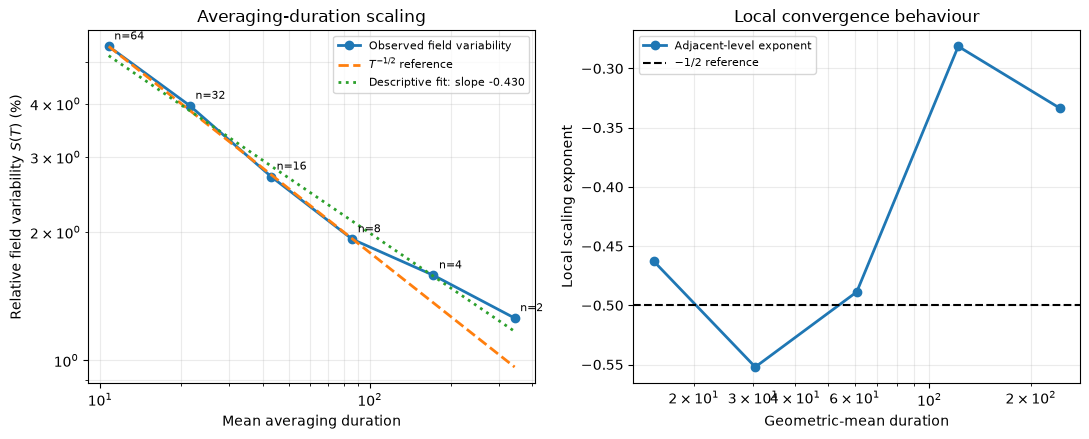

Saved Stage 3 tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/variable_duration_partition_summary.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/variable_duration_scaling_summary.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/variable_duration_scaling_fits.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/variable_duration_local_exponents.csv

Saved Stage 3 figures:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/statistical_uncertainty_accuracy_floor/variable_duration_scaling.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/statistical_uncertainty_accuracy_floor/variable_duration_scaling.png

Stage 3 artifacts saved successfully: True


In [10]:
import matplotlib.pyplot as plt


PARTITION_TABLE_PATH = (
    TABLE_DIRECTORY
    / "variable_duration_partition_summary.csv"
)

SCALING_TABLE_PATH = (
    TABLE_DIRECTORY
    / "variable_duration_scaling_summary.csv"
)

FIT_TABLE_PATH = (
    TABLE_DIRECTORY
    / "variable_duration_scaling_fits.csv"
)

LOCAL_SCALING_TABLE_PATH = (
    TABLE_DIRECTORY
    / "variable_duration_local_exponents.csv"
)

SCALING_FIGURE_PDF = (
    FIGURE_DIRECTORY
    / "variable_duration_scaling.pdf"
)

SCALING_FIGURE_PNG = (
    FIGURE_DIRECTORY
    / "variable_duration_scaling.png"
)


variable_duration_partition_summary.to_csv(
    PARTITION_TABLE_PATH,
    index=False,
)

variable_duration_scaling_summary.to_csv(
    SCALING_TABLE_PATH,
    index=False,
)

scaling_fit_summary.to_csv(
    FIT_TABLE_PATH,
    index=False,
)

local_scaling_summary.to_csv(
    LOCAL_SCALING_TABLE_PATH,
    index=False,
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        11,
        4.5,
    ),
)


axes[
    0
].loglog(
    duration_values,
    variability_values,
    marker="o",
    linewidth=2,
    label="Observed field variability",
)

axes[
    0
].loglog(
    duration_values,
    inverse_square_root_reference,
    linestyle="--",
    linewidth=2,
    label=r"$T^{-1/2}$ reference",
)

all_level_fitted_values = np.exp(
    all_level_fit[
        "intercept"
    ]
) * (
    duration_values
    ** all_level_fit[
        "slope"
    ]
)

axes[
    0
].loglog(
    duration_values,
    all_level_fitted_values,
    linestyle=":",
    linewidth=2,
    label=(
        "Descriptive fit: "
        f"slope "
        f"{all_level_fit['slope']:.3f}"
    ),
)


for _, row in (
    variable_duration_scaling_summary.iterrows()
):
    axes[
        0
    ].annotate(
        f"n={int(row['field_count'])}",
        (
            row[
                "mean_duration"
            ],
            row[
                "field_variability_percent"
            ],
        ),
        xytext=(
            4,
            5,
        ),
        textcoords="offset points",
        fontsize=8,
    )


axes[
    0
].set_xlabel(
    "Mean averaging duration"
)

axes[
    0
].set_ylabel(
    r"Relative field variability $S(T)$ (%)"
)

axes[
    0
].set_title(
    "Averaging-duration scaling"
)

axes[
    0
].legend(
    fontsize=8,
)


axes[
    1
].semilogx(
    local_scaling_summary[
        "geometric_mean_duration"
    ],
    local_scaling_summary[
        "local_scaling_exponent"
    ],
    marker="o",
    linewidth=2,
    label="Adjacent-level exponent",
)

axes[
    1
].axhline(
    -0.5,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=r"$-1/2$ reference",
)

axes[
    1
].set_xlabel(
    "Geometric-mean duration"
)

axes[
    1
].set_ylabel(
    "Local scaling exponent"
)

axes[
    1
].set_title(
    "Local convergence behaviour"
)

axes[
    1
].legend(
    fontsize=8,
)


for axis in axes:
    axis.grid(
        True,
        alpha=0.25,
        which="both",
    )


figure.tight_layout()

figure.savefig(
    SCALING_FIGURE_PDF,
    bbox_inches="tight",
)

figure.savefig(
    SCALING_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved Stage 3 tables:"
)

for path in [
    PARTITION_TABLE_PATH,
    SCALING_TABLE_PATH,
    FIT_TABLE_PATH,
    LOCAL_SCALING_TABLE_PATH,
]:
    print(path)


print(
    "\nSaved Stage 3 figures:"
)

for path in [
    SCALING_FIGURE_PDF,
    SCALING_FIGURE_PNG,
]:
    print(path)


assert all(
    path.is_file()
    for path in [
        PARTITION_TABLE_PATH,
        SCALING_TABLE_PATH,
        FIT_TABLE_PATH,
        LOCAL_SCALING_TABLE_PATH,
        SCALING_FIGURE_PDF,
        SCALING_FIGURE_PNG,
    ]
)

print(
    "\nStage 3 artifacts saved successfully:",
    True,
)

In [11]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import display


# Locate the repository without scanning unrelated directories.
CURRENT_DIRECTORY = Path.cwd().resolve()

REPOSITORY_CANDIDATES = [
    CURRENT_DIRECTORY,
    CURRENT_DIRECTORY.parent,
]

REPOSITORY_ROOT = next(
    (
        candidate
        for candidate in REPOSITORY_CANDIDATES
        if (
            candidate
            / "results"
            / "tables"
            / "cg_phi_quality_summary.csv"
        ).is_file()
    ),
    None,
)

assert REPOSITORY_ROOT is not None, (
    "Could not locate the repository root from the current "
    "notebook directory."
)


QUALITY_SUMMARY_PATH = (
    REPOSITORY_ROOT
    / "results"
    / "tables"
    / "cg_phi_quality_summary.csv"
)

EXTERNAL_FIELD_DIRECTORY = (
    REPOSITORY_ROOT
    / "data"
    / "raw"
    / "CG_field_phi_small_test_set"
)


quality_summary = pd.read_csv(
    QUALITY_SUMMARY_PATH
)

required_columns = {
    "split",
    "size_ratio",
    "simulation_number",
    "time",
    "filename",
}

assert required_columns.issubset(
    quality_summary.columns
), (
    "The quality-summary schema is missing required columns: "
    f"{sorted(required_columns - set(quality_summary.columns))}"
)


external_quality_summary = (
    quality_summary.loc[
        quality_summary[
            "split"
        ].astype(str).str.strip().str.lower().eq(
            "testing"
        )
    ]
    .copy()
    .sort_values(
        [
            "size_ratio",
            "simulation_number",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert len(
    external_quality_summary
) == 10, (
    "Expected exactly ten external/test records, found "
    f"{len(external_quality_summary)}."
)

assert external_quality_summary[
    "filename"
].nunique() == 10, (
    "The external/test records do not contain exactly ten "
    "unique filenames."
)


def extract_scalar(
    header_text,
    key,
):
    pattern = (
        rf"(?i)\b{re.escape(key)}\b"
        rf"\s*(?:=|:)?\s*"
        rf"([-+]?(?:\d+(?:\.\d*)?|\.\d+)"
        rf"(?:[eE][-+]?\d+)?)"
    )

    match = re.search(
        pattern,
        header_text,
    )

    if match is None:
        return np.nan

    return float(
        match.group(1)
    )


def extract_grid_dimensions(
    header_text,
):
    match = re.search(
        (
            r"(?i)\bn\b"
            r"\s*(?:=|:)?\s*"
            r"(\d+)"
            r"[\s,]+"
            r"(\d+)"
            r"[\s,]+"
            r"(\d+)"
        ),
        header_text,
    )

    if match is None:
        return None

    return tuple(
        int(value)
        for value in match.groups()
    )


duration_audit_records = []


for _, record in (
    external_quality_summary.iterrows()
):
    recorded_filename = Path(
        str(
            record[
                "filename"
            ]
        )
    )

    if recorded_filename.is_absolute():
        field_path = recorded_filename
    else:
        field_path = (
            REPOSITORY_ROOT
            / recorded_filename
        )

    # Use the exact authorised external directory if the table
    # stores only a basename or an outdated relative prefix.
    if not field_path.is_file():
        field_path = (
            EXTERNAL_FIELD_DIRECTORY
            / recorded_filename.name
        )

    assert field_path.is_file(), (
        f"Missing external field: {field_path}"
    )

    assert (
        field_path.resolve().parent
        == EXTERNAL_FIELD_DIRECTORY.resolve()
    ), (
        "Refusing to read a file outside the authorised external "
        f"field directory: {field_path}"
    )

    # Read exactly two text lines; do not load numerical field rows.
    with field_path.open(
        "r",
        encoding="utf-8",
        errors="replace",
    ) as field_handle:
        first_header_line = field_handle.readline().rstrip(
            "\n"
        )
        second_header_line = field_handle.readline().rstrip(
            "\n"
        )

    combined_header = (
        first_header_line
        + "\n"
        + second_header_line
    )

    time_min = extract_scalar(
        combined_header,
        "timeMin",
    )

    time_max = extract_scalar(
        combined_header,
        "timeMax",
    )

    width = extract_scalar(
        combined_header,
        "width",
    )

    cutoff = extract_scalar(
        combined_header,
        "cutoff",
    )

    grid_dimensions = extract_grid_dimensions(
        combined_header
    )

    saved_output_time = float(
        record[
            "time"
        ]
    )

    if np.isfinite(
        time_max
    ):
        duration_end_time = time_max
    else:
        duration_end_time = saved_output_time

    inferred_duration = (
        duration_end_time
        - time_min
        if np.isfinite(
            time_min
        )
        else np.nan
    )

    kernel = (
        "Lucy"
        if re.search(
            r"(?i)\blucy\b",
            combined_header,
        )
        else "not identified"
    )

    time_min_pass = (
        np.isfinite(
            time_min
        )
        and np.isclose(
            time_min,
            1377.0,
            rtol=0.0,
            atol=1.0e-8,
        )
    )

    saved_time_pass = np.isclose(
        saved_output_time,
        1720.72,
        rtol=0.0,
        atol=1.0e-8,
    )

    time_max_pass = (
        not np.isfinite(
            time_max
        )
        or np.isclose(
            time_max,
            1720.72,
            rtol=0.0,
            atol=1.0e-8,
        )
    )

    duration_pass = (
        np.isfinite(
            inferred_duration
        )
        and np.isclose(
            inferred_duration,
            343.72,
            rtol=0.0,
            atol=1.0e-8,
        )
    )

    grid_pass = (
        grid_dimensions
        == (
            100,
            1,
            100,
        )
    )

    width_pass = (
        np.isfinite(
            width
        )
        and np.isclose(
            width,
            3.0,
            rtol=0.0,
            atol=1.0e-12,
        )
    )

    kernel_pass = (
        kernel
        == "Lucy"
    )

    cutoff_pass = (
        np.isfinite(
            cutoff
        )
        and np.isclose(
            cutoff,
            3.0,
            rtol=0.0,
            atol=1.0e-12,
        )
    )

    duration_audit_records.append(
        {
            "filename": field_path.name,
            "size_ratio": float(
                record[
                    "size_ratio"
                ]
            ),
            "simulation_number": int(
                record[
                    "simulation_number"
                ]
            ),
            "time_min": time_min,
            "time_max": time_max,
            "saved_output_time": saved_output_time,
            "inferred_duration": inferred_duration,
            "grid_dimensions": grid_dimensions,
            "width": width,
            "kernel": kernel,
            "cutoff": cutoff,
            "time_min_pass": time_min_pass,
            "saved_time_pass": saved_time_pass,
            "time_max_pass": time_max_pass,
            "duration_pass": duration_pass,
            "grid_pass": grid_pass,
            "width_pass": width_pass,
            "kernel_pass": kernel_pass,
            "cutoff_pass": cutoff_pass,
        }
    )


external_duration_audit = pd.DataFrame(
    duration_audit_records
)


audit_pass_columns = [
    "time_min_pass",
    "saved_time_pass",
    "time_max_pass",
    "duration_pass",
    "grid_pass",
    "width_pass",
    "kernel_pass",
    "cutoff_pass",
]


display(
    external_duration_audit
)


print(
    "External files checked:",
    len(
        external_duration_audit
    ),
)

print(
    "Unique averaging durations:",
    sorted(
        external_duration_audit[
            "inferred_duration"
        ].unique()
    ),
)

print(
    "All external-duration and CG checks passed:",
    bool(
        external_duration_audit[
            audit_pass_columns
        ].to_numpy().all()
    ),
)


assert len(
    external_duration_audit
) == 10

assert external_duration_audit[
    audit_pass_columns
].to_numpy().all(), (
    "At least one external field failed the duration or "
    "coarse-graining provenance gate."
)

print(
    "\nExternal target-duration gate passed successfully:",
    True,
)


,filename,size_ratio,simulation_number,time_min,time_max,saved_output_time,inferred_duration,grid_dimensions,width,kernel,cutoff,time_min_pass,saved_time_pass,time_max_pass,duration_pass,grid_pass,width_pass,kernel_pass,cutoff_pass
0,rotating_drum_bidisperse_size_ratio_1_062500_n...,1.0625,8,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
1,rotating_drum_bidisperse_size_ratio_1_125000_n...,1.1250,4,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
2,rotating_drum_bidisperse_size_ratio_1_250000_n...,1.2500,2,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
3,rotating_drum_bidisperse_size_ratio_1_312500_n...,1.3125,10,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
4,rotating_drum_bidisperse_size_ratio_1_375000_n...,1.3750,6,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
5,rotating_drum_bidisperse_size_ratio_1_500000_n...,1.5000,1,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
6,rotating_drum_bidisperse_size_ratio_1_562500_n...,1.5625,9,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
7,rotating_drum_bidisperse_size_ratio_1_625000_n...,1.6250,5,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
8,rotating_drum_bidisperse_size_ratio_1_750000_n...,1.7500,3,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True
9,rotating_drum_bidisperse_size_ratio_1_875000_n...,1.8750,7,1377.0,NaN,1720.72,343.72,"(100, 1, 100)",3.0,Lucy,3.0,True,True,True,True,True,True,True,True


External files checked: 10
Unique averaging durations: [343.72]
All external-duration and CG checks passed: True

External target-duration gate passed successfully: True


In [12]:
split_label_summary = (
    quality_summary[
        "split"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "stored_split_label"
    )
    .reset_index(
        name="row_count"
    )
)

display(
    split_label_summary
)

display(
    quality_summary[
        [
            "split",
            "size_ratio",
            "simulation_number",
            "time",
            "filename",
        ]
    ].tail(
        15
    )
)

,stored_split_label,row_count
0,training,100
1,testing,10


,split,size_ratio,simulation_number,time,filename
95,training,1.959596,96,1720.72,rotating_drum_bidisperse_size_ratio_1_959596_n...
96,training,1.969697,97,1720.72,rotating_drum_bidisperse_size_ratio_1_969697_n...
97,training,1.979798,98,1720.72,rotating_drum_bidisperse_size_ratio_1_979798_n...
98,training,1.989899,99,1720.72,rotating_drum_bidisperse_size_ratio_1_989899_n...
99,training,2.000000,100,1720.72,rotating_drum_bidisperse_size_ratio_2_000000_n...
100,testing,1.062500,8,1720.72,rotating_drum_bidisperse_size_ratio_1_062500_n...
101,testing,1.125000,4,1720.72,rotating_drum_bidisperse_size_ratio_1_125000_n...
102,testing,1.250000,2,1720.72,rotating_drum_bidisperse_size_ratio_1_250000_n...
103,testing,1.312500,10,1720.72,rotating_drum_bidisperse_size_ratio_1_312500_n...
104,testing,1.375000,6,1720.72,rotating_drum_bidisperse_size_ratio_1_375000_n...


In [13]:
import hashlib
import json

import numpy as np
import pandas as pd
import torch


RANK_6_PACKAGE_PATH = (
    REPOSITORY_ROOT
    / "data"
    / "processed"
    / "cg_phi_validation_selected_rank_uncentred_raw.pt"
)

RANK_15_PACKAGE_PATH = (
    REPOSITORY_ROOT
    / "data"
    / "processed"
    / "cg_phi_paper_rank15_uncentred_raw.pt"
)

COMPACT_DATASET_PATH = (
    REPOSITORY_ROOT
    / "data"
    / "processed"
    / "cg_phi_small_dataset.npz"
)


def calculate_sha256(
    path,
):
    digest = hashlib.sha256()

    with path.open(
        "rb"
    ) as file_handle:
        for block in iter(
            lambda: file_handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(
                block
            )

    return digest.hexdigest()


def load_torch_package(
    path,
):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu",
        )


def describe_value(
    value,
):
    if isinstance(
        value,
        torch.Tensor,
    ):
        return (
            f"torch.Tensor shape={tuple(value.shape)}, "
            f"dtype={value.dtype}"
        )

    if isinstance(
        value,
        np.ndarray,
    ):
        return (
            f"numpy.ndarray shape={value.shape}, "
            f"dtype={value.dtype}"
        )

    if isinstance(
        value,
        pd.DataFrame,
    ):
        return (
            f"DataFrame shape={value.shape}, "
            f"columns={list(value.columns)}"
        )

    if isinstance(
        value,
        pd.Series,
    ):
        return (
            f"Series shape={value.shape}, "
            f"dtype={value.dtype}"
        )

    if isinstance(
        value,
        dict,
    ):
        return (
            f"{type(value).__name__} "
            f"with keys={list(value.keys())}"
        )

    if isinstance(
        value,
        (
            list,
            tuple,
        ),
    ):
        if len(
            value
        ) <= 12:
            return (
                f"{type(value).__name__} "
                f"length={len(value)}, "
                f"value={value}"
            )

        return (
            f"{type(value).__name__} "
            f"length={len(value)}"
        )

    representation = repr(
        value
    )

    if len(
        representation
    ) > 200:
        representation = (
            representation[
                :197
            ]
            + "..."
        )

    return (
        f"{type(value).__name__}: "
        f"{representation}"
    )


def print_package_schema(
    package_name,
    package_path,
    package,
):
    print(
        "\n"
        + "=" * 80
    )

    print(
        package_name
    )

    print(
        "Path:",
        package_path,
    )

    print(
        "SHA-256:",
        calculate_sha256(
            package_path
        ),
    )

    print(
        "Package type:",
        type(
            package
        ).__name__,
    )

    if not isinstance(
        package,
        dict,
    ):
        print(
            "Package value:",
            describe_value(
                package
            ),
        )
        return

    print(
        "Top-level keys:",
        list(
            package.keys()
        ),
    )

    for key, value in package.items():
        print(
            f"\n[{key}]"
        )

        print(
            describe_value(
                value
            )
        )

        if isinstance(
            value,
            dict,
        ):
            for nested_key, nested_value in value.items():
                print(
                    f"  {nested_key}: "
                    f"{describe_value(nested_value)}"
                )


for required_path in [
    RANK_6_PACKAGE_PATH,
    RANK_15_PACKAGE_PATH,
    COMPACT_DATASET_PATH,
]:
    assert required_path.is_file(), (
        f"Required saved artifact is missing: {required_path}"
    )


rank_6_package = load_torch_package(
    RANK_6_PACKAGE_PATH
)

rank_15_package = load_torch_package(
    RANK_15_PACKAGE_PATH
)


print_package_schema(
    "RANK 6 PACKAGE",
    RANK_6_PACKAGE_PATH,
    rank_6_package,
)

print_package_schema(
    "RANK 15 PACKAGE",
    RANK_15_PACKAGE_PATH,
    rank_15_package,
)


print(
    "\n"
    + "=" * 80
)

print(
    "COMPACT DATASET SCHEMA"
)

with np.load(
    COMPACT_DATASET_PATH,
    allow_pickle=False,
) as compact_dataset:
    print(
        "Dataset keys:",
        list(
            compact_dataset.files
        ),
    )

    for key in compact_dataset.files:
        value = compact_dataset[
            key
        ]

        print(
            f"{key}: "
            f"shape={value.shape}, "
            f"dtype={value.dtype}"
        )


print(
    "\n"
    + "=" * 80
)

print(
    "NOTEBOOK 15 STAGE VARIABLES"
)

stage_variable_names = [
    "x_grid",
    "z_grid",
    "train_parameters",
    "train_simulation_numbers",
    "train_snapshot_matrix",
    "test_parameters",
    "test_simulation_numbers",
    "test_snapshot_matrix",
    "numbered_field_tensor",
    "numbered_parameter_plan",
    "numbered_metadata",
    "variable_duration_field_matrix",
    "variable_duration_metadata",
    "variable_duration_partition_summary",
    "variable_duration_scaling_summary",
    "scaling_fit_summary",
    "local_scaling_summary",
]

for variable_name in stage_variable_names:
    if variable_name in globals():
        print(
            f"{variable_name}: "
            f"{describe_value(globals()[variable_name])}"
        )
    else:
        print(
            f"{variable_name}: NOT DEFINED"
        )


print(
    "\n"
    + "=" * 80
)

print(
    "METADATA PREVIEWS"
)

for metadata_name in [
    "numbered_parameter_plan",
    "numbered_metadata",
    "variable_duration_metadata",
]:
    if metadata_name not in globals():
        continue

    metadata_value = globals()[
        metadata_name
    ]

    print(
        f"\n{metadata_name}:"
    )

    if isinstance(
        metadata_value,
        pd.DataFrame,
    ):
        display(
            metadata_value.head(
                12
            )
        )
    else:
        print(
            describe_value(
                metadata_value
            )
        )


print(
    "\n"
    + "=" * 80
)

print(
    "NOTEBOOK 14 MANIFEST CANDIDATES"
)

package_basenames = {
    RANK_6_PACKAGE_PATH.name,
    RANK_15_PACKAGE_PATH.name,
}

manifest_candidates = []

RESULTS_TABLE_ROOT = (
    REPOSITORY_ROOT
    / "results"
    / "tables"
)

for json_path in sorted(
    RESULTS_TABLE_ROOT.rglob(
        "*.json"
    )
):
    try:
        json_text = json_path.read_text(
            encoding="utf-8"
        )
    except UnicodeDecodeError:
        continue

    if all(
        package_basename in json_text
        for package_basename in package_basenames
    ):
        manifest_candidates.append(
            json_path
        )


print(
    "Matching manifest count:",
    len(
        manifest_candidates
    ),
)

for manifest_path in manifest_candidates:
    print(
        manifest_path
    )


assert len(
    manifest_candidates
) >= 1, (
    "No results-table JSON manifest references both trusted "
    "Notebook 14 packages."
)

print(
    "\nFrozen-package schema inspection completed successfully:",
    True,
)


RANK 6 PACKAGE
Path: /Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_validation_selected_rank_uncentred_raw.pt
SHA-256: df716ccd732b88e67a73eec7873d33ba5efb9c9b5bc7ca30aec2fe99f1edacf7
Package type: dict
Top-level keys: ['state_dict', 'rank', 'hidden_width', 'input_dimension', 'parameter_minimum', 'parameter_maximum', 'training_indices', 'validation_indices', 'random_seed', 'coefficient_scaling', 'pod_formulation', 'pod_basis', 'x_grid', 'z_grid']

[state_dict]
OrderedDict with keys=['network.0.weight', 'network.0.bias', 'network.2.weight', 'network.2.bias', 'network.4.weight', 'network.4.bias']
  network.0.weight: torch.Tensor shape=(21, 1), dtype=torch.float64
  network.0.bias: torch.Tensor shape=(21,), dtype=torch.float64
  network.2.weight: torch.Tensor shape=(21, 21), dtype=torch.float64
  network.2.bias: torch.Tensor shape=(21,), dtype=torch.float64
  network.4.weight: torch.Tensor shape=(6, 21), dtype=torch.float64
  network.4.bias: torch.Tensor shape=(6,

,size_ratio,source_simulation
0,1.000000,1
1,1.101010,11
2,1.202020,21
3,1.303030,31
4,1.404040,41
5,1.505051,51
6,1.606061,61
7,1.707071,71
8,1.808081,81
9,1.909091,91



numbered_metadata:


,matrix_column,filename,relative_path,size_ratio,source_simulation,window_number,inventory_duration,time_min,time_max,metadata_duration,saved_time,saved_time_minus_time_max,width,kernel,cutoff,column_header,field_minimum,field_maximum,field_mean
0,0,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,1,NaN,1377.00,1411.37,34.37,1412.54,1.17,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.310866,0.064922
1,1,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,2,NaN,1411.37,1445.74,34.37,1446.95,1.21,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.300786,0.064922
2,2,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,3,NaN,1445.74,1480.12,34.38,1481.36,1.24,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.315670,0.064922
3,3,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,4,NaN,1480.12,1514.49,34.37,1515.77,1.28,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.300604,0.064922
4,4,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,5,NaN,1514.49,1548.86,34.37,1550.18,1.32,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.303351,0.064922
5,5,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,6,NaN,1548.86,1583.23,34.37,1584.60,1.37,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.308480,0.064922
6,6,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,7,NaN,1583.23,1617.60,34.37,1619.01,1.41,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.306244,0.064922
7,7,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,8,NaN,1617.60,1651.98,34.38,1653.42,1.44,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.304295,0.064922
8,8,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,9,NaN,1651.98,1686.35,34.37,1687.83,1.48,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.306714,0.064922
9,9,rotating_drum_bidisperse_size_ratio_1_000000.1...,bidisperse_mixtures/CG_windows/rotating_drum_b...,1.00000,1,10,NaN,1686.35,1720.72,34.37,1720.72,0.00,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.304623,0.064922



variable_duration_metadata:


,matrix_column,filename,relative_path,size_ratio,source_simulation,window_number,inventory_duration,time_min,time_max,metadata_duration,...,saved_time_minus_time_max,width,kernel,cutoff,column_header,field_minimum,field_maximum,field_mean,rounded_duration,duration_level
0,0,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1043.19,1053.94,10.75,...,0.86,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.496865,0.06491,10.75,0
1,1,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1064.70,1075.45,10.75,...,1.71,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.509704,0.06491,10.75,0
2,2,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1086.21,1096.96,10.75,...,0.85,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.505370,0.06491,10.75,0
3,3,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1096.96,1107.71,10.75,...,0.43,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.509423,0.06491,10.75,0
4,4,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1118.47,1129.22,10.75,...,1.29,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.503497,0.06491,10.75,0
5,5,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1139.98,1150.73,10.75,...,0.43,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.520566,0.06491,10.75,0
6,6,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1161.49,1172.24,10.75,...,1.28,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.508082,0.06491,10.75,0
7,7,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1183.00,1193.75,10.75,...,0.42,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.510025,0.06491,10.75,0
8,8,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1193.75,1204.50,10.75,...,1.72,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.504236,0.06491,10.75,0
9,9,rotating_drum_bidisperse_size_ratio_1_303030.3...,bidisperse_mixtures/CG_windows_sigma/rotating_...,1.30303,31,<NA>,10.75,1215.26,1226.01,10.75,...,0.86,3.0,Lucy,3.0,time x z 4:VolumeFraction 5:Density 6-8:Moment...,0.0,0.507075,0.06491,10.75,0



NOTEBOOK 14 MANIFEST CANDIDATES
Matching manifest count: 1
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/exact_paper_method_reproduction_manifest.json

Frozen-package schema inspection completed successfully: True


In [14]:
import json

import nbformat


NOTEBOOK_14_CANDIDATES = sorted(
    (
        REPOSITORY_ROOT
        / "notebooks"
    ).glob(
        "14_*.ipynb"
    )
)

assert len(
    NOTEBOOK_14_CANDIDATES
) == 1, (
    "Expected exactly one Notebook 14 file, found: "
    f"{NOTEBOOK_14_CANDIDATES}"
)

NOTEBOOK_14_PATH = (
    NOTEBOOK_14_CANDIDATES[
        0
    ]
)

NOTEBOOK_14_MANIFEST_PATH = (
    manifest_candidates[
        0
    ]
)


print(
    "Notebook 14:",
    NOTEBOOK_14_PATH,
)

print(
    "Notebook 14 manifest:",
    NOTEBOOK_14_MANIFEST_PATH,
)


with NOTEBOOK_14_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as manifest_handle:
    notebook_14_manifest = json.load(
        manifest_handle
    )


def find_matching_manifest_records(
    value,
    target_basenames,
    path="root",
):
    matches = []

    if isinstance(
        value,
        dict,
    ):
        serialized_value = json.dumps(
            value,
            sort_keys=True,
            default=str,
        )

        if any(
            target_basename
            in serialized_value
            for target_basename in target_basenames
        ):
            direct_scalar_text = " ".join(
                str(item)
                for item in value.values()
                if not isinstance(
                    item,
                    (
                        dict,
                        list,
                        tuple,
                    ),
                )
            )

            if any(
                target_basename
                in direct_scalar_text
                for target_basename in target_basenames
            ):
                matches.append(
                    (
                        path,
                        value,
                    )
                )

        for key, nested_value in value.items():
            matches.extend(
                find_matching_manifest_records(
                    nested_value,
                    target_basenames,
                    path=(
                        f"{path}.{key}"
                    ),
                )
            )

    elif isinstance(
        value,
        list,
    ):
        for index, nested_value in enumerate(
            value
        ):
            matches.extend(
                find_matching_manifest_records(
                    nested_value,
                    target_basenames,
                    path=(
                        f"{path}[{index}]"
                    ),
                )
            )

    return matches


matching_manifest_records = (
    find_matching_manifest_records(
        notebook_14_manifest,
        package_basenames,
    )
)


print(
    "\nManifest top-level keys:",
    list(
        notebook_14_manifest.keys()
    ),
)

print(
    "\nMatching package records:"
)

for record_path, record in matching_manifest_records:
    print(
        "\nRecord path:",
        record_path,
    )

    print(
        json.dumps(
            record,
            indent=2,
            sort_keys=True,
            default=str,
        )
    )


with NOTEBOOK_14_PATH.open(
    "r",
    encoding="utf-8",
) as notebook_handle:
    notebook_14 = nbformat.read(
        notebook_handle,
        as_version=4,
    )


model_search_terms = [
    "class ",
    "nn.Sequential",
    "torch.nn.Sequential",
    "nn.Tanh",
    "nn.ReLU",
    "nn.Sigmoid",
    "nn.GELU",
    "nn.ELU",
    "nn.LeakyReLU",
    "load_state_dict",
    "parameter_minimum",
    "parameter_maximum",
]


matching_code_cells = []

for cell_index, cell in enumerate(
    notebook_14.cells
):
    if cell.cell_type != "code":
        continue

    source = cell.source

    if (
        "state_dict"
        in source
        and any(
            term in source
            for term in model_search_terms
        )
    ) or (
        "nn.Sequential"
        in source
    ) or (
        "torch.nn.Sequential"
        in source
    ):
        matching_code_cells.append(
            (
                cell_index,
                source,
            )
        )


print(
    "\nRelevant Notebook 14 code-cell count:",
    len(
        matching_code_cells
    ),
)


for cell_index, source in matching_code_cells:
    print(
        "\n"
        + "=" * 80
    )

    print(
        f"NOTEBOOK 14 CODE CELL {cell_index}"
    )

    print(
        source
    )


assert len(
    matching_manifest_records
) >= 2, (
    "The manifest did not expose records for both packages."
)

assert len(
    matching_code_cells
) >= 1, (
    "No relevant frozen-model definition was found in "
    "Notebook 14."
)

print(
    "\nNotebook 14 architecture provenance recovered:",
    True,
)

Notebook 14: /Users/rallen/Documents/msc-rom-particle-systems/notebooks/14_exact_paper_method_reproduction.ipynb
Notebook 14 manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/exact_paper_method_reproduction_manifest.json

Manifest top-level keys: ['schema_version', 'notebook', 'python_version', 'numpy_version', 'pandas_version', 'scikit_learn_version', 'pytorch_version', 'dataset', 'paper_interpretation', 'training_design', 'final_results', 'artifacts']

Matching package records:

Record path: root.artifacts[0]
{
  "relative_path": "data/processed/cg_phi_paper_rank15_uncentred_raw.pt",
  "sha256": "571c12493edd5782859f617316badd4b58402b2b06a90e6d03fddccf6baea516",
  "size_bytes": 1554700
}

Record path: root.artifacts[1]
{
  "relative_path": "data/processed/cg_phi_validation_selected_rank_uncentred_raw.pt",
  "sha256": "df716ccd732b88e67a73eec7873d33ba5efb9c9b5bc7ca30aec2fe99f1edacf7",
  "size_bytes": 623748
}

Relevant Notebook 1

## Stage 4: duration-matched modewise uncertainty and frozen-ROM error decomposition

This stage compares temporal coarse-graining variability with the errors of the frozen rank-6 and rank-15 continuum ROMs from Notebook 14. Neither model is retrained or reselected.

The ten numbered fields at each parameter have mean averaging duration

$$
T_{\mathrm{short}}=34.372,
$$

whereas their ten-window means and the independent external continuum fields represent

$$
T_{\mathrm{target}}=343.72.
$$

The duration ratio is therefore

$$
\frac{T_{\mathrm{target}}}{T_{\mathrm{short}}}=10.
$$

For numbered parameter case $p$, window $j=1,\ldots,10$, and POD mode $k$, let

$$
a_{p,j,k}=\Phi_r^{\mathsf T}q_{p,j}.
$$

The modal sample standard deviation is

$$
s^{\mathrm{short}}_{p,k}
=
\sqrt{
\frac{1}{9}
\sum_{j=1}^{10}
\left(
a_{p,j,k}-\bar a_{p,k}
\right)^2
},
\qquad
\bar a_{p,k}
=
\frac{1}{10}
\sum_{j=1}^{10}a_{p,j,k}.
$$

If $\sigma_p(x,z)$ is the pointwise sample standard deviation of the ten fields, the absolute field-variability norm is

$$
u^{\mathrm{short}}_p
=
\left\lVert \sigma_p \right\rVert_2.
$$

The predeclared primary duration correction uses the Stage 3 exponent

$$
\alpha_{\mathrm{primary}}=-0.461059,
$$

obtained after excluding the longest-duration two-field endpoint. The target-duration estimates are

$$
s^{\mathrm{target}}_{p,k}
=
s^{\mathrm{short}}_{p,k}
\left(
\frac{T_{\mathrm{target}}}{T_{\mathrm{short}}}
\right)^{\alpha_{\mathrm{primary}}},
$$

and

$$
u^{\mathrm{target}}_p
=
u^{\mathrm{short}}_p
\left(
\frac{T_{\mathrm{target}}}{T_{\mathrm{short}}}
\right)^{\alpha_{\mathrm{primary}}}.
$$

Applying one field-level exponent to every POD mode is an explicit approximation. Ideal inverse-square-root scaling with $\alpha=-1/2$ is retained only as a sensitivity analysis. The direct longest-duration result for simulation 31 is also retained separately as unstable two-field, one-degree-of-freedom evidence.

For the external cases, piecewise-linear interpolation in size ratio is applied to the duration-adjusted absolute modal standard deviations and absolute field-variability norms. Normalisation by the external truth-field norm occurs only after interpolation. The interpolation rule is assessed first using leave-one-parameter-out validation on the eight interior numbered parameters. The two endpoints are not extrapolated.

For truth field $q$, exact frozen uncentred basis $\Phi_r$, projected coefficients $a^\star=\Phi_r^{\mathsf T}q$, and frozen-network prediction $\widehat a$, define

$$
e_{\mathrm{POD}}
=
\frac{
\left\lVert q-\Phi_r a^\star \right\rVert_2
}{
\left\lVert q \right\rVert_2
},
$$

$$
e_{\mathrm{coef}}
=
\frac{
\left\lVert a^\star-\widehat a \right\rVert_2
}{
\left\lVert q \right\rVert_2
},
$$

and

$$
e_{\mathrm{ROM}}
=
\frac{
\left\lVert q-\Phi_r\widehat a \right\rVert_2
}{
\left\lVert q \right\rVert_2
}.
$$

Orthonormality requires the exact decomposition

$$
e_{\mathrm{ROM}}^2
=
e_{\mathrm{POD}}^2
+
e_{\mathrm{coef}}^2
$$

up to numerical round-off.

Simulation 41 is the sole directly matched internal-validation diagnostic. The other nine numbered cases are fitting diagnostics. The ten independent external cases are used only after the duration-scaling and interpolation rules are fixed.

Contiguous and nested windows are not treated as independent replicates. External uncertainty values are interpolated estimates, not directly observed error floors. Comparisons may establish whether ROM errors are smaller than, comparable to, or larger than this predeclared empirical variability scale, but cannot establish that finite-time averaging caused a particular ROM error.

In [15]:
import hashlib

import numpy as np
import pandas as pd
import torch
from IPython.display import display


T_SHORT = 34.372
T_TARGET = 343.72

ALPHA_PRIMARY = -0.461059
ALPHA_INVERSE_SQRT = -0.5

DURATION_RATIO = (
    T_TARGET
    / T_SHORT
)

PRIMARY_DURATION_FACTOR = (
    DURATION_RATIO
    ** ALPHA_PRIMARY
)

INVERSE_SQRT_DURATION_FACTOR = (
    DURATION_RATIO
    ** ALPHA_INVERSE_SQRT
)


assert np.isclose(
    DURATION_RATIO,
    10.0,
    rtol=0.0,
    atol=1.0e-12,
)

assert np.isclose(
    numbered_metadata[
        "metadata_duration"
    ].mean(),
    T_SHORT,
    rtol=0.0,
    atol=1.0e-10,
)

assert np.allclose(
    external_duration_audit[
        "inferred_duration"
    ],
    T_TARGET,
    rtol=0.0,
    atol=1.0e-10,
)


with np.load(
    COMPACT_DATASET_PATH,
    allow_pickle=False,
) as compact_dataset:
    compact_x_grid = np.asarray(
        compact_dataset[
            "x"
        ],
        dtype=float,
    )

    compact_z_grid = np.asarray(
        compact_dataset[
            "z"
        ],
        dtype=float,
    )

    compact_train_parameters = np.asarray(
        compact_dataset[
            "train_parameters"
        ],
        dtype=float,
    )

    compact_train_simulation_numbers = np.asarray(
        compact_dataset[
            "train_simulation_numbers"
        ],
        dtype=int,
    )

    compact_train_snapshot_matrix = np.asarray(
        compact_dataset[
            "train_snapshots"
        ],
        dtype=float,
    )

    test_parameters = np.asarray(
        compact_dataset[
            "test_parameters"
        ],
        dtype=float,
    )

    test_simulation_numbers = np.asarray(
        compact_dataset[
            "test_simulation_numbers"
        ],
        dtype=int,
    )

    test_snapshot_matrix = np.asarray(
        compact_dataset[
            "test_snapshots"
        ],
        dtype=float,
    )

    test_filenames = np.asarray(
        compact_dataset[
            "test_filenames"
        ]
    )


assert np.array_equal(
    compact_x_grid,
    x_grid,
)

assert np.array_equal(
    compact_z_grid,
    z_grid,
)

assert np.array_equal(
    compact_train_parameters,
    train_parameters,
)

assert np.array_equal(
    compact_train_simulation_numbers,
    train_simulation_numbers,
)

assert np.array_equal(
    compact_train_snapshot_matrix,
    train_snapshot_matrix,
)

assert test_snapshot_matrix.shape == (
    10000,
    10,
)

assert np.isfinite(
    test_snapshot_matrix
).all()

assert np.all(
    np.linalg.norm(
        test_snapshot_matrix,
        axis=0,
    ) > 0.0
)


class FrozenPaperStyleNetwork(
    torch.nn.Module
):
    def __init__(
        self,
        input_dimension,
        output_dimension,
        hidden_width,
    ):
        super().__init__()

        self.network = torch.nn.Sequential(
            torch.nn.Linear(
                input_dimension,
                hidden_width,
                dtype=torch.float64,
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                hidden_width,
                hidden_width,
                dtype=torch.float64,
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                hidden_width,
                output_dimension,
                dtype=torch.float64,
            ),
        )

    def forward(
        self,
        inputs,
    ):
        return self.network(
            inputs
        )


def recursively_find_manifest_values(
    value,
    target_key,
):
    matches = []

    if isinstance(
        value,
        dict,
    ):
        for key, nested_value in value.items():
            if key == target_key:
                matches.append(
                    nested_value
                )

            matches.extend(
                recursively_find_manifest_values(
                    nested_value,
                    target_key,
                )
            )

    elif isinstance(
        value,
        list,
    ):
        for nested_value in value:
            matches.extend(
                recursively_find_manifest_values(
                    nested_value,
                    target_key,
                )
            )

    return matches


external_selection_values = (
    recursively_find_manifest_values(
        notebook_14_manifest,
        "external_test_used_for_selection",
    )
)

assert len(
    external_selection_values
) >= 1

assert all(
    value is False
    for value in external_selection_values
)


manifest_artifact_records = {
    Path(
        record[
            "relative_path"
        ]
    ).name: record
    for record in notebook_14_manifest[
        "artifacts"
    ]
    if (
        isinstance(
            record,
            dict,
        )
        and "relative_path" in record
        and "sha256" in record
    )
}


package_specifications = [
    {
        "model": "validation_selected_rank",
        "expected_rank": 6,
        "path": RANK_6_PACKAGE_PATH,
        "package": rank_6_package,
    },
    {
        "model": "paper_rank15",
        "expected_rank": 15,
        "path": RANK_15_PACKAGE_PATH,
        "package": rank_15_package,
    },
]


def predict_frozen_coefficients(
    package,
    model,
    parameter_values,
):
    parameter_values = np.asarray(
        parameter_values,
        dtype=float,
    )

    parameter_minimum = float(
        package[
            "parameter_minimum"
        ]
    )

    parameter_maximum = float(
        package[
            "parameter_maximum"
        ]
    )

    assert (
        parameter_maximum
        > parameter_minimum
    )

    scaled_parameters = (
        2.0
        * (
            parameter_values
            - parameter_minimum
        )
        / (
            parameter_maximum
            - parameter_minimum
        )
        - 1.0
    ).reshape(
        -1,
        1,
    )

    input_tensor = torch.tensor(
        scaled_parameters,
        dtype=torch.float64,
    )

    model.eval()

    with torch.no_grad():
        predictions = (
            model(
                input_tensor
            )
            .cpu()
            .numpy()
        )

    return predictions


frozen_model_registry = {}

package_audit_records = []


for specification in package_specifications:
    model_name = specification[
        "model"
    ]

    expected_rank = int(
        specification[
            "expected_rank"
        ]
    )

    package_path = specification[
        "path"
    ]

    package = specification[
        "package"
    ]

    required_package_keys = {
        "state_dict",
        "rank",
        "hidden_width",
        "input_dimension",
        "parameter_minimum",
        "parameter_maximum",
        "training_indices",
        "validation_indices",
        "random_seed",
        "coefficient_scaling",
        "pod_formulation",
        "pod_basis",
        "x_grid",
        "z_grid",
    }

    assert required_package_keys.issubset(
        package.keys()
    )

    rank = int(
        package[
            "rank"
        ]
    )

    hidden_width = int(
        package[
            "hidden_width"
        ]
    )

    input_dimension = int(
        package[
            "input_dimension"
        ]
    )

    assert rank == expected_rank

    assert input_dimension == 1

    assert hidden_width == (
        3
        * (
            input_dimension
            + rank
        )
    )

    assert package[
        "coefficient_scaling"
    ] == "none"

    assert package[
        "pod_formulation"
    ] == "uncentred"

    package_hash = calculate_sha256(
        package_path
    )

    manifest_record = (
        manifest_artifact_records[
            package_path.name
        ]
    )

    manifest_hash = str(
        manifest_record[
            "sha256"
        ]
    )

    assert package_hash == manifest_hash

    basis = np.asarray(
        package[
            "pod_basis"
        ],
        dtype=float,
    )

    assert basis.shape == (
        10000,
        rank,
    )

    assert np.isfinite(
        basis
    ).all()

    orthonormality_residual = float(
        np.max(
            np.abs(
                basis.T
                @ basis
                - np.eye(
                    rank
                )
            )
        )
    )

    assert orthonormality_residual < 1.0e-12

    assert np.array_equal(
        np.asarray(
            package[
                "x_grid"
            ]
        ),
        x_grid,
    )

    assert np.array_equal(
        np.asarray(
            package[
                "z_grid"
            ]
        ),
        z_grid,
    )

    state_dict = package[
        "state_dict"
    ]

    expected_state_keys = [
        "network.0.weight",
        "network.0.bias",
        "network.2.weight",
        "network.2.bias",
        "network.4.weight",
        "network.4.bias",
    ]

    assert list(
        state_dict.keys()
    ) == expected_state_keys

    assert all(
        bool(
            torch.isfinite(
                tensor
            ).all()
        )
        for tensor in state_dict.values()
    )

    frozen_model = (
        FrozenPaperStyleNetwork(
            input_dimension=input_dimension,
            output_dimension=rank,
            hidden_width=hidden_width,
        )
    )

    frozen_model.load_state_dict(
        state_dict
    )

    frozen_model.eval()

    training_indices = np.asarray(
        package[
            "training_indices"
        ],
        dtype=int,
    )

    validation_indices = np.asarray(
        package[
            "validation_indices"
        ],
        dtype=int,
    )

    assert training_indices.shape == (
        90,
    )

    assert validation_indices.shape == (
        10,
    )

    assert np.intersect1d(
        training_indices,
        validation_indices,
    ).size == 0

    assert np.array_equal(
        np.sort(
            np.concatenate(
                [
                    training_indices,
                    validation_indices,
                ]
            )
        ),
        np.arange(
            100
        ),
    )

    repeated_prediction_1 = (
        predict_frozen_coefficients(
            package,
            frozen_model,
            test_parameters,
        )
    )

    repeated_prediction_2 = (
        predict_frozen_coefficients(
            package,
            frozen_model,
            test_parameters,
        )
    )

    deterministic_difference = float(
        np.max(
            np.abs(
                repeated_prediction_1
                - repeated_prediction_2
            )
        )
    )

    assert deterministic_difference == 0.0

    frozen_model_registry[
        model_name
    ] = {
        "model": frozen_model,
        "package": package,
        "basis": basis,
        "rank": rank,
        "training_indices": training_indices,
        "validation_indices": validation_indices,
    }

    package_audit_records.append(
        {
            "model": model_name,
            "rank": rank,
            "package_path": str(
                package_path
            ),
            "package_sha256": package_hash,
            "manifest_sha256": manifest_hash,
            "hash_match": (
                package_hash
                == manifest_hash
            ),
            "pod_formulation": package[
                "pod_formulation"
            ],
            "coefficient_scaling": package[
                "coefficient_scaling"
            ],
            "input_dimension": input_dimension,
            "hidden_width": hidden_width,
            "activation": "Tanh",
            "training_index_count": len(
                training_indices
            ),
            "validation_index_count": len(
                validation_indices
            ),
            "orthonormality_residual": (
                orthonormality_residual
            ),
            "deterministic_difference": (
                deterministic_difference
            ),
        }
    )


package_schema_audit = pd.DataFrame(
    package_audit_records
)


numbered_parameter_plan = (
    numbered_parameter_plan
    .sort_values(
        "size_ratio"
    )
    .reset_index(
        drop=True
    )
)


numbered_group_counts = (
    numbered_metadata.groupby(
        [
            "size_ratio",
            "source_simulation",
        ],
        sort=True,
    )
    .size()
    .to_numpy()
)

assert np.array_equal(
    numbered_group_counts,
    np.full(
        10,
        10,
        dtype=int,
    ),
)

assert numbered_field_tensor.shape == (
    10000,
    10,
    10,
)

assert np.isfinite(
    numbered_field_tensor
).all()


numbered_case_indices = (
    numbered_parameter_plan[
        "source_simulation"
    ].to_numpy(
        dtype=int
    )
    - 1
)

assert np.all(
    numbered_case_indices
    >= 0
)

assert np.all(
    numbered_case_indices
    < len(
        train_parameters
    )
)

assert np.allclose(
    train_parameters[
        numbered_case_indices
    ],
    numbered_parameter_plan[
        "size_ratio"
    ].to_numpy(
        dtype=float
    ),
    rtol=0.0,
    atol=5.0e-7,
)


numbered_role_records = []


for _, plan_row in (
    numbered_parameter_plan.iterrows()
):
    source_simulation = int(
        plan_row[
            "source_simulation"
        ]
    )

    zero_based_index = (
        source_simulation
        - 1
    )

    role_by_model = []

    for registry_entry in (
        frozen_model_registry.values()
    ):
        if zero_based_index in registry_entry[
            "validation_indices"
        ]:
            role_by_model.append(
                "internal_validation"
            )
        elif zero_based_index in registry_entry[
            "training_indices"
        ]:
            role_by_model.append(
                "fitting"
            )
        else:
            role_by_model.append(
                "unassigned"
            )

    assert len(
        set(
            role_by_model
        )
    ) == 1

    evaluation_role = role_by_model[
        0
    ]

    numbered_role_records.append(
        {
            "size_ratio": float(
                plan_row[
                    "size_ratio"
                ]
            ),
            "source_simulation": (
                source_simulation
            ),
            "zero_based_index": (
                zero_based_index
            ),
            "evaluation_role": (
                evaluation_role
            ),
        }
    )


numbered_case_roles = pd.DataFrame(
    numbered_role_records
)


assert (
    numbered_case_roles[
        "evaluation_role"
    ] == "internal_validation"
).sum() == 1

assert numbered_case_roles.loc[
    numbered_case_roles[
        "evaluation_role"
    ] == "internal_validation",
    "source_simulation",
].tolist() == [
    41
]

assert (
    numbered_case_roles[
        "evaluation_role"
    ] == "fitting"
).sum() == 9


FINAL_CASE_COMPARISON_PATH = (
    REPOSITORY_ROOT
    / "results"
    / "tables"
    / "exact_paper_method_reproduction"
    / "final_continuum_rom_test_cases.csv"
)

assert FINAL_CASE_COMPARISON_PATH.is_file()

saved_final_case_comparison = pd.read_csv(
    FINAL_CASE_COMPARISON_PATH
)


reload_comparison_records = []


for model_name, registry_entry in (
    frozen_model_registry.items()
):
    predicted_coefficients = (
        predict_frozen_coefficients(
            registry_entry[
                "package"
            ],
            registry_entry[
                "model"
            ],
            test_parameters,
        )
    )

    predicted_fields = (
        registry_entry[
            "basis"
        ]
        @ predicted_coefficients.T
    )

    computed_errors_percent = (
        100.0
        * np.linalg.norm(
            test_snapshot_matrix
            - predicted_fields,
            axis=0,
        )
        / np.linalg.norm(
            test_snapshot_matrix,
            axis=0,
        )
    )

    saved_rows = (
        saved_final_case_comparison.loc[
            saved_final_case_comparison[
                "model"
            ] == model_name
        ]
        .sort_values(
            "size_ratio"
        )
        .reset_index(
            drop=True
        )
    )

    computed_order = np.argsort(
        test_parameters
    )

    assert len(
        saved_rows
    ) == 10

    assert np.allclose(
        saved_rows[
            "size_ratio"
        ].to_numpy(
            dtype=float
        ),
        test_parameters[
            computed_order
        ],
        rtol=0.0,
        atol=1.0e-12,
    )

    maximum_saved_error_difference = float(
        np.max(
            np.abs(
                saved_rows[
                    "test_error_percent"
                ].to_numpy(
                    dtype=float
                )
                - computed_errors_percent[
                    computed_order
                ]
            )
        )
    )

    assert maximum_saved_error_difference < 1.0e-10

    reload_comparison_records.append(
        {
            "model": model_name,
            "rank": registry_entry[
                "rank"
            ],
            "maximum_saved_test_error_difference":
                maximum_saved_error_difference,
        }
    )


frozen_reload_comparison = pd.DataFrame(
    reload_comparison_records
)


print(
    "Stage 4 immutable duration constants:"
)

print(
    "T_SHORT:",
    T_SHORT,
)

print(
    "T_TARGET:",
    T_TARGET,
)

print(
    "Duration ratio:",
    DURATION_RATIO,
)

print(
    "Primary exponent:",
    ALPHA_PRIMARY,
)

print(
    "Primary duration factor:",
    PRIMARY_DURATION_FACTOR,
)

print(
    "Inverse-square-root exponent:",
    ALPHA_INVERSE_SQRT,
)

print(
    "Inverse-square-root duration factor:",
    INVERSE_SQRT_DURATION_FACTOR,
)


print(
    "\nFrozen package audit:"
)

display(
    package_schema_audit
)


print(
    "\nFrozen reload comparison:"
)

display(
    frozen_reload_comparison
)


print(
    "\nNumbered-case evaluation roles:"
)

display(
    numbered_case_roles
)


print(
    "\nExternal test used for selection:",
    False,
)

print(
    "\nStage 4 frozen-input audit passed:",
    True,
)

Stage 4 immutable duration constants:
T_SHORT: 34.372
T_TARGET: 343.72
Duration ratio: 10.0
Primary exponent: -0.461059
Primary duration factor: 0.3458923842818767
Inverse-square-root exponent: -0.5
Inverse-square-root duration factor: 0.31622776601683794

Frozen package audit:


,model,rank,package_path,package_sha256,manifest_sha256,hash_match,pod_formulation,coefficient_scaling,input_dimension,hidden_width,activation,training_index_count,validation_index_count,orthonormality_residual,deterministic_difference
0,validation_selected_rank,6,/Users/rallen/Documents/msc-rom-particle-syste...,df716ccd732b88e67a73eec7873d33ba5efb9c9b5bc7ca...,df716ccd732b88e67a73eec7873d33ba5efb9c9b5bc7ca...,True,uncentred,none,1,21,Tanh,90,10,1.998401e-15,0.0
1,paper_rank15,15,/Users/rallen/Documents/msc-rom-particle-syste...,571c12493edd5782859f617316badd4b58402b2b06a90e...,571c12493edd5782859f617316badd4b58402b2b06a90e...,True,uncentred,none,1,48,Tanh,90,10,2.442491e-15,0.0



Frozen reload comparison:


,model,rank,maximum_saved_test_error_difference
0,validation_selected_rank,6,2.220446e-16
1,paper_rank15,15,2.220446e-16



Numbered-case evaluation roles:


,size_ratio,source_simulation,zero_based_index,evaluation_role
0,1.000000,1,0,fitting
1,1.101010,11,10,fitting
2,1.202020,21,20,fitting
3,1.303030,31,30,fitting
4,1.404040,41,40,internal_validation
5,1.505051,51,50,fitting
6,1.606061,61,60,fitting
7,1.707071,71,70,fitting
8,1.808081,81,80,fitting
9,1.909091,91,90,fitting



External test used for selection: False

Stage 4 frozen-input audit passed: True


In [16]:
NUMBERED_FIELDS = np.asarray(
    numbered_field_tensor,
    dtype=float,
)

NUMBERED_PARAMETERS = (
    numbered_parameter_plan[
        "size_ratio"
    ].to_numpy(
        dtype=float
    )
)

NUMBERED_SIMULATIONS = (
    numbered_parameter_plan[
        "source_simulation"
    ].to_numpy(
        dtype=int
    )
)

CANONICAL_NUMBERED_FIELDS = (
    train_snapshot_matrix[
        :,
        numbered_case_indices,
    ]
)


assert NUMBERED_FIELDS.shape == (
    10000,
    10,
    10,
)

assert np.all(
    np.diff(
        NUMBERED_PARAMETERS
    ) > 0.0
)


# Verify that tensor axis 1 is parameter and axis 2 is window.
parameter_window_mean = (
    NUMBERED_FIELDS.mean(
        axis=2
    )
)

transposed_candidate_mean = (
    NUMBERED_FIELDS.mean(
        axis=1
    )
)

parameter_window_mean_errors = (
    np.linalg.norm(
        parameter_window_mean
        - CANONICAL_NUMBERED_FIELDS,
        axis=0,
    )
    / np.linalg.norm(
        CANONICAL_NUMBERED_FIELDS,
        axis=0,
    )
)

transposed_candidate_errors = (
    np.linalg.norm(
        transposed_candidate_mean
        - CANONICAL_NUMBERED_FIELDS,
        axis=0,
    )
    / np.linalg.norm(
        CANONICAL_NUMBERED_FIELDS,
        axis=0,
    )
)

assert np.mean(
    parameter_window_mean_errors
) < np.mean(
    transposed_candidate_errors
)


for parameter_index, source_simulation in enumerate(
    NUMBERED_SIMULATIONS
):
    metadata_group = (
        numbered_metadata.loc[
            numbered_metadata[
                "source_simulation"
            ] == source_simulation
        ]
        .sort_values(
            "window_number"
        )
    )

    assert len(
        metadata_group
    ) == 10

    assert np.array_equal(
        metadata_group[
            "window_number"
        ].to_numpy(
            dtype=int
        ),
        np.arange(
            1,
            11,
        ),
    )

    assert np.array_equal(
        metadata_group[
            "matrix_column"
        ].to_numpy(
            dtype=int
        ),
        (
            parameter_index
            * 10
            + np.arange(
                10
            )
        ),
    )


duration_scaling_definitions = {
    "empirical_primary": {
        "exponent": ALPHA_PRIMARY,
        "factor": PRIMARY_DURATION_FACTOR,
    },
    "inverse_sqrt_sensitivity": {
        "exponent": ALPHA_INVERSE_SQRT,
        "factor": INVERSE_SQRT_DURATION_FACTOR,
    },
}


numbered_role_lookup = {
    int(
        row[
            "source_simulation"
        ]
    ): row[
        "evaluation_role"
    ]
    for _, row in numbered_case_roles.iterrows()
}


numbered_uncertainty_lookup = {}

modewise_uncertainty_records = []

field_uncertainty_records = []

maximum_retained_subspace_norm_residual = 0.0


for model_name, registry_entry in (
    frozen_model_registry.items()
):
    rank = int(
        registry_entry[
            "rank"
        ]
    )

    basis = registry_entry[
        "basis"
    ]

    window_coefficients = np.einsum(
        "sr,spw->rpw",
        basis,
        NUMBERED_FIELDS,
    )

    mean_window_coefficients = (
        window_coefficients.mean(
            axis=2
        )
    )

    short_modal_standard_deviations = (
        window_coefficients.std(
            axis=2,
            ddof=1,
        )
        .T
    )

    canonical_coefficients = (
        basis.T
        @ CANONICAL_NUMBERED_FIELDS
    ).T

    pointwise_short_standard_deviation = (
        NUMBERED_FIELDS.std(
            axis=2,
            ddof=1,
        )
    )

    short_field_variability_norms = (
        np.linalg.norm(
            pointwise_short_standard_deviation,
            axis=0,
        )
    )

    canonical_field_norms = (
        np.linalg.norm(
            CANONICAL_NUMBERED_FIELDS,
            axis=0,
        )
    )

    mean_field_discrepancy_norms = (
        np.linalg.norm(
            parameter_window_mean
            - CANONICAL_NUMBERED_FIELDS,
            axis=0,
        )
    )

    assert np.all(
        short_modal_standard_deviations
        > 0.0
    )

    assert np.all(
        short_field_variability_norms
        > 0.0
    )

    assert np.all(
        canonical_field_norms
        > 0.0
    )

    for parameter_index in range(
        len(
            NUMBERED_PARAMETERS
        )
    ):
        coefficient_deviations = (
            window_coefficients[
                :,
                parameter_index,
                :
            ]
            - mean_window_coefficients[
                :,
                parameter_index,
                None,
            ]
        )

        retained_field_deviations = (
            basis
            @ coefficient_deviations
        )

        retained_field_sd_norm = float(
            np.linalg.norm(
                retained_field_deviations.std(
                    axis=1,
                    ddof=1,
                )
            )
        )

        modal_sd_norm = float(
            np.linalg.norm(
                short_modal_standard_deviations[
                    parameter_index,
                    :
                ]
            )
        )

        retained_residual = abs(
            retained_field_sd_norm
            - modal_sd_norm
        )

        maximum_retained_subspace_norm_residual = max(
            maximum_retained_subspace_norm_residual,
            retained_residual,
        )

    numbered_uncertainty_lookup[
        model_name
    ] = {}

    for scaling_name, scaling_definition in (
        duration_scaling_definitions.items()
    ):
        scaling_factor = float(
            scaling_definition[
                "factor"
            ]
        )

        adjusted_modal_standard_deviations = (
            short_modal_standard_deviations
            * scaling_factor
        )

        adjusted_field_variability_norms = (
            short_field_variability_norms
            * scaling_factor
        )

        numbered_uncertainty_lookup[
            model_name
        ][
            scaling_name
        ] = {
            "modal": (
                adjusted_modal_standard_deviations
            ),
            "field": (
                adjusted_field_variability_norms
            ),
            "short_modal": (
                short_modal_standard_deviations
            ),
            "short_field": (
                short_field_variability_norms
            ),
        }

        for parameter_index, (
            size_ratio,
            source_simulation,
        ) in enumerate(
            zip(
                NUMBERED_PARAMETERS,
                NUMBERED_SIMULATIONS,
            )
        ):
            evaluation_role = (
                numbered_role_lookup[
                    int(
                        source_simulation
                    )
                ]
            )

            truth_norm = float(
                canonical_field_norms[
                    parameter_index
                ]
            )

            for mode_index in range(
                rank
            ):
                short_modal_sd = float(
                    short_modal_standard_deviations[
                        parameter_index,
                        mode_index,
                    ]
                )

                adjusted_modal_sd = float(
                    adjusted_modal_standard_deviations[
                        parameter_index,
                        mode_index,
                    ]
                )

                modewise_uncertainty_records.append(
                    {
                        "model": model_name,
                        "rank": rank,
                        "evaluation_role":
                            evaluation_role,
                        "uncertainty_source":
                            "observed_numbered_windows",
                        "duration_scaling":
                            scaling_name,
                        "size_ratio":
                            float(
                                size_ratio
                            ),
                        "source_simulation":
                            int(
                                source_simulation
                            ),
                        "mode":
                            mode_index
                            + 1,
                        "window_count":
                            10,
                        "sample_ddof":
                            1,
                        "short_duration":
                            T_SHORT,
                        "target_duration":
                            T_TARGET,
                        "duration_exponent":
                            float(
                                scaling_definition[
                                    "exponent"
                                ]
                            ),
                        "duration_factor":
                            scaling_factor,
                        "mean_window_coefficient":
                            float(
                                mean_window_coefficients[
                                    mode_index,
                                    parameter_index,
                                ]
                            ),
                        "canonical_coefficient":
                            float(
                                canonical_coefficients[
                                    parameter_index,
                                    mode_index,
                                ]
                            ),
                        "mean_vs_canonical_coefficient":
                            float(
                                mean_window_coefficients[
                                    mode_index,
                                    parameter_index,
                                ]
                                - canonical_coefficients[
                                    parameter_index,
                                    mode_index,
                                ]
                            ),
                        "short_modal_sd_absolute":
                            short_modal_sd,
                        "target_modal_sd_absolute":
                            adjusted_modal_sd,
                        "short_modal_sd_percent":
                            (
                                100.0
                                * short_modal_sd
                                / truth_norm
                            ),
                        "target_modal_sd_percent":
                            (
                                100.0
                                * adjusted_modal_sd
                                / truth_norm
                            ),
                        "naive_ten_window_mean_sd_absolute":
                            (
                                short_modal_sd
                                / np.sqrt(
                                    10.0
                                )
                            ),
                        "truth_field_norm":
                            truth_norm,
                    }
                )

            short_field_norm = float(
                short_field_variability_norms[
                    parameter_index
                ]
            )

            adjusted_field_norm = float(
                adjusted_field_variability_norms[
                    parameter_index
                ]
            )

            field_uncertainty_records.append(
                {
                    "model": model_name,
                    "rank": rank,
                    "evaluation_role":
                        evaluation_role,
                    "uncertainty_source":
                        "observed_numbered_windows",
                    "duration_scaling":
                        scaling_name,
                    "size_ratio":
                        float(
                            size_ratio
                        ),
                    "source_simulation":
                        int(
                            source_simulation
                        ),
                    "window_count":
                        10,
                    "sample_ddof":
                        1,
                    "short_duration":
                        T_SHORT,
                    "target_duration":
                        T_TARGET,
                    "duration_exponent":
                        float(
                            scaling_definition[
                                "exponent"
                            ]
                        ),
                    "duration_factor":
                        scaling_factor,
                    "short_field_variability_absolute":
                        short_field_norm,
                    "target_field_variability_absolute":
                        adjusted_field_norm,
                    "short_field_variability_percent":
                        (
                            100.0
                            * short_field_norm
                            / truth_norm
                        ),
                    "target_field_variability_percent":
                        (
                            100.0
                            * adjusted_field_norm
                            / truth_norm
                        ),
                    "naive_ten_window_mean_variability_absolute":
                        (
                            short_field_norm
                            / np.sqrt(
                                10.0
                            )
                        ),
                    "ten_window_mean_vs_canonical_absolute":
                        float(
                            mean_field_discrepancy_norms[
                                parameter_index
                            ]
                        ),
                    "ten_window_mean_vs_canonical_percent":
                        (
                            100.0
                            * float(
                                mean_field_discrepancy_norms[
                                    parameter_index
                                ]
                            )
                            / truth_norm
                        ),
                    "truth_field_norm":
                        truth_norm,
                }
            )


modewise_temporal_uncertainty = (
    pd.DataFrame(
        modewise_uncertainty_records
    )
)

field_temporal_uncertainty = (
    pd.DataFrame(
        field_uncertainty_records
    )
)


assert maximum_retained_subspace_norm_residual < 1.0e-12

assert np.isfinite(
    modewise_temporal_uncertainty.select_dtypes(
        include=[
            np.number
        ]
    ).to_numpy()
).all()

assert np.isfinite(
    field_temporal_uncertainty.select_dtypes(
        include=[
            np.number
        ]
    ).to_numpy()
).all()


# Variable-duration modal diagnostics for simulation 31.
assert (
    variable_duration_metadata[
        "source_simulation"
    ].astype(
        int
    ) == 31
).all()

variable_duration_level_records = []

variable_duration_modal_sd_by_model = {}


for model_name, registry_entry in (
    frozen_model_registry.items()
):
    basis = registry_entry[
        "basis"
    ]

    rank = int(
        registry_entry[
            "rank"
        ]
    )

    model_level_records = []

    for duration_level, metadata_group in (
        variable_duration_metadata.groupby(
            "duration_level",
            sort=True,
        )
    ):
        metadata_group = (
            metadata_group.sort_values(
                [
                    "time_min",
                    "matrix_column",
                ]
            )
        )

        matrix_columns = (
            metadata_group[
                "matrix_column"
            ].to_numpy(
                dtype=int
            )
        )

        level_fields = (
            variable_duration_field_matrix[
                :,
                matrix_columns,
            ]
        )

        field_count = int(
            level_fields.shape[
                1
            ]
        )

        assert field_count >= 2

        mean_duration = float(
            metadata_group[
                "metadata_duration"
            ].mean()
        )

        level_coefficients = (
            basis.T
            @ level_fields
        )

        modal_sd = (
            level_coefficients.std(
                axis=1,
                ddof=1,
            )
        )

        field_sd_norm = float(
            np.linalg.norm(
                level_fields.std(
                    axis=1,
                    ddof=1,
                )
            )
        )

        mean_field_norm = float(
            np.linalg.norm(
                level_fields.mean(
                    axis=1
                )
            )
        )

        assert np.isfinite(
            modal_sd
        ).all()

        assert np.all(
            modal_sd
            > 0.0
        )

        assert np.isfinite(
            field_sd_norm
        )

        assert field_sd_norm > 0.0

        model_level_records.append(
            {
                "duration_level":
                    int(
                        duration_level
                    ),
                "mean_duration":
                    mean_duration,
                "field_count":
                    field_count,
                "modal_sd":
                    modal_sd,
                "field_sd_norm":
                    field_sd_norm,
                "mean_field_norm":
                    mean_field_norm,
            }
        )

    variable_duration_modal_sd_by_model[
        model_name
    ] = model_level_records


direct_n2_sensitivity_records = []

modewise_duration_exponent_records = []


for model_name, level_records in (
    variable_duration_modal_sd_by_model.items()
):
    registry_entry = (
        frozen_model_registry[
            model_name
        ]
    )

    rank = int(
        registry_entry[
            "rank"
        ]
    )

    ordered_level_records = sorted(
        level_records,
        key=lambda record: record[
            "mean_duration"
        ],
    )

    duration_values_for_modes = np.asarray(
        [
            record[
                "mean_duration"
            ]
            for record in ordered_level_records
        ],
        dtype=float,
    )

    field_counts_for_modes = np.asarray(
        [
            record[
                "field_count"
            ]
            for record in ordered_level_records
        ],
        dtype=int,
    )

    modal_sd_matrix = np.vstack(
        [
            record[
                "modal_sd"
            ]
            for record in ordered_level_records
        ]
    )

    assert np.array_equal(
        field_counts_for_modes,
        np.asarray(
            [
                64,
                32,
                16,
                8,
                4,
                2,
            ]
        ),
    )

    longest_record = (
        ordered_level_records[
            -1
        ]
    )

    assert longest_record[
        "field_count"
    ] == 2

    direct_n2_duration = float(
        longest_record[
            "mean_duration"
        ]
    )

    direct_n2_duration_difference = (
        direct_n2_duration
        - T_TARGET
    )

    direct_n2_relative_duration_difference = (
        abs(
            direct_n2_duration_difference
        )
        / T_TARGET
    )

    assert np.isfinite(
        direct_n2_duration
    )

    assert direct_n2_duration > 0.0

    # The direct n=2 estimate is a near-target sensitivity,
    # not an exactly duration-matched estimate.
    assert (
        direct_n2_relative_duration_difference
        < 0.005
    )

    simulation_31_index = int(
        np.flatnonzero(
            NUMBERED_SIMULATIONS
            == 31
        )[
            0
        ]
    )

    primary_modal_simulation_31 = (
        numbered_uncertainty_lookup[
            model_name
        ][
            "empirical_primary"
        ][
            "modal"
        ][
            simulation_31_index,
            :
        ]
    )

    primary_field_simulation_31 = float(
        numbered_uncertainty_lookup[
            model_name
        ][
            "empirical_primary"
        ][
            "field"
        ][
            simulation_31_index
        ]
    )

    for mode_index in range(
        rank
    ):
        direct_modal_sd = float(
            longest_record[
                "modal_sd"
            ][
                mode_index
            ]
        )

        primary_modal_sd = float(
            primary_modal_simulation_31[
                mode_index
            ]
        )

        direct_n2_sensitivity_records.append(
            {
                "model": model_name,
                "rank": rank,
                "evaluation_role": "fitting",
                "uncertainty_source":
                    "variable_duration_diagnostic",
                "duration_scaling":
                    "direct_n2_sensitivity",
                "size_ratio":
                    float(
                        NUMBERED_PARAMETERS[
                            simulation_31_index
                        ]
                    ),
                "source_simulation": 31,
                "quantity": "mode",
                "mode": mode_index
                + 1,
                "duration": float(
                    longest_record[
                        "mean_duration"
                    ]
                ),
                "target_duration":
                    T_TARGET,
                "duration_difference_from_target":
                    direct_n2_duration_difference,
                "relative_duration_difference_percent":
                    (
                        100.0
                        * direct_n2_relative_duration_difference
                    ),
                "field_count": 2,
                "variance_degrees_of_freedom": 1,
                "direct_absolute_sd":
                    direct_modal_sd,
                "primary_estimate_absolute":
                    primary_modal_sd,
                "direct_to_primary_ratio":
                    (
                        direct_modal_sd
                        / primary_modal_sd
                    ),
                "one_degree_of_freedom_warning":
                    True,
            }
        )

        mode_variability = (
            modal_sd_matrix[
                :,
                mode_index,
            ]
        )

        log_duration = np.log(
            duration_values_for_modes
        )

        log_variability = np.log(
            mode_variability
        )

        all_level_slope, all_level_intercept = (
            np.polyfit(
                log_duration,
                log_variability,
                deg=1,
            )
        )

        all_level_prediction = (
            all_level_slope
            * log_duration
            + all_level_intercept
        )

        all_level_residual_sum = float(
            np.sum(
                (
                    log_variability
                    - all_level_prediction
                )
                ** 2
            )
        )

        all_level_total_sum = float(
            np.sum(
                (
                    log_variability
                    - log_variability.mean()
                )
                ** 2
            )
        )

        all_level_r_squared = (
            1.0
            - all_level_residual_sum
            / all_level_total_sum
        )

        stable_mask = (
            field_counts_for_modes
            > 2
        )

        stable_log_duration = (
            log_duration[
                stable_mask
            ]
        )

        stable_log_variability = (
            log_variability[
                stable_mask
            ]
        )

        stable_slope, stable_intercept = (
            np.polyfit(
                stable_log_duration,
                stable_log_variability,
                deg=1,
            )
        )

        stable_prediction = (
            stable_slope
            * stable_log_duration
            + stable_intercept
        )

        stable_residual_sum = float(
            np.sum(
                (
                    stable_log_variability
                    - stable_prediction
                )
                ** 2
            )
        )

        stable_total_sum = float(
            np.sum(
                (
                    stable_log_variability
                    - stable_log_variability.mean()
                )
                ** 2
            )
        )

        stable_r_squared = (
            1.0
            - stable_residual_sum
            / stable_total_sum
        )

        modewise_duration_exponent_records.append(
            {
                "model": model_name,
                "rank": rank,
                "evaluation_role": "fitting",
                "uncertainty_source":
                    "variable_duration_diagnostic",
                "duration_scaling":
                    "mode_specific_diagnostic_only",
                "size_ratio":
                    float(
                        NUMBERED_PARAMETERS[
                            simulation_31_index
                        ]
                    ),
                "source_simulation": 31,
                "mode": mode_index
                + 1,
                "all_level_exponent":
                    float(
                        all_level_slope
                    ),
                "all_level_r_squared":
                    float(
                        all_level_r_squared
                    ),
                "all_level_count": 6,
                "excluding_n2_exponent":
                    float(
                        stable_slope
                    ),
                "excluding_n2_r_squared":
                    float(
                        stable_r_squared
                    ),
                "excluding_n2_level_count": 5,
                "used_for_primary_rule":
                    False,
            }
        )

    direct_field_sd = float(
        longest_record[
            "field_sd_norm"
        ]
    )

    direct_n2_sensitivity_records.append(
        {
            "model": model_name,
            "rank": rank,
            "evaluation_role": "fitting",
            "uncertainty_source":
                "variable_duration_diagnostic",
            "duration_scaling":
                "direct_n2_sensitivity",
            "size_ratio":
                float(
                    NUMBERED_PARAMETERS[
                        simulation_31_index
                    ]
                ),
            "source_simulation": 31,
            "quantity": "field",
            "mode": 0,
            "duration": float(
                longest_record[
                    "mean_duration"
                ]
            ),
            "target_duration":
                T_TARGET,
            "duration_difference_from_target":
                direct_n2_duration_difference,
            "relative_duration_difference_percent":
                (
                    100.0
                    * direct_n2_relative_duration_difference
                ),
            "field_count": 2,
            "variance_degrees_of_freedom": 1,
            "direct_absolute_sd":
                direct_field_sd,
            "primary_estimate_absolute":
                primary_field_simulation_31,
            "direct_to_primary_ratio":
                (
                    direct_field_sd
                    / primary_field_simulation_31
                ),
            "one_degree_of_freedom_warning":
                True,
        }
    )


variable_duration_n2_sensitivity = (
    pd.DataFrame(
        direct_n2_sensitivity_records
    )
)

modewise_duration_exponent_diagnostics = (
    pd.DataFrame(
        modewise_duration_exponent_records
    )
)


assert np.isfinite(
    variable_duration_n2_sensitivity.select_dtypes(
        include=[
            np.number
        ]
    ).to_numpy()
).all()

assert np.isfinite(
    modewise_duration_exponent_diagnostics.select_dtypes(
        include=[
            np.number
        ]
    ).to_numpy()
).all()

assert (
    variable_duration_n2_sensitivity[
        "variance_degrees_of_freedom"
    ] == 1
).all()

assert not (
    modewise_duration_exponent_diagnostics[
        "used_for_primary_rule"
    ]
).any()


# Leave-one-parameter-out interpolation validation.
loo_interpolation_records = []


for model_name, registry_entry in (
    frozen_model_registry.items()
):
    rank = int(
        registry_entry[
            "rank"
        ]
    )

    for scaling_name in (
        duration_scaling_definitions
    ):
        observed_modal = (
            numbered_uncertainty_lookup[
                model_name
            ][
                scaling_name
            ][
                "modal"
            ]
        )

        observed_field = (
            numbered_uncertainty_lookup[
                model_name
            ][
                scaling_name
            ][
                "field"
            ]
        )

        for parameter_index, (
            size_ratio,
            source_simulation,
        ) in enumerate(
            zip(
                NUMBERED_PARAMETERS,
                NUMBERED_SIMULATIONS,
            )
        ):
            loo_eligible = (
                0
                < parameter_index
                < (
                    len(
                        NUMBERED_PARAMETERS
                    )
                    - 1
                )
            )

            evaluation_role = (
                numbered_role_lookup[
                    int(
                        source_simulation
                    )
                ]
            )

            if loo_eligible:
                retained_mask = np.ones(
                    len(
                        NUMBERED_PARAMETERS
                    ),
                    dtype=bool,
                )

                retained_mask[
                    parameter_index
                ] = False

                retained_parameters = (
                    NUMBERED_PARAMETERS[
                        retained_mask
                    ]
                )

                predicted_modal = np.asarray(
                    [
                        np.interp(
                            size_ratio,
                            retained_parameters,
                            observed_modal[
                                retained_mask,
                                mode_index,
                            ],
                        )
                        for mode_index in range(
                            rank
                        )
                    ],
                    dtype=float,
                )

                predicted_field = float(
                    np.interp(
                        size_ratio,
                        retained_parameters,
                        observed_field[
                            retained_mask
                        ],
                    )
                )

                modal_vector_error = float(
                    np.linalg.norm(
                        predicted_modal
                        - observed_modal[
                            parameter_index,
                            :
                        ]
                    )
                )

                observed_modal_norm = float(
                    np.linalg.norm(
                        observed_modal[
                            parameter_index,
                            :
                        ]
                    )
                )

                modal_vector_relative_error = (
                    modal_vector_error
                    / observed_modal_norm
                )

                field_absolute_error = abs(
                    predicted_field
                    - observed_field[
                        parameter_index
                    ]
                )

                field_relative_error = (
                    field_absolute_error
                    / observed_field[
                        parameter_index
                    ]
                )

                exclusion_reason = ""

            else:
                predicted_modal = np.full(
                    rank,
                    np.nan,
                    dtype=float,
                )

                predicted_field = np.nan

                modal_vector_error = np.nan

                observed_modal_norm = float(
                    np.linalg.norm(
                        observed_modal[
                            parameter_index,
                            :
                        ]
                    )
                )

                modal_vector_relative_error = np.nan

                field_absolute_error = np.nan

                field_relative_error = np.nan

                exclusion_reason = (
                    "endpoint_requires_extrapolation"
                )

            for mode_index in range(
                rank
            ):
                observed_value = float(
                    observed_modal[
                        parameter_index,
                        mode_index,
                    ]
                )

                predicted_value = float(
                    predicted_modal[
                        mode_index
                    ]
                )

                if loo_eligible:
                    absolute_error = abs(
                        predicted_value
                        - observed_value
                    )

                    relative_error = (
                        absolute_error
                        / observed_value
                    )
                else:
                    absolute_error = np.nan
                    relative_error = np.nan

                loo_interpolation_records.append(
                    {
                        "model": model_name,
                        "rank": rank,
                        "evaluation_role":
                            evaluation_role,
                        "uncertainty_source":
                            "observed_numbered_windows",
                        "prediction_source":
                            "leave_one_parameter_out_interpolation",
                        "duration_scaling":
                            scaling_name,
                        "size_ratio":
                            float(
                                size_ratio
                            ),
                        "source_simulation":
                            int(
                                source_simulation
                            ),
                        "quantity": "mode",
                        "mode": mode_index
                        + 1,
                        "loo_eligible":
                            loo_eligible,
                        "exclusion_reason":
                            exclusion_reason,
                        "observed_absolute":
                            observed_value,
                        "predicted_absolute":
                            predicted_value,
                        "absolute_error":
                            absolute_error,
                        "relative_error_percent":
                            (
                                100.0
                                * relative_error
                            ),
                    }
                )

            loo_interpolation_records.append(
                {
                    "model": model_name,
                    "rank": rank,
                    "evaluation_role":
                        evaluation_role,
                    "uncertainty_source":
                        "observed_numbered_windows",
                    "prediction_source":
                        "leave_one_parameter_out_interpolation",
                    "duration_scaling":
                        scaling_name,
                    "size_ratio":
                        float(
                            size_ratio
                        ),
                    "source_simulation":
                        int(
                            source_simulation
                        ),
                    "quantity":
                        "modal_vector_summary",
                    "mode": 0,
                    "loo_eligible":
                        loo_eligible,
                    "exclusion_reason":
                        exclusion_reason,
                    "observed_absolute":
                        observed_modal_norm,
                    "predicted_absolute":
                        (
                            float(
                                np.linalg.norm(
                                    predicted_modal
                                )
                            )
                            if loo_eligible
                            else np.nan
                        ),
                    "absolute_error":
                        modal_vector_error,
                    "relative_error_percent":
                        (
                            100.0
                            * modal_vector_relative_error
                        ),
                }
            )

            loo_interpolation_records.append(
                {
                    "model": model_name,
                    "rank": rank,
                    "evaluation_role":
                        evaluation_role,
                    "uncertainty_source":
                        "observed_numbered_windows",
                    "prediction_source":
                        "leave_one_parameter_out_interpolation",
                    "duration_scaling":
                        scaling_name,
                    "size_ratio":
                        float(
                            size_ratio
                        ),
                    "source_simulation":
                        int(
                            source_simulation
                        ),
                    "quantity": "field",
                    "mode": 0,
                    "loo_eligible":
                        loo_eligible,
                    "exclusion_reason":
                        exclusion_reason,
                    "observed_absolute":
                        float(
                            observed_field[
                                parameter_index
                            ]
                        ),
                    "predicted_absolute":
                        predicted_field,
                    "absolute_error":
                        field_absolute_error,
                    "relative_error_percent":
                        (
                            100.0
                            * field_relative_error
                        ),
                }
            )


uncertainty_interpolation_loo = (
    pd.DataFrame(
        loo_interpolation_records
    )
)


loo_summary_rows = (
    uncertainty_interpolation_loo.loc[
        uncertainty_interpolation_loo[
            "quantity"
        ].isin(
            [
                "modal_vector_summary",
                "field",
            ]
        )
    ]
)


for (
    model_name,
    scaling_name,
    quantity,
), group in loo_summary_rows.groupby(
    [
        "model",
        "duration_scaling",
        "quantity",
    ]
):
    assert (
        group[
            "loo_eligible"
        ]
    ).sum() == 8

    assert (
        ~group[
            "loo_eligible"
        ]
    ).sum() == 2

    endpoint_rows = group.loc[
        ~group[
            "loo_eligible"
        ]
    ]

    assert set(
        endpoint_rows[
            "exclusion_reason"
        ]
    ) == {
        "endpoint_requires_extrapolation"
    }

    eligible_rows = group.loc[
        group[
            "loo_eligible"
        ]
    ]

    assert np.isfinite(
        eligible_rows[
            [
                "observed_absolute",
                "predicted_absolute",
                "absolute_error",
                "relative_error_percent",
            ]
        ].to_numpy(
            dtype=float
        )
    ).all()


assert (
    uncertainty_interpolation_loo.loc[
        uncertainty_interpolation_loo[
            "loo_eligible"
        ],
        "predicted_absolute",
    ] >= 0.0
).all()


uncertainty_interpolation_rule_validated = True

uncertainty_interpolation_rule_frozen = True


primary_field_display = (
    field_temporal_uncertainty.loc[
        field_temporal_uncertainty[
            "duration_scaling"
        ] == "empirical_primary",
        [
            "model",
            "rank",
            "size_ratio",
            "source_simulation",
            "evaluation_role",
            "short_field_variability_percent",
            "target_field_variability_percent",
            "ten_window_mean_vs_canonical_percent",
        ],
    ]
    .reset_index(
        drop=True
    )
)


loo_summary_display = (
    loo_summary_rows.loc[
        loo_summary_rows[
            "loo_eligible"
        ]
    ]
    .groupby(
        [
            "model",
            "rank",
            "duration_scaling",
            "quantity",
        ],
        as_index=False,
    )[
        "relative_error_percent"
    ]
    .agg(
        [
            "mean",
            "median",
            "max",
        ]
    )
    .reset_index()
)


direct_n2_field_display = (
    variable_duration_n2_sensitivity.loc[
        variable_duration_n2_sensitivity[
            "quantity"
        ] == "field",
        [
            "model",
            "rank",
            "duration",
            "field_count",
            "direct_absolute_sd",
            "primary_estimate_absolute",
            "direct_to_primary_ratio",
            "variance_degrees_of_freedom",
        ],
    ]
    .reset_index(
        drop=True
    )
)


mode_exponent_summary_display = (
    modewise_duration_exponent_diagnostics.groupby(
        [
            "model",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        median_all_level_exponent=(
            "all_level_exponent",
            "median",
        ),
        minimum_all_level_exponent=(
            "all_level_exponent",
            "min",
        ),
        maximum_all_level_exponent=(
            "all_level_exponent",
            "max",
        ),
        median_excluding_n2_exponent=(
            "excluding_n2_exponent",
            "median",
        ),
        minimum_excluding_n2_exponent=(
            "excluding_n2_exponent",
            "min",
        ),
        maximum_excluding_n2_exponent=(
            "excluding_n2_exponent",
            "max",
        ),
    )
)


print(
    "Primary duration-adjusted field uncertainty:"
)

display(
    primary_field_display
)


print(
    "\nInterior leave-one-parameter-out summaries:"
)

display(
    loo_summary_display
)


print(
    "\nDirect longest-duration n=2 field sensitivity:"
)

display(
    direct_n2_field_display
)


print(
    "\nMode-specific duration-exponent diagnostics:"
)

display(
    mode_exponent_summary_display
)


print(
    "\nMaximum retained-subspace norm residual:",
    maximum_retained_subspace_norm_residual,
)

print(
    "Exactly eight interior LOO cases per model/scaling:",
    True,
)

print(
    "Both interpolation endpoints excluded:",
    True,
)

print(
    "External data used in uncertainty fitting or LOO:",
    False,
)

print(
    "\nStage 4 duration-adjusted uncertainty "
    "and interpolation validation passed:",
    True,
)


Primary duration-adjusted field uncertainty:


,model,rank,size_ratio,source_simulation,evaluation_role,short_field_variability_percent,target_field_variability_percent,ten_window_mean_vs_canonical_percent
0,validation_selected_rank,6,1.000000,1,fitting,3.333183,1.152923,0.055069
1,validation_selected_rank,6,1.101010,11,fitting,3.254741,1.125790,0.051618
2,validation_selected_rank,6,1.202020,21,fitting,3.061165,1.058834,0.048127
3,validation_selected_rank,6,1.303030,31,fitting,2.934146,1.014899,0.040984
4,validation_selected_rank,6,1.404040,41,internal_validation,2.686807,0.929346,0.041477
5,validation_selected_rank,6,1.505051,51,fitting,2.358534,0.815799,0.044689
6,validation_selected_rank,6,1.606061,61,fitting,2.348462,0.812315,0.037179
7,validation_selected_rank,6,1.707071,71,fitting,2.384414,0.824751,0.036960
8,validation_selected_rank,6,1.808081,81,fitting,2.205367,0.762820,0.034688
9,validation_selected_rank,6,1.909091,91,fitting,2.396536,0.828944,0.037590



Interior leave-one-parameter-out summaries:


,index,model,rank,duration_scaling,quantity,mean,median,max
0,0,paper_rank15,15,empirical_primary,field,3.463408,2.554888,7.933866
1,1,paper_rank15,15,empirical_primary,modal_vector_summary,26.138710,24.938794,31.765479
2,2,paper_rank15,15,inverse_sqrt_sensitivity,field,3.463408,2.554888,7.933866
3,3,paper_rank15,15,inverse_sqrt_sensitivity,modal_vector_summary,26.138710,24.938794,31.765479
4,4,validation_selected_rank,6,empirical_primary,field,3.463408,2.554888,7.933866
5,5,validation_selected_rank,6,empirical_primary,modal_vector_summary,26.690494,27.534358,34.879234
6,6,validation_selected_rank,6,inverse_sqrt_sensitivity,field,3.463408,2.554888,7.933866
7,7,validation_selected_rank,6,inverse_sqrt_sensitivity,modal_vector_summary,26.690494,27.534358,34.879234



Direct longest-duration n=2 field sensitivity:


,model,rank,duration,field_count,direct_absolute_sd,primary_estimate_absolute,direct_to_primary_ratio,variance_degrees_of_freedom
0,validation_selected_rank,6,344.145,2,0.172554,0.13967,1.235441,1
1,paper_rank15,15,344.145,2,0.172554,0.13967,1.235441,1



Mode-specific duration-exponent diagnostics:


,model,rank,median_all_level_exponent,minimum_all_level_exponent,maximum_all_level_exponent,median_excluding_n2_exponent,minimum_excluding_n2_exponent,maximum_excluding_n2_exponent
0,paper_rank15,15,-0.425798,-1.412742,-0.033077,-0.271254,-0.857562,-0.031624
1,validation_selected_rank,6,-0.126199,-0.332964,-0.033077,-0.107994,-0.202689,-0.031624



Maximum retained-subspace norm residual: 1.1102230246251565e-16
Exactly eight interior LOO cases per model/scaling: True
Both interpolation endpoints excluded: True
External data used in uncertainty fitting or LOO: False

Stage 4 duration-adjusted uncertainty and interpolation validation passed: True


In [17]:
assert uncertainty_interpolation_rule_validated
assert uncertainty_interpolation_rule_frozen

assert float(
    np.min(
        test_parameters
    )
) >= float(
    np.min(
        NUMBERED_PARAMETERS
    )
)

assert float(
    np.max(
        test_parameters
    )
) <= float(
    np.max(
        NUMBERED_PARAMETERS
    )
)


UNCERTAINTY_RATIO_FLOOR = 1.0e-14


def evaluate_frozen_rom_case(
    registry_entry,
    truth_field,
    predicted_coefficients,
):
    basis = registry_entry[
        "basis"
    ]

    truth_field = np.asarray(
        truth_field,
        dtype=float,
    )

    predicted_coefficients = np.asarray(
        predicted_coefficients,
        dtype=float,
    )

    truth_norm = float(
        np.linalg.norm(
            truth_field
        )
    )

    assert truth_norm > 0.0

    projected_coefficients = (
        basis.T
        @ truth_field
    )

    projected_field = (
        basis
        @ projected_coefficients
    )

    predicted_field = (
        basis
        @ predicted_coefficients
    )

    projection_residual = (
        truth_field
        - projected_field
    )

    coefficient_difference = (
        projected_coefficients
        - predicted_coefficients
    )

    coefficient_field_difference = (
        basis
        @ coefficient_difference
    )

    total_residual = (
        truth_field
        - predicted_field
    )

    projection_error_absolute = float(
        np.linalg.norm(
            projection_residual
        )
    )

    coefficient_error_absolute = float(
        np.linalg.norm(
            coefficient_difference
        )
    )

    coefficient_field_error_absolute = float(
        np.linalg.norm(
            coefficient_field_difference
        )
    )

    total_error_absolute = float(
        np.linalg.norm(
            total_residual
        )
    )

    projection_error = (
        projection_error_absolute
        / truth_norm
    )

    coefficient_error = (
        coefficient_error_absolute
        / truth_norm
    )

    total_error = (
        total_error_absolute
        / truth_norm
    )

    pythagorean_residual = abs(
        total_error**2
        - projection_error**2
        - coefficient_error**2
    )

    coefficient_field_equivalence_residual = abs(
        coefficient_error_absolute
        - coefficient_field_error_absolute
    )

    return {
        "truth_norm":
            truth_norm,
        "projected_coefficients":
            projected_coefficients,
        "predicted_coefficients":
            predicted_coefficients,
        "predicted_field":
            predicted_field,
        "projection_error_absolute":
            projection_error_absolute,
        "coefficient_error_absolute":
            coefficient_error_absolute,
        "coefficient_field_error_absolute":
            coefficient_field_error_absolute,
        "total_error_absolute":
            total_error_absolute,
        "projection_error":
            projection_error,
        "coefficient_error":
            coefficient_error,
        "total_error":
            total_error,
        "pythagorean_residual":
            pythagorean_residual,
        "coefficient_field_equivalence_residual":
            coefficient_field_equivalence_residual,
    }


def interpolate_external_uncertainty(
    model_name,
    scaling_name,
    parameter_value,
):
    assert uncertainty_interpolation_rule_frozen

    parameter_value = float(
        parameter_value
    )

    assert (
        NUMBERED_PARAMETERS[
            0
        ]
        <= parameter_value
        <= NUMBERED_PARAMETERS[
            -1
        ]
    )

    observed_modal = (
        numbered_uncertainty_lookup[
            model_name
        ][
            scaling_name
        ][
            "modal"
        ]
    )

    observed_field = (
        numbered_uncertainty_lookup[
            model_name
        ][
            scaling_name
        ][
            "field"
        ]
    )

    rank = int(
        observed_modal.shape[
            1
        ]
    )

    interpolated_modal = np.asarray(
        [
            np.interp(
                parameter_value,
                NUMBERED_PARAMETERS,
                observed_modal[
                    :,
                    mode_index,
                ],
            )
            for mode_index in range(
                rank
            )
        ],
        dtype=float,
    )

    interpolated_field = float(
        np.interp(
            parameter_value,
            NUMBERED_PARAMETERS,
            observed_field,
        )
    )

    assert np.isfinite(
        interpolated_modal
    ).all()

    assert np.all(
        interpolated_modal
        > 0.0
    )

    assert np.isfinite(
        interpolated_field
    )

    assert interpolated_field > 0.0

    return (
        interpolated_modal,
        interpolated_field,
    )


rom_error_decomposition_records = []

modewise_rom_uncertainty_records = []


def append_case_comparisons(
    *,
    model_name,
    registry_entry,
    case_result,
    case_set,
    case_identifier,
    size_ratio,
    source_simulation,
    evaluation_role,
    uncertainty_source,
    uncertainty_by_scaling,
):
    rank = int(
        registry_entry[
            "rank"
        ]
    )

    truth_norm = float(
        case_result[
            "truth_norm"
        ]
    )

    coefficient_errors_by_mode = np.abs(
        case_result[
            "predicted_coefficients"
        ]
        - case_result[
            "projected_coefficients"
        ]
    )

    for scaling_name, uncertainty_values in (
        uncertainty_by_scaling.items()
    ):
        modal_uncertainty = np.asarray(
            uncertainty_values[
                "modal"
            ],
            dtype=float,
        )

        field_uncertainty = float(
            uncertainty_values[
                "field"
            ]
        )

        assert modal_uncertainty.shape == (
            rank,
        )

        modal_uncertainty_norm = float(
            np.linalg.norm(
                modal_uncertainty
            )
        )

        numerical_floor = (
            UNCERTAINTY_RATIO_FLOOR
            * max(
                truth_norm,
                1.0,
            )
        )

        field_ratio_stable = (
            field_uncertainty
            > numerical_floor
        )

        modal_vector_ratio_stable = (
            modal_uncertainty_norm
            > numerical_floor
        )

        rom_to_uncertainty_ratio = (
            case_result[
                "total_error_absolute"
            ]
            / field_uncertainty
            if field_ratio_stable
            else np.nan
        )

        coefficient_to_uncertainty_ratio = (
            case_result[
                "coefficient_error_absolute"
            ]
            / modal_uncertainty_norm
            if modal_vector_ratio_stable
            else np.nan
        )

        rom_error_decomposition_records.append(
            {
                "model":
                    model_name,
                "rank":
                    rank,
                "case_set":
                    case_set,
                "case_identifier":
                    case_identifier,
                "evaluation_role":
                    evaluation_role,
                "uncertainty_source":
                    uncertainty_source,
                "duration_scaling":
                    scaling_name,
                "size_ratio":
                    float(
                        size_ratio
                    ),
                "source_simulation":
                    int(
                        source_simulation
                    ),
                "truth_field_norm":
                    truth_norm,
                "projection_error_absolute":
                    case_result[
                        "projection_error_absolute"
                    ],
                "coefficient_error_absolute":
                    case_result[
                        "coefficient_error_absolute"
                    ],
                "coefficient_field_error_absolute":
                    case_result[
                        "coefficient_field_error_absolute"
                    ],
                "rom_error_absolute":
                    case_result[
                        "total_error_absolute"
                    ],
                "projection_error_percent":
                    (
                        100.0
                        * case_result[
                            "projection_error"
                        ]
                    ),
                "coefficient_error_percent":
                    (
                        100.0
                        * case_result[
                            "coefficient_error"
                        ]
                    ),
                "rom_error_percent":
                    (
                        100.0
                        * case_result[
                            "total_error"
                        ]
                    ),
                "pythagorean_residual":
                    case_result[
                        "pythagorean_residual"
                    ],
                "coefficient_field_equivalence_residual":
                    case_result[
                        "coefficient_field_equivalence_residual"
                    ],
                "field_uncertainty_absolute":
                    field_uncertainty,
                "field_uncertainty_percent":
                    (
                        100.0
                        * field_uncertainty
                        / truth_norm
                    ),
                "modal_uncertainty_norm_absolute":
                    modal_uncertainty_norm,
                "modal_uncertainty_norm_percent":
                    (
                        100.0
                        * modal_uncertainty_norm
                        / truth_norm
                    ),
                "rom_to_field_uncertainty_ratio":
                    rom_to_uncertainty_ratio,
                "coefficient_to_modal_uncertainty_ratio":
                    coefficient_to_uncertainty_ratio,
                "field_ratio_stable":
                    field_ratio_stable,
                "modal_vector_ratio_stable":
                    modal_vector_ratio_stable,
                "uncertainty_rule_frozen_before_evaluation":
                    True,
                "external_test_used_for_selection":
                    False,
            }
        )

        for mode_index in range(
            rank
        ):
            coefficient_error_absolute = float(
                coefficient_errors_by_mode[
                    mode_index
                ]
            )

            modal_uncertainty_absolute = float(
                modal_uncertainty[
                    mode_index
                ]
            )

            mode_ratio_stable = (
                modal_uncertainty_absolute
                > numerical_floor
            )

            mode_ratio = (
                coefficient_error_absolute
                / modal_uncertainty_absolute
                if mode_ratio_stable
                else np.nan
            )

            modewise_rom_uncertainty_records.append(
                {
                    "model":
                        model_name,
                    "rank":
                        rank,
                    "case_set":
                        case_set,
                    "case_identifier":
                        case_identifier,
                    "evaluation_role":
                        evaluation_role,
                    "uncertainty_source":
                        uncertainty_source,
                    "duration_scaling":
                        scaling_name,
                    "size_ratio":
                        float(
                            size_ratio
                        ),
                    "source_simulation":
                        int(
                            source_simulation
                        ),
                    "mode":
                        mode_index
                        + 1,
                    "truth_field_norm":
                        truth_norm,
                    "projected_coefficient":
                        float(
                            case_result[
                                "projected_coefficients"
                            ][
                                mode_index
                            ]
                        ),
                    "predicted_coefficient":
                        float(
                            case_result[
                                "predicted_coefficients"
                            ][
                                mode_index
                            ]
                        ),
                    "coefficient_error_absolute":
                        coefficient_error_absolute,
                    "coefficient_error_percent":
                        (
                            100.0
                            * coefficient_error_absolute
                            / truth_norm
                        ),
                    "modal_uncertainty_absolute":
                        modal_uncertainty_absolute,
                    "modal_uncertainty_percent":
                        (
                            100.0
                            * modal_uncertainty_absolute
                            / truth_norm
                        ),
                    "coefficient_error_to_uncertainty_ratio":
                        mode_ratio,
                    "mode_ratio_stable":
                        mode_ratio_stable,
                    "uncertainty_rule_frozen_before_evaluation":
                        True,
                    "external_test_used_for_selection":
                        False,
                }
            )


# First evaluate the ten numbered cases. Their uncertainty is observed.
for model_name, registry_entry in (
    frozen_model_registry.items()
):
    numbered_predicted_coefficients = (
        predict_frozen_coefficients(
            registry_entry[
                "package"
            ],
            registry_entry[
                "model"
            ],
            NUMBERED_PARAMETERS,
        )
    )

    for parameter_index, (
        size_ratio,
        source_simulation,
    ) in enumerate(
        zip(
            NUMBERED_PARAMETERS,
            NUMBERED_SIMULATIONS,
        )
    ):
        case_result = evaluate_frozen_rom_case(
            registry_entry,
            CANONICAL_NUMBERED_FIELDS[
                :,
                parameter_index,
            ],
            numbered_predicted_coefficients[
                parameter_index,
                :
            ],
        )

        uncertainty_by_scaling = {
            scaling_name: {
                "modal":
                    numbered_uncertainty_lookup[
                        model_name
                    ][
                        scaling_name
                    ][
                        "modal"
                    ][
                        parameter_index,
                        :
                    ],
                "field":
                    numbered_uncertainty_lookup[
                        model_name
                    ][
                        scaling_name
                    ][
                        "field"
                    ][
                        parameter_index
                    ],
            }
            for scaling_name in (
                duration_scaling_definitions
            )
        }

        append_case_comparisons(
            model_name=model_name,
            registry_entry=registry_entry,
            case_result=case_result,
            case_set="numbered",
            case_identifier=(
                "numbered_simulation_"
                f"{int(source_simulation)}"
            ),
            size_ratio=size_ratio,
            source_simulation=source_simulation,
            evaluation_role=(
                numbered_role_lookup[
                    int(
                        source_simulation
                    )
                ]
            ),
            uncertainty_source=(
                "observed_numbered_windows"
            ),
            uncertainty_by_scaling=(
                uncertainty_by_scaling
            ),
        )


assert not any(
    record[
        "evaluation_role"
    ] == "external"
    for record in (
        rom_error_decomposition_records
    )
)


# Freeze the validated uncertainty rule before any external comparison.
external_evaluation_started_after_rule_freeze = bool(
    uncertainty_interpolation_rule_validated
    and uncertainty_interpolation_rule_frozen
)

assert external_evaluation_started_after_rule_freeze


# Now evaluate the ten independent external cases.
for model_name, registry_entry in (
    frozen_model_registry.items()
):
    external_predicted_coefficients = (
        predict_frozen_coefficients(
            registry_entry[
                "package"
            ],
            registry_entry[
                "model"
            ],
            test_parameters,
        )
    )

    for test_index, (
        size_ratio,
        source_simulation,
    ) in enumerate(
        zip(
            test_parameters,
            test_simulation_numbers,
        )
    ):
        case_result = evaluate_frozen_rom_case(
            registry_entry,
            test_snapshot_matrix[
                :,
                test_index,
            ],
            external_predicted_coefficients[
                test_index,
                :
            ],
        )

        uncertainty_by_scaling = {}

        for scaling_name in (
            duration_scaling_definitions
        ):
            (
                interpolated_modal,
                interpolated_field,
            ) = interpolate_external_uncertainty(
                model_name,
                scaling_name,
                size_ratio,
            )

            uncertainty_by_scaling[
                scaling_name
            ] = {
                "modal":
                    interpolated_modal,
                "field":
                    interpolated_field,
            }

        append_case_comparisons(
            model_name=model_name,
            registry_entry=registry_entry,
            case_result=case_result,
            case_set="external",
            case_identifier=(
                "external_simulation_"
                f"{int(source_simulation)}"
            ),
            size_ratio=size_ratio,
            source_simulation=source_simulation,
            evaluation_role="external",
            uncertainty_source=(
                "interpolated_external"
            ),
            uncertainty_by_scaling=(
                uncertainty_by_scaling
            ),
        )


rom_error_decomposition = pd.DataFrame(
    rom_error_decomposition_records
)

modewise_rom_uncertainty_comparison = (
    pd.DataFrame(
        modewise_rom_uncertainty_records
    )
)


assert len(
    rom_error_decomposition
) == (
    2
    * 20
    * 2
)

expected_modewise_row_count = (
    sum(
        registry_entry[
            "rank"
        ]
        for registry_entry in (
            frozen_model_registry.values()
        )
    )
    * 20
    * 2
)

assert len(
    modewise_rom_uncertainty_comparison
) == expected_modewise_row_count

assert (
    rom_error_decomposition.loc[
        rom_error_decomposition[
            "case_set"
        ] == "external",
        "evaluation_role",
    ] == "external"
).all()

assert (
    rom_error_decomposition.loc[
        rom_error_decomposition[
            "case_set"
        ] == "external",
        "uncertainty_source",
    ] == "interpolated_external"
).all()

assert (
    rom_error_decomposition.loc[
        rom_error_decomposition[
            "case_set"
        ] == "numbered",
        "uncertainty_source",
    ] == "observed_numbered_windows"
).all()

assert (
    rom_error_decomposition[
        "uncertainty_rule_frozen_before_evaluation"
    ]
).all()

assert not (
    rom_error_decomposition[
        "external_test_used_for_selection"
    ]
).any()

assert (
    rom_error_decomposition[
        "field_ratio_stable"
    ]
).all()

assert (
    rom_error_decomposition[
        "modal_vector_ratio_stable"
    ]
).all()

assert (
    modewise_rom_uncertainty_comparison[
        "mode_ratio_stable"
    ]
).all()


maximum_pythagorean_residual = float(
    rom_error_decomposition[
        "pythagorean_residual"
    ].max()
)

maximum_coefficient_field_equivalence_residual = float(
    rom_error_decomposition[
        "coefficient_field_equivalence_residual"
    ].max()
)


assert maximum_pythagorean_residual < 1.0e-12

assert (
    maximum_coefficient_field_equivalence_residual
    < 1.0e-12
)


finite_decomposition_columns = [
    "truth_field_norm",
    "projection_error_absolute",
    "coefficient_error_absolute",
    "coefficient_field_error_absolute",
    "rom_error_absolute",
    "projection_error_percent",
    "coefficient_error_percent",
    "rom_error_percent",
    "pythagorean_residual",
    "coefficient_field_equivalence_residual",
    "field_uncertainty_absolute",
    "field_uncertainty_percent",
    "modal_uncertainty_norm_absolute",
    "modal_uncertainty_norm_percent",
    "rom_to_field_uncertainty_ratio",
    "coefficient_to_modal_uncertainty_ratio",
]

assert np.isfinite(
    rom_error_decomposition[
        finite_decomposition_columns
    ].to_numpy(
        dtype=float
    )
).all()


finite_modewise_columns = [
    "truth_field_norm",
    "projected_coefficient",
    "predicted_coefficient",
    "coefficient_error_absolute",
    "coefficient_error_percent",
    "modal_uncertainty_absolute",
    "modal_uncertainty_percent",
    "coefficient_error_to_uncertainty_ratio",
]

assert np.isfinite(
    modewise_rom_uncertainty_comparison[
        finite_modewise_columns
    ].to_numpy(
        dtype=float
    )
).all()


simulation_41_field_comparison = (
    rom_error_decomposition.loc[
        (
            rom_error_decomposition[
                "case_set"
            ] == "numbered"
        )
        & (
            rom_error_decomposition[
                "source_simulation"
            ] == 41
        )
        & (
            rom_error_decomposition[
                "duration_scaling"
            ] == "empirical_primary"
        ),
        [
            "model",
            "rank",
            "size_ratio",
            "evaluation_role",
            "uncertainty_source",
            "projection_error_percent",
            "coefficient_error_percent",
            "rom_error_percent",
            "field_uncertainty_percent",
            "rom_to_field_uncertainty_ratio",
            "coefficient_to_modal_uncertainty_ratio",
        ],
    ]
    .sort_values(
        "rank"
    )
    .reset_index(
        drop=True
    )
)


assert len(
    simulation_41_field_comparison
) == 2

assert (
    simulation_41_field_comparison[
        "evaluation_role"
    ] == "internal_validation"
).all()


simulation_41_mode_rows = (
    modewise_rom_uncertainty_comparison.loc[
        (
            modewise_rom_uncertainty_comparison[
                "case_set"
            ] == "numbered"
        )
        & (
            modewise_rom_uncertainty_comparison[
                "source_simulation"
            ] == 41
        )
        & (
            modewise_rom_uncertainty_comparison[
                "duration_scaling"
            ] == "empirical_primary"
        )
    ]
)


simulation_41_mode_summary = (
    simulation_41_mode_rows.groupby(
        [
            "model",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        median_mode_ratio=(
            "coefficient_error_to_uncertainty_ratio",
            "median",
        ),
        maximum_mode_ratio=(
            "coefficient_error_to_uncertainty_ratio",
            "max",
        ),
    )
)

simulation_41_mode_ratio_counts = (
    simulation_41_mode_rows.assign(
        ratio_above_one=(
            simulation_41_mode_rows[
                "coefficient_error_to_uncertainty_ratio"
            ]
            > 1.0
        )
    )
    .groupby(
        [
            "model",
            "rank",
        ],
        as_index=False,
    )[
        "ratio_above_one"
    ]
    .sum()
    .rename(
        columns={
            "ratio_above_one":
                "mode_count_above_uncertainty",
        }
    )
)

simulation_41_mode_summary = (
    simulation_41_mode_summary.merge(
        simulation_41_mode_ratio_counts,
        on=[
            "model",
            "rank",
        ],
        how="left",
        validate="one_to_one",
    )
)


external_primary_rows = (
    rom_error_decomposition.loc[
        (
            rom_error_decomposition[
                "case_set"
            ] == "external"
        )
        & (
            rom_error_decomposition[
                "duration_scaling"
            ] == "empirical_primary"
        )
    ]
)


external_primary_summary = (
    external_primary_rows.groupby(
        [
            "model",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        mean_projection_error_percent=(
            "projection_error_percent",
            "mean",
        ),
        mean_coefficient_error_percent=(
            "coefficient_error_percent",
            "mean",
        ),
        mean_rom_error_percent=(
            "rom_error_percent",
            "mean",
        ),
        median_rom_error_percent=(
            "rom_error_percent",
            "median",
        ),
        maximum_rom_error_percent=(
            "rom_error_percent",
            "max",
        ),
        mean_field_uncertainty_percent=(
            "field_uncertainty_percent",
            "mean",
        ),
        median_rom_to_uncertainty_ratio=(
            "rom_to_field_uncertainty_ratio",
            "median",
        ),
        maximum_rom_to_uncertainty_ratio=(
            "rom_to_field_uncertainty_ratio",
            "max",
        ),
        median_coefficient_to_uncertainty_ratio=(
            "coefficient_to_modal_uncertainty_ratio",
            "median",
        ),
        maximum_coefficient_to_uncertainty_ratio=(
            "coefficient_to_modal_uncertainty_ratio",
            "max",
        ),
    )
)


primary_external_for_merge = (
    rom_error_decomposition.loc[
        (
            rom_error_decomposition[
                "case_set"
            ] == "external"
        )
        & (
            rom_error_decomposition[
                "duration_scaling"
            ] == "empirical_primary"
        ),
        [
            "model",
            "rank",
            "case_identifier",
            "field_uncertainty_percent",
            "rom_to_field_uncertainty_ratio",
        ],
    ]
    .rename(
        columns={
            "field_uncertainty_percent":
                "primary_field_uncertainty_percent",
            "rom_to_field_uncertainty_ratio":
                "primary_rom_to_uncertainty_ratio",
        }
    )
)


inverse_external_for_merge = (
    rom_error_decomposition.loc[
        (
            rom_error_decomposition[
                "case_set"
            ] == "external"
        )
        & (
            rom_error_decomposition[
                "duration_scaling"
            ] == "inverse_sqrt_sensitivity"
        ),
        [
            "model",
            "rank",
            "case_identifier",
            "field_uncertainty_percent",
            "rom_to_field_uncertainty_ratio",
        ],
    ]
    .rename(
        columns={
            "field_uncertainty_percent":
                "inverse_sqrt_field_uncertainty_percent",
            "rom_to_field_uncertainty_ratio":
                "inverse_sqrt_rom_to_uncertainty_ratio",
        }
    )
)


external_scaling_sensitivity = (
    primary_external_for_merge.merge(
        inverse_external_for_merge,
        on=[
            "model",
            "rank",
            "case_identifier",
        ],
        how="inner",
        validate="one_to_one",
    )
)

external_scaling_sensitivity[
    "uncertainty_change_percent"
] = (
    100.0
    * (
        external_scaling_sensitivity[
            "inverse_sqrt_field_uncertainty_percent"
        ]
        / external_scaling_sensitivity[
            "primary_field_uncertainty_percent"
        ]
        - 1.0
    )
)

external_scaling_sensitivity[
    "rom_ratio_change_percent"
] = (
    100.0
    * (
        external_scaling_sensitivity[
            "inverse_sqrt_rom_to_uncertainty_ratio"
        ]
        / external_scaling_sensitivity[
            "primary_rom_to_uncertainty_ratio"
        ]
        - 1.0
    )
)


external_sensitivity_summary = (
    external_scaling_sensitivity.groupby(
        [
            "model",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        mean_primary_uncertainty_percent=(
            "primary_field_uncertainty_percent",
            "mean",
        ),
        mean_inverse_sqrt_uncertainty_percent=(
            "inverse_sqrt_field_uncertainty_percent",
            "mean",
        ),
        mean_uncertainty_change_percent=(
            "uncertainty_change_percent",
            "mean",
        ),
        mean_primary_rom_ratio=(
            "primary_rom_to_uncertainty_ratio",
            "mean",
        ),
        mean_inverse_sqrt_rom_ratio=(
            "inverse_sqrt_rom_to_uncertainty_ratio",
            "mean",
        ),
        mean_rom_ratio_change_percent=(
            "rom_ratio_change_percent",
            "mean",
        ),
    )
)


print(
    "Simulation 41 directly matched field comparison:"
)

display(
    simulation_41_field_comparison
)


print(
    "\nSimulation 41 modewise comparison summary:"
)

display(
    simulation_41_mode_summary
)


print(
    "\nExternal primary comparison summary:"
)

display(
    external_primary_summary
)


print(
    "\nExternal inverse-square-root sensitivity:"
)

display(
    external_sensitivity_summary
)


print(
    "\nMaximum Pythagorean-decomposition residual:",
    maximum_pythagorean_residual,
)

print(
    "Maximum coefficient/retained-field equivalence residual:",
    maximum_coefficient_field_equivalence_residual,
)

print(
    "External evaluation began after uncertainty-rule freeze:",
    external_evaluation_started_after_rule_freeze,
)

print(
    "External test used for fitting, interpolation validation, "
    "or selection:",
    False,
)

print(
    "\nStage 4 frozen-ROM error decomposition "
    "and non-leaky comparison passed:",
    True,
)


Simulation 41 directly matched field comparison:


,model,rank,size_ratio,evaluation_role,uncertainty_source,projection_error_percent,coefficient_error_percent,rom_error_percent,field_uncertainty_percent,rom_to_field_uncertainty_ratio,coefficient_to_modal_uncertainty_ratio
0,validation_selected_rank,6,1.40404,internal_validation,observed_numbered_windows,0.613917,0.841222,1.041417,0.929346,1.120591,2.310322
1,paper_rank15,15,1.40404,internal_validation,observed_numbered_windows,0.311189,1.011149,1.057951,0.929346,1.138382,1.863165



Simulation 41 modewise comparison summary:


,model,rank,median_mode_ratio,maximum_mode_ratio,mode_count_above_uncertainty
0,paper_rank15,15,1.182875,4.132831,11
1,validation_selected_rank,6,2.052134,3.323397,6



External primary comparison summary:


,model,rank,mean_projection_error_percent,mean_coefficient_error_percent,mean_rom_error_percent,median_rom_error_percent,maximum_rom_error_percent,mean_field_uncertainty_percent,median_rom_to_uncertainty_ratio,maximum_rom_to_uncertainty_ratio,median_coefficient_to_uncertainty_ratio,maximum_coefficient_to_uncertainty_ratio
0,paper_rank15,15,0.361168,0.773691,0.859868,0.825467,1.449864,0.930909,0.887348,1.330027,1.283156,2.074858
1,validation_selected_rank,6,0.533321,0.651069,0.857850,0.814311,1.328504,0.930909,0.860363,1.336333,1.659800,3.173466



External inverse-square-root sensitivity:


,model,rank,mean_primary_uncertainty_percent,mean_inverse_sqrt_uncertainty_percent,mean_uncertainty_change_percent,mean_primary_rom_ratio,mean_inverse_sqrt_rom_ratio,mean_rom_ratio_change_percent
0,paper_rank15,15,0.930909,0.851072,-8.576257,0.907319,0.992432,9.380776
1,validation_selected_rank,6,0.930909,0.851072,-8.576257,0.905201,0.990116,9.380776



Maximum Pythagorean-decomposition residual: 1.5978429517005122e-17
Maximum coefficient/retained-field equivalence residual: 1.3877787807814457e-16
External evaluation began after uncertainty-rule freeze: True
External test used for fitting, interpolation validation, or selection: False

Stage 4 frozen-ROM error decomposition and non-leaky comparison passed: True


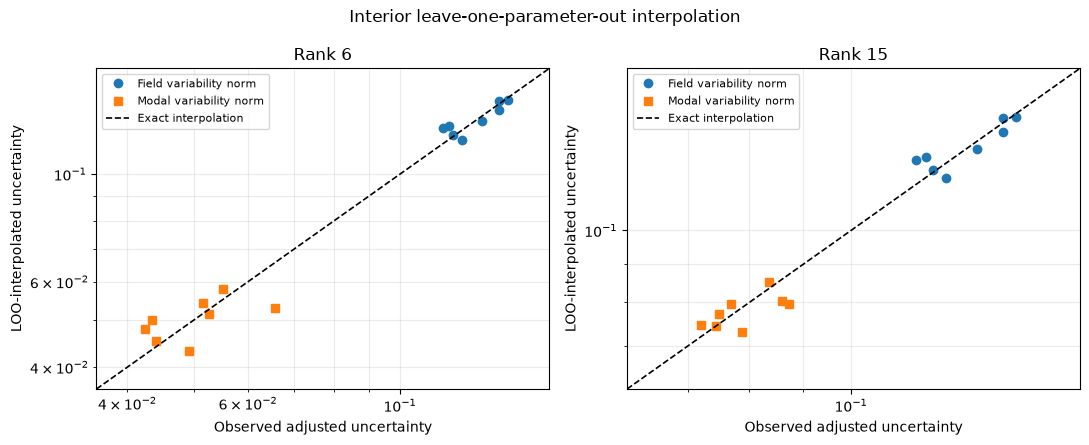

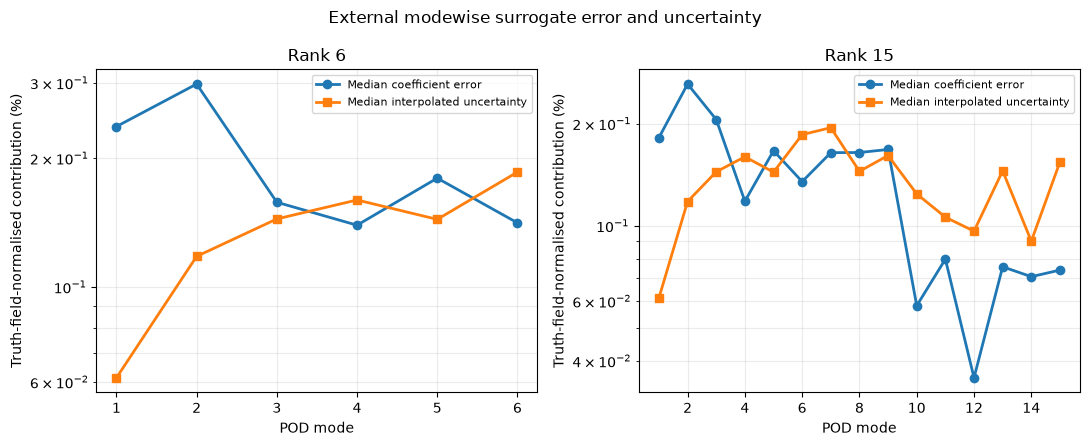

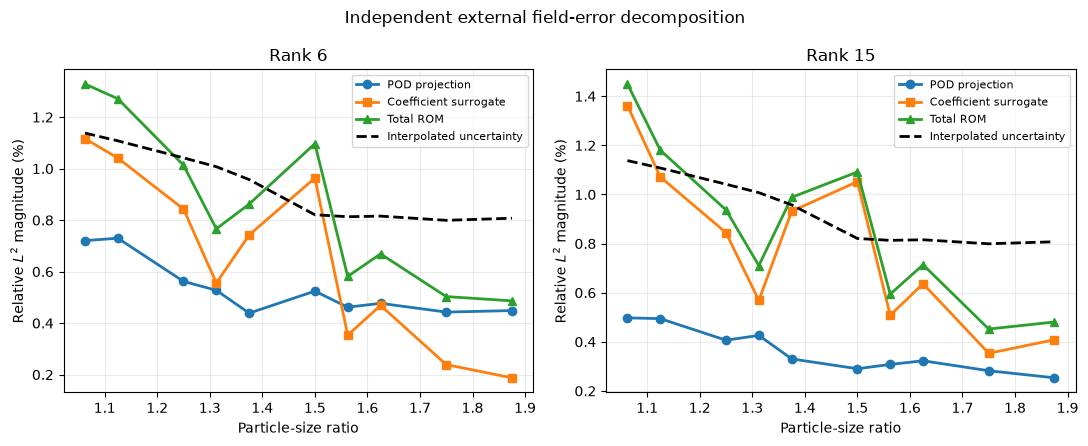

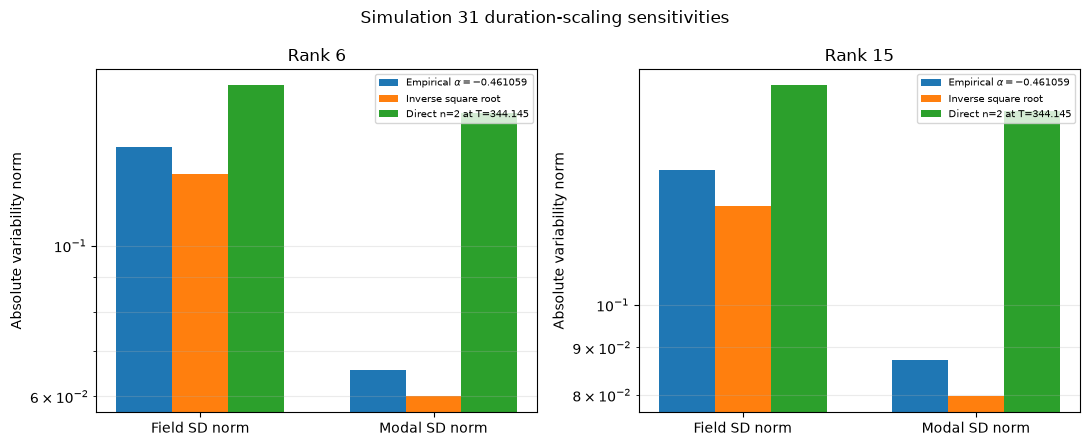

Saved Stage 4 tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/stage4_package_schema_audit.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/stage4_duration_adjusted_modewise_uncertainty.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/stage4_duration_adjusted_field_uncertainty.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/stage4_uncertainty_interpolation_loo.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/stage4_rom_error_decomposition.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/stage4_modewise_rom_uncertainty_comparison.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/statistical_uncertainty_accuracy_floor/stage

,check,passed,value,requirement,notes
0,package_hashes_match_manifest,True,"[True, True]",all True,
1,uncentred_raw_packages,True,"[{'pod_formulation': 'uncentred', 'coefficient...",uncentred and none,
2,basis_orthonormality,True,2.4424906541753444e-15,< 1e-12,
3,deterministic_inference,True,0.0,0,
4,duration_ratio,True,10.0,10,
5,primary_duration_exponent,True,-0.461059,-0.461059,
6,inverse_sqrt_sensitivity_exponent,True,-0.5,-0.5,
7,external_duration_provenance,True,[343.72],ten fields at duration 343.72,
8,numbered_window_counts,True,"[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]",ten windows per case,
9,sample_standard_deviation_ddof,True,1,ddof=1,



External primary summary:


,model,rank,mean_projection_error_percent,mean_coefficient_error_percent,mean_rom_error_percent,median_rom_error_percent,maximum_rom_error_percent,mean_field_uncertainty_percent,median_rom_to_uncertainty_ratio,maximum_rom_to_uncertainty_ratio,median_coefficient_to_uncertainty_ratio,maximum_coefficient_to_uncertainty_ratio
0,paper_rank15,15,0.361168,0.773691,0.859868,0.825467,1.449864,0.930909,0.887348,1.330027,1.283156,2.074858
1,validation_selected_rank,6,0.533321,0.651069,0.857850,0.814311,1.328504,0.930909,0.860363,1.336333,1.659800,3.173466



Simulation 41 matched comparison:


,model,rank,size_ratio,evaluation_role,uncertainty_source,projection_error_percent,coefficient_error_percent,rom_error_percent,field_uncertainty_percent,rom_to_field_uncertainty_ratio,coefficient_to_modal_uncertainty_ratio
0,validation_selected_rank,6,1.40404,internal_validation,observed_numbered_windows,0.613917,0.841222,1.041417,0.929346,1.120591,2.310322
1,paper_rank15,15,1.40404,internal_validation,observed_numbered_windows,0.311189,1.011149,1.057951,0.929346,1.138382,1.863165



All Stage 4 artifacts exist: True
Comprehensive final manifest created: False

Stage 4 artifacts saved and validated successfully: True


In [18]:
import matplotlib.pyplot as plt


TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


STAGE4_TABLE_PATHS = {
    "package_schema_audit": (
        TABLE_DIRECTORY
        / "stage4_package_schema_audit.csv"
    ),
    "modewise_uncertainty": (
        TABLE_DIRECTORY
        / "stage4_duration_adjusted_modewise_uncertainty.csv"
    ),
    "field_uncertainty": (
        TABLE_DIRECTORY
        / "stage4_duration_adjusted_field_uncertainty.csv"
    ),
    "interpolation_loo": (
        TABLE_DIRECTORY
        / "stage4_uncertainty_interpolation_loo.csv"
    ),
    "rom_decomposition": (
        TABLE_DIRECTORY
        / "stage4_rom_error_decomposition.csv"
    ),
    "modewise_comparison": (
        TABLE_DIRECTORY
        / "stage4_modewise_rom_uncertainty_comparison.csv"
    ),
    "n2_sensitivity": (
        TABLE_DIRECTORY
        / "stage4_variable_duration_n2_sensitivity.csv"
    ),
    "modewise_exponents": (
        TABLE_DIRECTORY
        / "stage4_modewise_duration_exponent_diagnostics.csv"
    ),
    "validation_checks": (
        TABLE_DIRECTORY
        / "stage4_validation_checks.csv"
    ),
}


STAGE4_FIGURE_PATHS = {
    "interpolation_validation_pdf": (
        FIGURE_DIRECTORY
        / "stage4_interpolation_validation.pdf"
    ),
    "interpolation_validation_png": (
        FIGURE_DIRECTORY
        / "stage4_interpolation_validation.png"
    ),
    "modewise_comparison_pdf": (
        FIGURE_DIRECTORY
        / "stage4_modewise_uncertainty_vs_coefficient_error.pdf"
    ),
    "modewise_comparison_png": (
        FIGURE_DIRECTORY
        / "stage4_modewise_uncertainty_vs_coefficient_error.png"
    ),
    "field_decomposition_pdf": (
        FIGURE_DIRECTORY
        / "stage4_field_error_decomposition.pdf"
    ),
    "field_decomposition_png": (
        FIGURE_DIRECTORY
        / "stage4_field_error_decomposition.png"
    ),
    "duration_sensitivity_pdf": (
        FIGURE_DIRECTORY
        / "stage4_duration_scaling_sensitivities.pdf"
    ),
    "duration_sensitivity_png": (
        FIGURE_DIRECTORY
        / "stage4_duration_scaling_sensitivities.png"
    ),
}


PROHIBITED_STAGE4_MANIFEST_PATH = (
    TABLE_DIRECTORY
    / "stage4_manifest.json"
)


assert not PROHIBITED_STAGE4_MANIFEST_PATH.exists(), (
    "A Stage 4 manifest exists even though the comprehensive "
    "Notebook 15 manifest is not authorised yet."
)


required_provenance_columns = [
    "model",
    "rank",
    "evaluation_role",
    "uncertainty_source",
    "duration_scaling",
]


for table_name, table_value in {
    "modewise_temporal_uncertainty":
        modewise_temporal_uncertainty,
    "field_temporal_uncertainty":
        field_temporal_uncertainty,
    "rom_error_decomposition":
        rom_error_decomposition,
    "modewise_rom_uncertainty_comparison":
        modewise_rom_uncertainty_comparison,
    "variable_duration_n2_sensitivity":
        variable_duration_n2_sensitivity,
    "modewise_duration_exponent_diagnostics":
        modewise_duration_exponent_diagnostics,
}.items():
    assert set(
        required_provenance_columns
    ).issubset(
        table_value.columns
    ), (
        f"{table_name} is missing required provenance columns."
    )

    assert not table_value[
        required_provenance_columns
    ].isna().any().any()


assert set(
    modewise_temporal_uncertainty[
        "duration_scaling"
    ]
) == {
    "empirical_primary",
    "inverse_sqrt_sensitivity",
}

assert set(
    field_temporal_uncertainty[
        "duration_scaling"
    ]
) == {
    "empirical_primary",
    "inverse_sqrt_sensitivity",
}

assert set(
    rom_error_decomposition[
        "evaluation_role"
    ]
) == {
    "fitting",
    "internal_validation",
    "external",
}

assert set(
    rom_error_decomposition[
        "uncertainty_source"
    ]
) == {
    "observed_numbered_windows",
    "interpolated_external",
}

assert set(
    variable_duration_n2_sensitivity[
        "uncertainty_source"
    ]
) == {
    "variable_duration_diagnostic"
}


primary_rows_only = (
    rom_error_decomposition.loc[
        rom_error_decomposition[
            "duration_scaling"
        ] == "empirical_primary"
    ]
)

assert len(
    primary_rows_only
) == 40


primary_simulation_41_rows = (
    primary_rows_only.loc[
        (
            primary_rows_only[
                "case_set"
            ] == "numbered"
        )
        & (
            primary_rows_only[
                "source_simulation"
            ] == 41
        )
    ]
)

assert len(
    primary_simulation_41_rows
) == 2

assert (
    primary_simulation_41_rows[
        "evaluation_role"
    ] == "internal_validation"
).all()

assert (
    primary_simulation_41_rows[
        "uncertainty_source"
    ] == "observed_numbered_windows"
).all()


primary_numbered_fitting_rows = (
    primary_rows_only.loc[
        (
            primary_rows_only[
                "case_set"
            ] == "numbered"
        )
        & (
            primary_rows_only[
                "evaluation_role"
            ] == "fitting"
        )
    ]
)

assert len(
    primary_numbered_fitting_rows
) == 18

assert (
    primary_numbered_fitting_rows[
        "source_simulation"
    ].nunique()
) == 9


primary_external_rows = (
    primary_rows_only.loc[
        primary_rows_only[
            "case_set"
        ] == "external"
    ]
)

assert len(
    primary_external_rows
) == 20

assert (
    primary_external_rows[
        "evaluation_role"
    ] == "external"
).all()

assert (
    primary_external_rows[
        "uncertainty_source"
    ] == "interpolated_external"
).all()

assert not (
    primary_external_rows[
        "external_test_used_for_selection"
    ]
).any()


loo_summary_validation_rows = (
    uncertainty_interpolation_loo.loc[
        uncertainty_interpolation_loo[
            "quantity"
        ].isin(
            [
                "field",
                "modal_vector_summary",
            ]
        )
    ]
)

loo_eligible_counts = (
    loo_summary_validation_rows.groupby(
        [
            "model",
            "rank",
            "duration_scaling",
            "quantity",
        ]
    )[
        "loo_eligible"
    ]
    .sum()
)

loo_ineligible_counts = (
    loo_summary_validation_rows.groupby(
        [
            "model",
            "rank",
            "duration_scaling",
            "quantity",
        ]
    )[
        "loo_eligible"
    ]
    .apply(
        lambda values: (
            ~values
        ).sum()
    )
)

assert (
    loo_eligible_counts
    == 8
).all()

assert (
    loo_ineligible_counts
    == 2
).all()


eligible_loo_numeric = (
    uncertainty_interpolation_loo.loc[
        uncertainty_interpolation_loo[
            "loo_eligible"
        ],
        [
            "observed_absolute",
            "predicted_absolute",
            "absolute_error",
            "relative_error_percent",
        ],
    ]
)

assert np.isfinite(
    eligible_loo_numeric.to_numpy(
        dtype=float
    )
).all()


ineligible_loo_rows = (
    uncertainty_interpolation_loo.loc[
        ~uncertainty_interpolation_loo[
            "loo_eligible"
        ]
    ]
)

assert (
    ineligible_loo_rows[
        "exclusion_reason"
    ] == "endpoint_requires_extrapolation"
).all()

assert ineligible_loo_rows[
    [
        "predicted_absolute",
        "absolute_error",
        "relative_error_percent",
    ]
].isna().all().all()


tables_expected_finite = {
    "package_schema_audit":
        package_schema_audit,
    "modewise_temporal_uncertainty":
        modewise_temporal_uncertainty,
    "field_temporal_uncertainty":
        field_temporal_uncertainty,
    "rom_error_decomposition":
        rom_error_decomposition,
    "modewise_rom_uncertainty_comparison":
        modewise_rom_uncertainty_comparison,
    "variable_duration_n2_sensitivity":
        variable_duration_n2_sensitivity,
    "modewise_duration_exponent_diagnostics":
        modewise_duration_exponent_diagnostics,
}


for table_name, table_value in (
    tables_expected_finite.items()
):
    numeric_values = (
        table_value.select_dtypes(
            include=[
                np.number
            ]
        )
        .to_numpy()
    )

    assert np.isfinite(
        numeric_values
    ).all(), (
        f"{table_name} contains a non-finite numeric value."
    )


validation_check_records = []


def add_validation_check(
    check,
    passed,
    value,
    requirement,
    notes="",
):
    validation_check_records.append(
        {
            "check":
                check,
            "passed":
                bool(
                    passed
                ),
            "value":
                str(
                    value
                ),
            "requirement":
                str(
                    requirement
                ),
            "notes":
                notes,
        }
    )


add_validation_check(
    "package_hashes_match_manifest",
    bool(
        package_schema_audit[
            "hash_match"
        ].all()
    ),
    package_schema_audit[
        "hash_match"
    ].tolist(),
    "all True",
)

add_validation_check(
    "uncentred_raw_packages",
    bool(
        (
            package_schema_audit[
                "pod_formulation"
            ] == "uncentred"
        ).all()
        and (
            package_schema_audit[
                "coefficient_scaling"
            ] == "none"
        ).all()
    ),
    (
        package_schema_audit[
            [
                "pod_formulation",
                "coefficient_scaling",
            ]
        ].to_dict(
            orient="records"
        )
    ),
    "uncentred and none",
)

add_validation_check(
    "basis_orthonormality",
    bool(
        package_schema_audit[
            "orthonormality_residual"
        ].max()
        < 1.0e-12
    ),
    package_schema_audit[
        "orthonormality_residual"
    ].max(),
    "< 1e-12",
)

add_validation_check(
    "deterministic_inference",
    bool(
        package_schema_audit[
            "deterministic_difference"
        ].max()
        == 0.0
    ),
    package_schema_audit[
        "deterministic_difference"
    ].max(),
    "0",
)

add_validation_check(
    "duration_ratio",
    bool(
        np.isclose(
            DURATION_RATIO,
            10.0,
            rtol=0.0,
            atol=1.0e-12,
        )
    ),
    DURATION_RATIO,
    "10",
)

add_validation_check(
    "primary_duration_exponent",
    bool(
        ALPHA_PRIMARY
        == -0.461059
    ),
    ALPHA_PRIMARY,
    "-0.461059",
)

add_validation_check(
    "inverse_sqrt_sensitivity_exponent",
    bool(
        ALPHA_INVERSE_SQRT
        == -0.5
    ),
    ALPHA_INVERSE_SQRT,
    "-0.5",
)

add_validation_check(
    "external_duration_provenance",
    bool(
        external_duration_audit[
            audit_pass_columns
        ].to_numpy().all()
    ),
    (
        external_duration_audit[
            "inferred_duration"
        ].unique().tolist()
    ),
    "ten fields at duration 343.72",
)

add_validation_check(
    "numbered_window_counts",
    bool(
        np.array_equal(
            numbered_group_counts,
            np.full(
                10,
                10,
                dtype=int,
            ),
        )
    ),
    numbered_group_counts.tolist(),
    "ten windows per case",
)

add_validation_check(
    "sample_standard_deviation_ddof",
    bool(
        (
            modewise_temporal_uncertainty[
                "sample_ddof"
            ] == 1
        ).all()
        and (
            field_temporal_uncertainty[
                "sample_ddof"
            ] == 1
        ).all()
    ),
    1,
    "ddof=1",
)

add_validation_check(
    "loo_interior_case_count",
    bool(
        (
            loo_eligible_counts
            == 8
        ).all()
    ),
    sorted(
        loo_eligible_counts.unique().tolist()
    ),
    "8 for every model/scaling/quantity",
)

add_validation_check(
    "loo_endpoint_exclusions",
    bool(
        (
            loo_ineligible_counts
            == 2
        ).all()
    ),
    sorted(
        loo_ineligible_counts.unique().tolist()
    ),
    "2 without extrapolation",
)

add_validation_check(
    "external_interpolation_domain",
    bool(
        np.min(
            test_parameters
        )
        >= np.min(
            NUMBERED_PARAMETERS
        )
        and np.max(
            test_parameters
        )
        <= np.max(
            NUMBERED_PARAMETERS
        )
    ),
    (
        float(
            np.min(
                test_parameters
            )
        ),
        float(
            np.max(
                test_parameters
            )
        ),
    ),
    (
        f"within [{NUMBERED_PARAMETERS[0]}, "
        f"{NUMBERED_PARAMETERS[-1]}]"
    ),
)

add_validation_check(
    "simulation_41_role",
    bool(
        len(
            primary_simulation_41_rows
        ) == 2
        and (
            primary_simulation_41_rows[
                "evaluation_role"
            ] == "internal_validation"
        ).all()
    ),
    "simulation 41",
    "sole directly matched internal validation",
)

add_validation_check(
    "nine_numbered_fitting_cases",
    bool(
        primary_numbered_fitting_rows[
            "source_simulation"
        ].nunique()
        == 9
    ),
    sorted(
        primary_numbered_fitting_rows[
            "source_simulation"
        ].unique().tolist()
    ),
    "nine fitting diagnostics",
)

add_validation_check(
    "external_non_leakage",
    bool(
        external_evaluation_started_after_rule_freeze
        and not rom_error_decomposition[
            "external_test_used_for_selection"
        ].any()
    ),
    False,
    "external test absent from fitting, LOO and selection",
)

add_validation_check(
    "pythagorean_decomposition",
    bool(
        maximum_pythagorean_residual
        < 1.0e-12
    ),
    maximum_pythagorean_residual,
    "< 1e-12",
)

add_validation_check(
    "coefficient_field_equivalence",
    bool(
        maximum_coefficient_field_equivalence_residual
        < 1.0e-12
    ),
    maximum_coefficient_field_equivalence_residual,
    "< 1e-12",
)

add_validation_check(
    "required_provenance_labels",
    True,
    required_provenance_columns,
    "present and non-null",
)

add_validation_check(
    "primary_conclusion_filter",
    bool(
        (
            primary_rows_only[
                "duration_scaling"
            ] == "empirical_primary"
        ).all()
    ),
    "empirical_primary",
    "primary conclusions use only empirical scaling",
)

add_validation_check(
    "direct_n2_duration",
    bool(
        (
            variable_duration_n2_sensitivity[
                "field_count"
            ] == 2
        ).all()
        and (
            variable_duration_n2_sensitivity[
                "variance_degrees_of_freedom"
            ] == 1
        ).all()
    ),
    (
        float(
            variable_duration_n2_sensitivity[
                "duration"
            ].iloc[
                0
            ]
        ),
        float(
            variable_duration_n2_sensitivity[
                "relative_duration_difference_percent"
            ].iloc[
                0
            ]
        ),
    ),
    "near-target two-field sensitivity with one df",
)

add_validation_check(
    "mode_exponents_diagnostic_only",
    bool(
        not modewise_duration_exponent_diagnostics[
            "used_for_primary_rule"
        ].any()
    ),
    False,
    "never used for the primary rule",
)

add_validation_check(
    "comprehensive_manifest_not_created",
    bool(
        not PROHIBITED_STAGE4_MANIFEST_PATH.exists()
    ),
    str(
        PROHIBITED_STAGE4_MANIFEST_PATH
    ),
    "must not exist at Stage 4",
)


stage4_validation_checks = pd.DataFrame(
    validation_check_records
)


assert (
    stage4_validation_checks[
        "passed"
    ]
).all()


# Figure 1: leave-one-parameter-out interpolation validation.
loo_plot_data = (
    uncertainty_interpolation_loo.loc[
        (
            uncertainty_interpolation_loo[
                "duration_scaling"
            ] == "empirical_primary"
        )
        & (
            uncertainty_interpolation_loo[
                "loo_eligible"
            ]
        )
        & (
            uncertainty_interpolation_loo[
                "quantity"
            ].isin(
                [
                    "field",
                    "modal_vector_summary",
                ]
            )
        )
    ]
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        11,
        4.5,
    ),
)


for axis, (
    model_name,
    registry_entry,
) in zip(
    axes,
    frozen_model_registry.items(),
):
    model_plot_data = (
        loo_plot_data.loc[
            loo_plot_data[
                "model"
            ] == model_name
        ]
    )

    for quantity, marker, label in [
        (
            "field",
            "o",
            "Field variability norm",
        ),
        (
            "modal_vector_summary",
            "s",
            "Modal variability norm",
        ),
    ]:
        quantity_data = (
            model_plot_data.loc[
                model_plot_data[
                    "quantity"
                ] == quantity
            ]
        )

        axis.loglog(
            quantity_data[
                "observed_absolute"
            ],
            quantity_data[
                "predicted_absolute"
            ],
            linestyle="none",
            marker=marker,
            markersize=6,
            label=label,
        )

    combined_values = np.concatenate(
        [
            model_plot_data[
                "observed_absolute"
            ].to_numpy(
                dtype=float
            ),
            model_plot_data[
                "predicted_absolute"
            ].to_numpy(
                dtype=float
            ),
        ]
    )

    lower_limit = float(
        combined_values.min()
        * 0.85
    )

    upper_limit = float(
        combined_values.max()
        * 1.15
    )

    axis.plot(
        [
            lower_limit,
            upper_limit,
        ],
        [
            lower_limit,
            upper_limit,
        ],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Exact interpolation",
    )

    axis.set_xlim(
        lower_limit,
        upper_limit,
    )

    axis.set_ylim(
        lower_limit,
        upper_limit,
    )

    axis.set_xlabel(
        "Observed adjusted uncertainty"
    )

    axis.set_ylabel(
        "LOO-interpolated uncertainty"
    )

    axis.set_title(
        f"Rank {registry_entry['rank']}"
    )

    axis.grid(
        True,
        alpha=0.25,
        which="both",
    )

    axis.legend(
        fontsize=8,
    )


figure.suptitle(
    "Interior leave-one-parameter-out interpolation"
)

figure.tight_layout()

figure.savefig(
    STAGE4_FIGURE_PATHS[
        "interpolation_validation_pdf"
    ],
    bbox_inches="tight",
)

figure.savefig(
    STAGE4_FIGURE_PATHS[
        "interpolation_validation_png"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 2: external modewise coefficient error versus uncertainty.
external_mode_plot_summary = (
    modewise_rom_uncertainty_comparison.loc[
        (
            modewise_rom_uncertainty_comparison[
                "case_set"
            ] == "external"
        )
        & (
            modewise_rom_uncertainty_comparison[
                "duration_scaling"
            ] == "empirical_primary"
        )
    ]
    .groupby(
        [
            "model",
            "rank",
            "mode",
        ],
        as_index=False,
    )
    .agg(
        median_coefficient_error_percent=(
            "coefficient_error_percent",
            "median",
        ),
        median_modal_uncertainty_percent=(
            "modal_uncertainty_percent",
            "median",
        ),
    )
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        11,
        4.5,
    ),
)


for axis, (
    model_name,
    registry_entry,
) in zip(
    axes,
    frozen_model_registry.items(),
):
    model_plot_data = (
        external_mode_plot_summary.loc[
            external_mode_plot_summary[
                "model"
            ] == model_name
        ]
        .sort_values(
            "mode"
        )
    )

    axis.semilogy(
        model_plot_data[
            "mode"
        ],
        model_plot_data[
            "median_coefficient_error_percent"
        ],
        marker="o",
        linewidth=2,
        label="Median coefficient error",
    )

    axis.semilogy(
        model_plot_data[
            "mode"
        ],
        model_plot_data[
            "median_modal_uncertainty_percent"
        ],
        marker="s",
        linewidth=2,
        label="Median interpolated uncertainty",
    )

    axis.set_xlabel(
        "POD mode"
    )

    axis.set_ylabel(
        "Truth-field-normalised contribution (%)"
    )

    axis.set_title(
        f"Rank {registry_entry['rank']}"
    )

    axis.grid(
        True,
        alpha=0.25,
        which="both",
    )

    axis.legend(
        fontsize=8,
    )


figure.suptitle(
    "External modewise surrogate error and uncertainty"
)

figure.tight_layout()

figure.savefig(
    STAGE4_FIGURE_PATHS[
        "modewise_comparison_pdf"
    ],
    bbox_inches="tight",
)

figure.savefig(
    STAGE4_FIGURE_PATHS[
        "modewise_comparison_png"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 3: external field-error decomposition.
figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        11,
        4.5,
    ),
)


for axis, (
    model_name,
    registry_entry,
) in zip(
    axes,
    frozen_model_registry.items(),
):
    model_plot_data = (
        external_primary_rows.loc[
            external_primary_rows[
                "model"
            ] == model_name
        ]
        .sort_values(
            "size_ratio"
        )
    )

    axis.plot(
        model_plot_data[
            "size_ratio"
        ],
        model_plot_data[
            "projection_error_percent"
        ],
        marker="o",
        linewidth=2,
        label="POD projection",
    )

    axis.plot(
        model_plot_data[
            "size_ratio"
        ],
        model_plot_data[
            "coefficient_error_percent"
        ],
        marker="s",
        linewidth=2,
        label="Coefficient surrogate",
    )

    axis.plot(
        model_plot_data[
            "size_ratio"
        ],
        model_plot_data[
            "rom_error_percent"
        ],
        marker="^",
        linewidth=2,
        label="Total ROM",
    )

    axis.plot(
        model_plot_data[
            "size_ratio"
        ],
        model_plot_data[
            "field_uncertainty_percent"
        ],
        color="black",
        linestyle="--",
        linewidth=2,
        label="Interpolated uncertainty",
    )

    axis.set_xlabel(
        "Particle-size ratio"
    )

    axis.set_ylabel(
        r"Relative $L^2$ magnitude (%)"
    )

    axis.set_title(
        f"Rank {registry_entry['rank']}"
    )

    axis.grid(
        True,
        alpha=0.25,
    )

    axis.legend(
        fontsize=8,
    )


figure.suptitle(
    "Independent external field-error decomposition"
)

figure.tight_layout()

figure.savefig(
    STAGE4_FIGURE_PATHS[
        "field_decomposition_pdf"
    ],
    bbox_inches="tight",
)

figure.savefig(
    STAGE4_FIGURE_PATHS[
        "field_decomposition_png"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 4: empirical, inverse-square-root and direct n=2 sensitivity.
simulation_31_parameter_index = int(
    np.flatnonzero(
        NUMBERED_SIMULATIONS
        == 31
    )[
        0
    ]
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        11,
        4.5,
    ),
)


for axis, (
    model_name,
    registry_entry,
) in zip(
    axes,
    frozen_model_registry.items(),
):
    primary_field_value = float(
        numbered_uncertainty_lookup[
            model_name
        ][
            "empirical_primary"
        ][
            "field"
        ][
            simulation_31_parameter_index
        ]
    )

    inverse_field_value = float(
        numbered_uncertainty_lookup[
            model_name
        ][
            "inverse_sqrt_sensitivity"
        ][
            "field"
        ][
            simulation_31_parameter_index
        ]
    )

    primary_modal_value = float(
        np.linalg.norm(
            numbered_uncertainty_lookup[
                model_name
            ][
                "empirical_primary"
            ][
                "modal"
            ][
                simulation_31_parameter_index,
                :
            ]
        )
    )

    inverse_modal_value = float(
        np.linalg.norm(
            numbered_uncertainty_lookup[
                model_name
            ][
                "inverse_sqrt_sensitivity"
            ][
                "modal"
            ][
                simulation_31_parameter_index,
                :
            ]
        )
    )

    direct_model_rows = (
        variable_duration_n2_sensitivity.loc[
            variable_duration_n2_sensitivity[
                "model"
            ] == model_name
        ]
    )

    direct_field_value = float(
        direct_model_rows.loc[
            direct_model_rows[
                "quantity"
            ] == "field",
            "direct_absolute_sd",
        ].iloc[
            0
        ]
    )

    direct_modal_value = float(
        np.linalg.norm(
            direct_model_rows.loc[
                direct_model_rows[
                    "quantity"
                ] == "mode",
                "direct_absolute_sd",
            ].to_numpy(
                dtype=float
            )
        )
    )

    category_positions = np.arange(
        2
    )

    bar_width = 0.24

    axis.bar(
        category_positions
        - bar_width,
        [
            primary_field_value,
            primary_modal_value,
        ],
        width=bar_width,
        label=(
            r"Empirical $\alpha=-0.461059$"
        ),
    )

    axis.bar(
        category_positions,
        [
            inverse_field_value,
            inverse_modal_value,
        ],
        width=bar_width,
        label=r"Inverse square root",
    )

    axis.bar(
        category_positions
        + bar_width,
        [
            direct_field_value,
            direct_modal_value,
        ],
        width=bar_width,
        label=(
            "Direct n=2 at T=344.145"
        ),
    )

    axis.set_xticks(
        category_positions,
        [
            "Field SD norm",
            "Modal SD norm",
        ],
    )

    axis.set_yscale(
        "log"
    )

    axis.set_ylabel(
        "Absolute variability norm"
    )

    axis.set_title(
        f"Rank {registry_entry['rank']}"
    )

    axis.grid(
        True,
        alpha=0.25,
        axis="y",
        which="both",
    )

    axis.legend(
        fontsize=7,
    )


figure.suptitle(
    "Simulation 31 duration-scaling sensitivities"
)

figure.tight_layout()

figure.savefig(
    STAGE4_FIGURE_PATHS[
        "duration_sensitivity_pdf"
    ],
    bbox_inches="tight",
)

figure.savefig(
    STAGE4_FIGURE_PATHS[
        "duration_sensitivity_png"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Save the eight scientific result tables first.
tables_to_save = {
    STAGE4_TABLE_PATHS[
        "package_schema_audit"
    ]:
        package_schema_audit,
    STAGE4_TABLE_PATHS[
        "modewise_uncertainty"
    ]:
        modewise_temporal_uncertainty,
    STAGE4_TABLE_PATHS[
        "field_uncertainty"
    ]:
        field_temporal_uncertainty,
    STAGE4_TABLE_PATHS[
        "interpolation_loo"
    ]:
        uncertainty_interpolation_loo,
    STAGE4_TABLE_PATHS[
        "rom_decomposition"
    ]:
        rom_error_decomposition,
    STAGE4_TABLE_PATHS[
        "modewise_comparison"
    ]:
        modewise_rom_uncertainty_comparison,
    STAGE4_TABLE_PATHS[
        "n2_sensitivity"
    ]:
        variable_duration_n2_sensitivity,
    STAGE4_TABLE_PATHS[
        "modewise_exponents"
    ]:
        modewise_duration_exponent_diagnostics,
}


for output_path, table_value in (
    tables_to_save.items()
):
    table_value.to_csv(
        output_path,
        index=False,
    )


# Save the validation table, check all artifacts, then append that check.
stage4_validation_checks.to_csv(
    STAGE4_TABLE_PATHS[
        "validation_checks"
    ],
    index=False,
)


all_stage4_artifact_paths = [
    *STAGE4_TABLE_PATHS.values(),
    *STAGE4_FIGURE_PATHS.values(),
]


artifact_existence_pass = all(
    path.is_file()
    for path in (
        all_stage4_artifact_paths
    )
)


add_validation_check(
    "artifact_existence",
    artifact_existence_pass,
    len(
        [
            path
            for path in (
                all_stage4_artifact_paths
            )
            if path.is_file()
        ]
    ),
    (
        f"{len(all_stage4_artifact_paths)} "
        "tables and figure files"
    ),
)


stage4_validation_checks = pd.DataFrame(
    validation_check_records
)

stage4_validation_checks.to_csv(
    STAGE4_TABLE_PATHS[
        "validation_checks"
    ],
    index=False,
)


assert (
    stage4_validation_checks[
        "passed"
    ]
).all()

assert all(
    path.is_file()
    for path in (
        all_stage4_artifact_paths
    )
)

assert not PROHIBITED_STAGE4_MANIFEST_PATH.exists()


print(
    "Saved Stage 4 tables:"
)

for path in (
    STAGE4_TABLE_PATHS.values()
):
    print(
        path
    )


print(
    "\nSaved Stage 4 figures:"
)

for path in (
    STAGE4_FIGURE_PATHS.values()
):
    print(
        path
    )


print(
    "\nValidation checks:"
)

display(
    stage4_validation_checks
)


print(
    "\nExternal primary summary:"
)

display(
    external_primary_summary
)


print(
    "\nSimulation 41 matched comparison:"
)

display(
    simulation_41_field_comparison
)


print(
    "\nAll Stage 4 artifacts exist:",
    artifact_existence_pass,
)

print(
    "Comprehensive final manifest created:",
    False,
)

print(
    "\nStage 4 artifacts saved and validated successfully:",
    True,
)


### Stage 4 findings

The duration-adjusted uncertainty comparison passed all provenance, non-leakage and numerical checks. The empirical duration factor was

$$
10^{-0.461059}=0.345892,
$$

while the inverse-square-root sensitivity factor was

$$
10^{-1/2}=0.316228.
$$

#### Interpolation validation

Piecewise-linear interpolation reproduced the duration-adjusted field-variability norm accurately across the eight withheld interior numbered parameters. The mean, median and maximum relative leave-one-parameter-out errors were approximately $3.46\%$, $2.55\%$ and $7.93\%$, respectively.

Modal-vector uncertainty was less smoothly dependent on size ratio. Its mean leave-one-parameter-out error was approximately $26.7\%$ at rank 6 and $26.1\%$ at rank 15, with maxima of approximately $34.9\%$ and $31.8\%$. Field-level comparisons are therefore better supported than conclusions about individual POD modes.

#### Independent external comparison

For the frozen rank-6 model, the ten external cases had mean errors

$$
e_{\mathrm{POD}}=0.533\%,
\qquad
e_{\mathrm{coef}}=0.651\%,
\qquad
e_{\mathrm{ROM}}=0.858\%.
$$

For the frozen rank-15 model, the corresponding mean errors were

$$
e_{\mathrm{POD}}=0.361\%,
\qquad
e_{\mathrm{coef}}=0.774\%,
\qquad
e_{\mathrm{ROM}}=0.860\%.
$$

The mean empirically duration-adjusted external field-uncertainty scale was $0.931\%$. Thus, the mean total ROM error was slightly smaller than the mean uncertainty estimate for both ranks. The median ratios of ROM error to field uncertainty were $0.860$ for rank 6 and $0.887$ for rank 15. However, the maximum ratios were $1.336$ and $1.330$, so the ROM error exceeded the estimated uncertainty scale for some external parameters.

Increasing the rank from 6 to 15 reduced the mean projection error but increased the coefficient-surrogate error. These changes nearly cancelled, leaving the total external error almost unchanged. For these frozen models, improving the POD truncation alone therefore did not improve overall predictive accuracy.

Under inverse-square-root scaling, the mean uncertainty estimate decreased by approximately $8.58\%$, and the mean ROM-to-uncertainty ratios became $0.990$ for rank 6 and $0.992$ for rank 15. The conclusion that ROM error and duration-adjusted temporal variability have comparable magnitudes is therefore insensitive to the two predeclared scaling choices.

#### Directly matched internal-validation case

Simulation 41 at size ratio $1.404040$ was the only numbered-window case excluded from model fitting. Its observed empirically adjusted field uncertainty was $0.929\%$.

The rank-6 and rank-15 ROM errors were $1.041\%$ and $1.058\%$, corresponding to ROM-to-uncertainty ratios of $1.121$ and $1.138$. This single directly matched non-fitting diagnostic places both frozen-model errors slightly above, but still close to, the observed temporal-variability scale.

#### Duration and modewise sensitivities

The direct longest-duration simulation-31 estimate used two fields of mean duration $344.145$, which is $0.124\%$ longer than the target duration. Its field-variability norm was approximately $1.235$ times the primary empirical estimate. This is qualitatively consistent in scale but has only one variance degree of freedom and is not a precise validation target.

Mode-specific duration exponents varied substantially across the retained POD modes. Together with the larger modewise interpolation errors, this supports retaining the common exponent $-0.461059$ only as an explicit field-informed approximation. Modewise comparisons remain descriptive diagnostics rather than independently validated uncertainty estimates.

#### Interpretation and limitations

The exact orthogonal identity

$$
e_{\mathrm{ROM}}^2
=
e_{\mathrm{POD}}^2
+
e_{\mathrm{coef}}^2
$$

held with a maximum residual of $1.60\times10^{-17}$. Coefficient-space and retained-field-space errors agreed to within $1.39\times10^{-16}$.

The results show that the frozen continuum-ROM errors are comparable in magnitude to a predeclared, duration-adjusted temporal coarse-graining uncertainty scale. They do not establish that finite-time averaging caused any particular external error, nor that the interpolated scale is a true irreducible accuracy floor.

The numbered and variable-duration windows are contiguous or nested and are not treated as independent replicates. The direct $n=2$ estimate is unstable, the modal interpolation is less reliable than the field-level interpolation, and simulation 41 alone cannot establish generalisation throughout parameter space. The nine remaining numbered-case comparisons are fitting diagnostics only.

The external cases were used solely after the model, rank, duration exponent and interpolation rule had been fixed. They did not enter model fitting, rank selection, uncertainty fitting or interpolation validation.